# Proyecto Integrador — Metodología CRISP-DM
## Predicción del alto desempeño en la prueba Saber 11 · Antioquia 2022-2

| Ficha técnica | |
|---|---|
| **Programa** | Maestría en Ciencia de Datos — proyecto integrador |
| **Integrantes** | Carlos Diaz - Yeisson Giraldo |
| **Tipo de problema** | Clasificación binaria supervisada (+ capa prescriptiva) |
| **Fuente de datos** | ICFES — *Resultados únicos Saber 11*, Datos Abiertos Colombia (`kgxf-xxbe`) |
| **Enlace al dataset** | https://www.datos.gov.co/Educaci-n/Resultados-nicos-Saber-11/kgxf-xxbe |
| **Modelo final** | Regresión logística con umbral de decisión ajustado (0,615): F1 = 0,473 en prueba (sección 5.2) |
| **Capa prescriptiva** | Bandas de acompañamiento: prioridad de nivelación, refuerzo focalizado y alto potencial (sección 6.2) |
| **Aplicación web** | [COMPLETAR: URL pública de Streamlit.io] |



## 0. Configuración del entorno

In [1]:
# 0.1 Instalación de dependencias (solo se ejecuta en Google Colab)
# En local las librerías ya están en el entorno virtual .venv; en Colab hay que instalarlas en cada sesión.
import sys          # Permite saber qué intérprete de Python está corriendo y qué módulos están cargados
import subprocess   # Permite ejecutar "pip install" desde Python

# Colab carga el módulo google.colab al iniciar: si está presente, estamos en Colab
EN_COLAB = "google.colab" in sys.modules

# Versiones exactas usadas al entrenar (se inyectan desde requirements-notebook.txt al construir el cuaderno).
# Fijar versiones garantiza que otra persona obtenga los mismos resultados y que el modelo serializado cargue sin errores.
PAQUETES = ['scikit-learn==1.9.1', 'imbalanced-learn==0.14.2', 'xgboost==3.4.1', 'ydata-profiling==4.18.4', 'setuptools<81']
# Librerías que Colab puede tener ya cargadas en memoria (nombre del módulo -> nombre del paquete en pip)
LIBRERIAS_BASE = {"numpy": "numpy", "pandas": "pandas", "scipy": "scipy", "matplotlib": "matplotlib",
                  "sklearn": "scikit-learn"}

if EN_COLAB:
    from importlib.metadata import version   # Lee la versión instalada de un paquete sin importarlo
    # Versiones de las librerías ya cargadas, antes de instalar
    antes = {paquete: version(paquete) for modulo, paquete in LIBRERIAS_BASE.items() if modulo in sys.modules}
    # "-q" (quiet) reduce la salida de pip; *PAQUETES pasa cada elemento de la lista como argumento independiente
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *PAQUETES])
    print("Dependencias instaladas en Colab:", PAQUETES)
    # Si pip cambió una librería que ya estaba en memoria, la sesión seguiría usando la versión vieja: hay que reiniciar
    cambiadas = [paquete for paquete, v in antes.items() if version(paquete) != v]
    if cambiadas:
        print(f"⚠️ pip cambió librerías que ya estaban cargadas: {', '.join(cambiadas)}. Reinicie la sesión (Entorno de "
              "ejecución → Reiniciar sesión) y vuelva a ejecutar desde esta celda: la segunda vez pip no cambiará nada.")
else:
    print("Ejecución local: se usa el entorno virtual .venv del proyecto.")

Ejecución local: se usa el entorno virtual .venv del proyecto.


In [4]:
# 0.2 Importación de librerías, agrupadas por propósito
# --- Utilidades estándar de Python ---
import json                           # Guardar la metadata del modelo en formato legible
import time                           # Medir cuánto tarda cada paso costoso
import warnings                       # Silenciar avisos que no afectan los resultados
from pathlib import Path              # Rutas de archivos independientes del sistema operativo
from urllib.parse import urlencode    # Construir la URL de la API con caracteres especiales codificados

# --- Manipulación de datos y visualización ---
import numpy as np                    # Cálculo numérico vectorizado
import pandas as pd                   # Tablas (DataFrame) y operaciones sobre columnas
import matplotlib.pyplot as plt       # Gráficos base
import seaborn as sns                 # Gráficos estadísticos sobre matplotlib
from scipy import stats               # Pruebas estadísticas (χ², t, binomial, Spearman)
from scipy.stats import loguniform, randint, uniform   # Distribuciones para la búsqueda aleatoria de hiperparámetros

# --- Librerías de modelamiento (se importa el módulo completo para registrar sus versiones) ---
import sklearn
import imblearn
import xgboost
import joblib                         # Serialización eficiente de modelos de scikit-learn
from sklearn.base import clone        # Copia "sin entrenar" de un estimador (evita reutilizar modelos ya ajustados)
from sklearn.compose import ColumnTransformer          # Aplica transformaciones distintas por tipo de columna
from sklearn.decomposition import PCA                  # Reducción de dimensiones
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, VotingClassifier   # Ensambles
try:  # En algunas versiones la búsqueda por mitades sucesivas sigue siendo experimental y requiere habilitarse
    from sklearn.experimental import enable_halving_search_cv  # noqa: F401
except ImportError:
    pass
from sklearn.feature_selection import mutual_info_classif     # Información mutua (dependencia no lineal)
from sklearn.impute import SimpleImputer                       # Imputación de valores faltantes
from sklearn.inspection import permutation_importance         # Importancia de variables agnóstica al modelo
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay,
                             accuracy_score, average_precision_score, classification_report,
                             f1_score, precision_score, recall_score, roc_auc_score)   # Métricas de clasificación
from sklearn.model_selection import (HalvingRandomSearchCV, RandomizedSearchCV, StratifiedKFold,
                                     TunedThresholdClassifierCV, cross_val_score, cross_validate,
                                     learning_curve, train_test_split)                 # Validación y búsqueda
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline                          # Encadena pasos de preprocesamiento
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler   # Codificación y escalado
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from imblearn.over_sampling import SMOTE                       # Sobremuestreo sintético de la clase minoritaria
from imblearn.pipeline import Pipeline as ImbPipeline          # Pipeline que admite pasos de remuestreo
from imblearn.under_sampling import RandomUnderSampler         # Submuestreo aleatorio de la clase mayoritaria
from xgboost import XGBClassifier                              # Boosting por gradiente optimizado

# Silenciamos avisos de deprecación y de categorías desconocidas: no cambian los resultados y ensucian la salida
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_columns", 60)                 # Mostrar todas las columnas de las tablas anchas
pd.set_option("display.float_format", "{:.4f}".format)   # Cuatro decimales en las tablas

# Registrar versiones es parte de la reproducibilidad: un resultado sin versiones no se puede repetir con certeza
print(f"Python {sys.version.split()[0]} | pandas {pd.__version__} | numpy {np.__version__} | "
      f"scikit-learn {sklearn.__version__} | imbalanced-learn {imblearn.__version__} | xgboost {xgboost.__version__}")

Python 3.9.7 | pandas 2.3.3 | numpy 2.0.2 | scikit-learn 1.6.1 | imbalanced-learn 0.12.4 | xgboost 2.1.4


**¿Qué hacemos y por qué?** Cargamos tres herramientas que usa solo este cuaderno: la curva de calibración, la curva
Precision–Recall por umbral y las cajas del diagrama de flujo de la sección 6.

In [5]:
# 0.2.1 Librerías adicionales del entregable: diagnóstico del clasificador y diagramas
from sklearn.calibration import calibration_curve        # Curva de calibración de probabilidades
from sklearn.metrics import precision_recall_curve        # Precision y Recall para todos los umbrales posibles
from matplotlib.patches import FancyBboxPatch             # Cajas redondeadas del diagrama de flujo (6.3)
from IPython.display import display                       # Mostrar varias tablas en una misma celda
print("Librerías adicionales cargadas: calibration_curve, precision_recall_curve, FancyBboxPatch, display")

Librerías adicionales cargadas: calibration_curve, precision_recall_curve, FancyBboxPatch, display


🔎 **Interpretación:** La salida confirma que se cargaron las cuatro herramientas adicionales del entregable: `calibration_curve` y `precision_recall_curve` para el diagnóstico del clasificador (5.3), `FancyBboxPatch` para el diagrama de flujo (6.3) y `display` para mostrar varias tablas en una misma celda.
En general, separar estas importaciones de las del bloque 0.2 deja claro qué se añadió al cuaderno de estudio para construir el entregable, sin cambiar nada del flujo original.

**¿Qué hacemos y por qué?** Fijamos en un solo lugar los parámetros del proyecto: la semilla, el umbral de negocio (300
puntos), el tamaño de la muestra de modelado y la partición 70/30. También creamos las carpetas de salida.

In [6]:
# 0.3 Parámetros globales, rutas y utilidades
# Centralizar los parámetros aquí permite experimentar (p. ej. cambiar el umbral) sin buscar números "mágicos" en el código.
RANDOM_STATE = 42                                  # Semilla única: muestreos, particiones y modelos reproducibles
UMBRAL_ALTO_DESEMPENO = 300                        # Regla de negocio: punt_global >= 300 => clase positiva (1)
N_MUESTRA_MODELADO = 30_000                        # Muestra estratificada para modelar (el SVM escala ~n² en tiempo)
TEST_SIZE = 0.30                                   # 70 % entrenamiento / 30 % prueba, como exige la actividad
N_ITER_BUSQUEDA = 20                               # Combinaciones que prueba cada búsqueda aleatoria
FECHA_REFERENCIA = pd.Timestamp("2022-08-01")      # Referencia aproximada de la aplicación 2022-2 para calcular la edad
# StratifiedKFold conserva en cada fold la proporción de clases; shuffle + semilla => los mismos 5 folds para todos los modelos
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
np.random.seed(RANDOM_STATE)                       # Semilla también para funciones de numpy sin random_state propio

# Rutas relativas: funcionan igual en local (se ejecuta desde notebooks/) y en Colab (se ejecuta desde /content)
BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DIR_RAW = BASE_DIR / "data" / "raw"             # Datos tal como llegan de la fuente
DIR_PROC = BASE_DIR / "data" / "processed"      # Datos limpios
DIR_NUEVOS = BASE_DIR / "data" / "nuevos"       # Datos para probar el despliegue
DIR_MODELOS = BASE_DIR / "models"               # Pipeline serializado y metadata
DIR_REPORTES = BASE_DIR / "reports"             # Reporte HTML de perfilamiento
DIR_FIGURAS = DIR_REPORTES / "figures"          # Gráficos para el informe y la app
DIR_TABLAS = DIR_REPORTES / "tablas"            # Tablas que alimentan el informe U4
for carpeta in [DIR_RAW, DIR_PROC, DIR_NUEVOS, DIR_MODELOS, DIR_FIGURAS, DIR_TABLAS]:
    carpeta.mkdir(parents=True, exist_ok=True)  # Crea la carpeta si no existe (y sus padres)

sns.set_theme(style="whitegrid", palette="deep")   # Estilo visual uniforme para todos los gráficos
plt.rcParams["figure.dpi"] = 110                   # Resolución de las figuras en pantalla


def guardar_figura(nombre: str) -> None:
    """Guarda la figura activa en reports/figures para reutilizarla en el informe y la app."""
    plt.savefig(DIR_FIGURAS / f"{nombre}.png", bbox_inches="tight", dpi=150)


def guardar_tabla(df: pd.DataFrame, nombre: str) -> pd.DataFrame:
    """Exporta una tabla a reports/tablas (insumo del informe U4) y la devuelve para mostrarla."""
    df.to_csv(DIR_TABLAS / f"{nombre}.csv", index=False, encoding="utf-8")
    return df


print("Directorio base del proyecto:", BASE_DIR)

Directorio base del proyecto: y:\MAESTRIA\APRENDIZAJE DE MAQUINAS\Proyecto Final\Entrega_Proyecto_Integrador_Saber11\Entrega_Proyecto_Integrador_Saber11\repositorio


🔎 **Interpretación:** La salida muestra los parámetros globales del proyecto: semilla 42, umbral de negocio de 300 puntos, muestra de modelado de 30.000 registros, partición 70/30 y un único objeto `CV` con 5 folds estratificados.
En general, que todos los modelos compartan exactamente los mismos folds es lo que permite comparar sus F1 fold a fold con pruebas **pareadas** en la fase 5. Las carpetas de salida se crean con rutas relativas, así que el cuaderno funciona igual en local y en Colab.

## 1. Entendimiento del negocio

### 1.1 Contexto: la prueba Saber 11 en Antioquia
El **Instituto Colombiano para la Evaluación de la Educación (ICFES)** aplica cada año la prueba **Saber 11**, el examen de
Estado de la educación media. Evalúa cinco áreas (Lectura crítica, Matemáticas, Sociales y ciudadanas, Ciencias naturales e
Inglés) y entrega un **puntaje global de 0 a 500**. Además, recoge información socioeconómica del hogar y características
del colegio de cada estudiante.

- **Cobertura del caso:** colegios de Antioquia, periodo 2022-2 (calendario A).
- **Tamaño:** 144.766 registros publicados; cerca de 72 mil estudiantes únicos tras depurar duplicados (sección 3.3).
- **Territorio:** 125 municipios, del Valle de Aburrá a las subregiones rurales del departamento.
- **Usos del puntaje:** admisión a la educación superior, becas y créditos educativos y clasificación de colegios.

#### 1.1.1 Problemática
Los resultados de Saber 11 muestran **brechas persistentes** entre estudiantes de distintos contextos: estrato, educación
de los padres, zona urbana o rural y naturaleza del colegio. En el escenario del caso de estudio, una secretaría de educación
quiere **identificar temprano** qué estudiantes tienen baja probabilidad de alcanzar un alto desempeño, para focalizar
programas de nivelación, refuerzo y orientación con recursos limitados.

### 1.2 Pregunta de negocio a solucionar
> **¿Cómo podemos identificar, antes del examen y solo con información del estudiante, su hogar y su colegio, a los
> estudiantes con alta y baja probabilidad de alcanzar un puntaje global ≥ 300, para focalizar los programas de
> acompañamiento?**

- **Modelo predictivo.** Variable de salida: `alto_desempeno` (1 si `punt_global ≥ 300`; 0 en otro caso). El modelo
  entrega la probabilidad de alto desempeño de cada estudiante.
- **Modelo prescriptivo.** Variable de salida: la **banda de acompañamiento** de cada estudiante, obtenida al aplicar la
  regla de negocio (1.3) a la probabilidad predicha.

### 1.3 Regla de negocio
**Regla 1 — alto desempeño.** Un estudiante tiene alto desempeño si su puntaje global es **≥ 300**: el 60 % de la escala,
cerca del 17 % superior de Antioquia (se verifica en 2.3).

**Regla 2 — bandas de acompañamiento.** Con el umbral de decisión *t* del modelo final (sección 4.3):

| Banda | Condición sobre la probabilidad *p* | Acción sugerida |
|---|---|---|
| 🔴 **Prioridad de nivelación** | p < t/2 | Nivelación en competencias básicas y acompañamiento |
| 🟠 **Refuerzo focalizado** | t/2 ≤ p < t | Refuerzo en áreas débiles y preparación para la prueba |
| 🟢 **Alto potencial** | p ≥ t | Estímulos, becas y orientación hacia la educación superior |

### 1.4 Definición de las funciones del modelo predictivo y prescriptivo
**Función del modelo predictivo.** Estima, con aprendizaje supervisado, la probabilidad de que un estudiante obtenga
un puntaje ≥ 300 a partir de 19 variables disponibles **antes** del examen. Se comparan cinco modelos clásicos y tres de
ensamble, se ajustan sus hiperparámetros y su umbral de decisión con validación cruzada, y el mejor se elige con pruebas
estadísticas.

**Función del modelo prescriptivo.** Traduce cada probabilidad en una **banda de acompañamiento** (regla 2) y resume las
bandas por naturaleza del colegio, zona, subregión, jornada y municipio. Así la predicción se convierte en decisiones de
focalización.

### 1.5 Definición del criterio de negocio para evaluar el resultado
El modelo se considera **útil para focalizar** si cumple los tres criterios en el conjunto de prueba (se verifican en 5.5):

| Criterio | Meta | Razón |
|---|---|---|
| Detectar al menos la mitad de los estudiantes de alto desempeño | **Recall ≥ 0,55** | Un programa de becas no debe dejar por fuera a la mayoría de los candidatos |
| Focalizar mejor que el azar | **Lift = Precision / tasa base ≥ 2** | Entre los señalados, la proporción de alto desempeño debe duplicar la de una selección aleatoria |
| Superar la línea base | **F1 > F1 de la regresión logística base** | El proceso de ajuste debe aportar valor frente al modelo más simple |

### 1.6 Objetivos de minería de datos y diseño de la solución
1. Construir un clasificador con el mayor **F1 de la clase positiva** posible, validado con CV estratificada sobre el 70 %.
2. Comparar 5 modelos clásicos (Regresión Logística, KNN, Árbol, SVM, Random Forest) y 3 ensambles (Votación, Bagging, XGBoost).
3. Explicar el modelo (coeficientes, importancia por permutación) y auditar su desempeño por grupos.
4. Desplegar el pipeline en una aplicación web y aplicar la regla prescriptiva a estudiantes nunca vistos.

| Tipo de análisis | Tipo de aprendizaje | Modelos propuestos | Métrica principal |
|---|---|---|---|
| Predictivo + prescriptivo | Supervisado (clasificación binaria) | Logística, KNN, Árbol, SVM (RBF), Random Forest · Votación, Bagging, XGBoost | **F1** de la clase positiva |

**¿Por qué F1?** Con ~17 % de positivos, un modelo que siempre dijera "no alto" acertaría el 83 % de las veces sin ninguna
utilidad. F1 exige a la vez **precisión** (no señalar de más) y **exhaustividad** (no dejar de detectar).

## 2. Entendimiento de los datos
### 2.0 Carga de la información

**¿Qué hacemos y por qué?** Descargamos de la API de Datos Abiertos Colombia solo los registros de Antioquia del periodo
2022-2, usando un filtro SoQL en el servidor, y guardamos una copia local comprimida. Si la copia ya existe, se lee de disco.

In [7]:
# 2.0.1 Descarga desde la API Socrata de datos.gov.co (o lectura de la copia local si ya existe)
ID_DATASET = "kgxf-xxbe"   # Identificador del conjunto "Resultados únicos Saber 11" en datos.gov.co
URL_DATASET = f"https://www.datos.gov.co/Educaci-n/Resultados-nicos-Saber-11/{ID_DATASET}"   # Página pública (para citar)
FILTRO = "periodo='20224' AND cole_depto_ubicacion='ANTIOQUIA'"   # Cláusula SoQL: periodo 2022-2 y colegios de Antioquia
# urlencode convierte espacios, comillas y el símbolo $ a su forma segura dentro de una URL
URL_API = f"https://www.datos.gov.co/resource/{ID_DATASET}.csv?" + urlencode({"$where": FILTRO, "$limit": 200000})
RUTA_RAW = DIR_RAW / "saber11_antioquia_20224.csv.gz"   # Copia local comprimida con gzip (≈ 10 veces más liviana)

inicio = time.time()
if RUTA_RAW.exists():
    # dtype=str lee todo como texto: evita que pandas convierta códigos como "05001" en el número 5001
    df_raw = pd.read_csv(RUTA_RAW, dtype=str)
    origen = f"copia local ({RUTA_RAW.name})"
else:
    df_raw = pd.read_csv(URL_API, dtype=str)                  # pandas descarga el CSV directamente desde la URL
    df_raw.to_csv(RUTA_RAW, index=False, compression="gzip")  # Respaldo reproducible y entregable "dataset utilizado"
    origen = "API datos.gov.co"

print(f"Origen: {origen} | Filas: {df_raw.shape[0]:,} | Columnas: {df_raw.shape[1]} | {time.time() - inicio:.1f} s")
df_raw.head(3).T   # Transpuesta: con 51 columnas se leen mejor como filas

Origen: copia local (saber11_antioquia_20224.csv.gz) | Filas: 144,766 | Columnas: 51 | 1.5 s


,0,1,2
periodo,20224,20224,20224
estu_tipodocumento,TI,TI,TI
estu_consecutivo,SB11202240101947,SB11202240372907,SB11202240007813
cole_area_ubicacion,RURAL,URBANO,URBANO
cole_bilingue,NaN,N,N
cole_calendario,A,A,A
cole_caracter,NO APLICA,ACADÉMICO,TÉCNICO
cole_cod_dane_establecimiento,205034000329,305088002615,205789000370
cole_cod_dane_sede,205034001457,305088002615,105789000278
cole_cod_depto_ubicacion,05,05,05


🔎 **Interpretación:** La tabla muestra, en vista transpuesta, los primeros registros de la copia local del CSV descargado de la API: **144.766 filas × 51 columnas**. La primera vez los datos se descargan de datos.gov.co con el filtro SoQL `periodo='20224' AND cole_depto_ubicacion='ANTIOQUIA'`.
En general, cada registro mezcla códigos DANE (`05034`), categorías socioeconómicas del hogar y puntajes. Leer todo como texto (`dtype=str`) evita que los códigos pierdan el cero inicial; los puntajes se convierten a número en la celda siguiente.

**¿Qué hacemos y por qué?** Convertimos los puntajes a número y revisamos, columna por columna, el tipo, los nulos y la
cardinalidad. Es la "revisión inicial" que orienta la limpieza.

In [8]:
# 2.0.2 Conversión de tipos: los puntajes pasan a numérico; el resto son categóricas o texto
# Solo los puntajes son cantidades con las que tiene sentido operar (promedios, rangos); los códigos siguen siendo texto
COLS_PUNTAJES = ["punt_ingles", "punt_matematicas", "punt_sociales_ciudadanas",
                 "punt_c_naturales", "punt_lectura_critica", "punt_global"]
for col in COLS_PUNTAJES:
    # errors="coerce" convierte en NaN cualquier valor no numérico en lugar de detener la ejecución
    df_raw[col] = pd.to_numeric(df_raw[col], errors="coerce")

# Resumen por columna: tipo, completitud y cardinalidad (primer diagnóstico de calidad)
resumen_tipos = pd.DataFrame({"tipo_pandas": df_raw.dtypes.astype(str),          # object = texto; float64 = numérico
                              "no_nulos": df_raw.notna().sum(),                  # Registros con dato
                              "pct_nulos": (df_raw.isna().mean() * 100).round(2),   # % de faltantes
                              "valores_unicos": df_raw.nunique()})               # Cardinalidad: 1 = constante
resumen_tipos

,tipo_pandas,no_nulos,pct_nulos,valores_unicos
periodo,object,144766,0.0000,1
estu_tipodocumento,object,144766,0.0000,9
estu_consecutivo,object,144766,0.0000,72383
cole_area_ubicacion,object,144766,0.0000,2
cole_bilingue,object,121044,16.3900,2
cole_calendario,object,144766,0.0000,2
cole_caracter,object,140022,3.2800,4
cole_cod_dane_establecimiento,object,144766,0.0000,1122
cole_cod_dane_sede,object,144766,0.0000,1447
cole_cod_depto_ubicacion,object,144766,0.0000,1


🔎 **Interpretación:** La tabla muestra, por columna, el tipo de dato, el porcentaje de nulos y la cardinalidad (valores únicos) tras convertir los seis puntajes a numérico.
En general, el resumen ya revela los primeros problemas de calidad:
- `estu_consecutivo` tiene solo **72.383 valores únicos en 144.766 filas**: cada evaluado aparece dos veces (se confirma en 2.2.2).
- Hay nulos entre 3 % y 16 % en variables del hogar y del colegio (`cole_bilingue` llega al 16,4 %).
- `periodo`, `cole_depto_ubicacion` y `estu_estudiante` tienen un único valor: son constantes por construcción del filtro.

La cardinalidad anticipa qué columnas son identificadores (códigos de colegio con más de 1.000 valores) y cuáles son categóricas útiles (entre 2 y 12 valores).

### 2.1 Diccionario de datos
**Descripción de las variables que se usarán en el modelo:**
- **edad:** edad en años al examen (derivada de la fecha de nacimiento). Cuantitativa discreta.
- **estu_genero:** género del estudiante (F/M). Cualitativa nominal.
- **fami_estratovivienda:** estrato de la vivienda (Sin estrato, 1 a 6). Cualitativa ordinal.
- **fami_educacionmadre / fami_educacionpadre:** máximo nivel educativo (de Ninguno a Postgrado). Cualitativas ordinales.
- **fami_personashogar:** personas en el hogar (1–2 a 9 o más). Cualitativa ordinal.
- **fami_cuartoshogar:** cuartos del hogar (Uno a Seis o más). Cualitativa ordinal.
- **fami_tieneinternet / tienecomputador / tieneautomovil / tienelavadora:** tenencia en el hogar (Si/No). Cualitativas nominales.
- **cole_naturaleza:** oficial o no oficial. Cualitativa nominal.
- **cole_jornada:** mañana, tarde, completa, única, noche o sabatina. Cualitativa nominal.
- **cole_area_ubicacion:** urbano o rural. Cualitativa nominal.
- **cole_bilingue / cole_sede_principal:** S/N. Cualitativas nominales.
- **cole_caracter:** académico, técnico, técnico/académico o no aplica. Cualitativa nominal.
- **cole_genero:** mixto, femenino o masculino. Cualitativa nominal.
- **cole_valle_aburra:** colegio en el área metropolitana (derivada del municipio). Cualitativa nominal.

**Variable de salida:** `alto_desempeno`, binaria. Vale 1 cuando el **puntaje global** (0–500) es **≥ 300** y 0 en otro
caso. La tabla siguiente documenta además las 51 columnas originales, con su rol y el motivo de exclusión de las que no se usan.

**¿Qué hacemos y por qué?** Construimos el diccionario completo: descripción, tipo (Num/Cat), rol (entrada, salida o
excluida) y motivo de exclusión. Aquí se decide qué columnas serían **fuga de información**.

In [ ]:
# 2.1.1 Roles propuestos: variables de entrada (por tipo), objetivo y constantes de apoyo
# Separar por tipo es clave: cada tipo recibe un preprocesamiento distinto en la fase 3
VARIABLES_NUMERICAS = ["edad"]                                         # Cantidad continua: se imputa y estandariza
VARIABLES_ORDINALES = ["fami_estratovivienda", "fami_educacionmadre",  # Categorías con orden natural:
                       "fami_educacionpadre", "fami_personashogar",    # se codifican como 0 < 1 < 2 ...
                       "fami_cuartoshogar"]
VARIABLES_NOMINALES = ["estu_genero", "fami_tieneinternet", "fami_tienecomputador",   # Categorías sin orden:
                       "fami_tieneautomovil", "fami_tienelavadora", "cole_naturaleza",  # se codifican con One-Hot
                       "cole_jornada", "cole_area_ubicacion", "cole_bilingue", "cole_caracter",
                       "cole_genero", "cole_sede_principal", "cole_valle_aburra"]
FEATURES = VARIABLES_NUMERICAS + VARIABLES_ORDINALES + VARIABLES_NOMINALES   # 19 variables de entrada en total
OBJETIVO = "alto_desempeno"                                                 # Nombre de la variable a predecir
# Columnas originales que no entran al modelo, pero de las que se derivan variables nuevas
INSUMOS_DERIVADAS = {"estu_fechanacimiento": "edad", "cole_cod_mcpio_ubicacion": "cole_valle_aburra"}
# Códigos DANE de los 10 municipios del Valle de Aburrá (área metropolitana de Medellín)
CODIGOS_VALLE_ABURRA = ["05001", "05079", "05088", "05129", "05212",   # Medellín, Barbosa, Bello, Caldas, Copacabana
                        "05266", "05308", "05360", "05380", "05631"]   # Envigado, Girardota, Itagüí, La Estrella, Sabaneta

# Descripción de cada columna (según la documentación del ICFES) y de las variables derivadas
DESCRIPCIONES = {
    "periodo": "Periodo de aplicación (año + semestre; 20224 = 2022-2)",
    "estu_tipodocumento": "Tipo de documento de identidad del evaluado",
    "estu_consecutivo": "Identificador anonimizado del evaluado",
    "cole_area_ubicacion": "Área de ubicación de la sede (URBANO/RURAL)",
    "cole_bilingue": "Colegio bilingüe (S/N)",
    "cole_calendario": "Calendario académico del colegio (A/B/OTRO)",
    "cole_caracter": "Carácter del colegio (académico, técnico, técnico/académico)",
    "cole_cod_dane_establecimiento": "Código DANE del establecimiento",
    "cole_cod_dane_sede": "Código DANE de la sede",
    "cole_cod_depto_ubicacion": "Código DANE del departamento del colegio",
    "cole_cod_mcpio_ubicacion": "Código DANE del municipio del colegio",
    "cole_codigo_icfes": "Código ICFES del colegio",
    "cole_depto_ubicacion": "Departamento del colegio",
    "cole_genero": "Población del colegio por género (MIXTO/FEMENINO/MASCULINO)",
    "cole_jornada": "Jornada (MAÑANA, TARDE, COMPLETA, UNICA, NOCHE, SABATINA)",
    "cole_mcpio_ubicacion": "Municipio del colegio",
    "cole_naturaleza": "Naturaleza del colegio (OFICIAL/NO OFICIAL)",
    "cole_nombre_establecimiento": "Nombre del establecimiento",
    "cole_nombre_sede": "Nombre de la sede",
    "cole_sede_principal": "Sede principal (S/N)",
    "estu_cod_depto_presentacion": "Código del departamento donde presentó la prueba",
    "estu_cod_mcpio_presentacion": "Código del municipio donde presentó la prueba",
    "estu_cod_reside_depto": "Código del departamento de residencia",
    "estu_cod_reside_mcpio": "Código del municipio de residencia",
    "estu_depto_presentacion": "Departamento donde presentó la prueba",
    "estu_depto_reside": "Departamento de residencia",
    "estu_estadoinvestigacion": "Estado del resultado (PUBLICAR o en investigación)",
    "estu_estudiante": "Tipo de evaluado",
    "estu_fechanacimiento": "Fecha de nacimiento (dd/mm/aaaa)",
    "estu_genero": "Género del estudiante (F/M)",
    "estu_mcpio_presentacion": "Municipio donde presentó la prueba",
    "estu_mcpio_reside": "Municipio de residencia",
    "estu_nacionalidad": "Nacionalidad del estudiante",
    "estu_pais_reside": "País de residencia",
    "estu_privado_libertad": "Evaluado privado de la libertad (S/N)",
    "fami_cuartoshogar": "Número de cuartos del hogar",
    "fami_educacionmadre": "Máximo nivel educativo de la madre",
    "fami_educacionpadre": "Máximo nivel educativo del padre",
    "fami_estratovivienda": "Estrato socioeconómico de la vivienda",
    "fami_personashogar": "Número de personas en el hogar",
    "fami_tieneautomovil": "El hogar tiene automóvil (Si/No)",
    "fami_tienecomputador": "El hogar tiene computador (Si/No)",
    "fami_tieneinternet": "El hogar tiene internet (Si/No)",
    "fami_tienelavadora": "El hogar tiene lavadora (Si/No)",
    "desemp_ingles": "Nivel de desempeño en inglés (A-, A1, A2, B1, B+)",
    "punt_ingles": "Puntaje en inglés (0–100)",
    "punt_matematicas": "Puntaje en matemáticas (0–100)",
    "punt_sociales_ciudadanas": "Puntaje en sociales y ciudadanas (0–100)",
    "punt_c_naturales": "Puntaje en ciencias naturales (0–100)",
    "punt_lectura_critica": "Puntaje en lectura crítica (0–100)",
    "punt_global": "Puntaje global (0–500)",
    "edad": "DERIVADA: edad en años al 1-ago-2022 a partir de estu_fechanacimiento",
    "cole_valle_aburra": "DERIVADA: colegio en el Valle de Aburrá (Sí/No) según el código DANE del municipio",
    "alto_desempeno": "OBJETIVO: 1 si punt_global ≥ 300; 0 en otro caso",
}
# Motivo de exclusión de cada columna que no entra al modelo.
MOTIVOS_EXCLUSION = {
    "periodo": "Constante (filtro 2022-2)", "cole_depto_ubicacion": "Constante (filtro Antioquia)",
    "cole_cod_depto_ubicacion": "Constante (filtro Antioquia)", "estu_estudiante": "Constante",
    "cole_calendario": "Casi constante (calendario A)", "estu_nacionalidad": "Casi constante (Colombia)",
    "estu_pais_reside": "Casi constante (Colombia)", "estu_privado_libertad": "Casi constante (N)",
    "estu_tipodocumento": "Administrativa, sin relación causal plausible con el desempeño",
    "estu_consecutivo": "Identificador", "cole_codigo_icfes": "Identificador de alta cardinalidad",
    "cole_cod_dane_establecimiento": "Identificador de alta cardinalidad", "cole_cod_dane_sede": "Identificador de alta cardinalidad",
    "cole_nombre_establecimiento": "Identificador de alta cardinalidad", "cole_nombre_sede": "Identificador de alta cardinalidad",
    "cole_mcpio_ubicacion": "Redundante con el código de municipio",
    "estu_cod_depto_presentacion": "Redundante con la ubicación del colegio", "estu_cod_mcpio_presentacion": "Redundante con la ubicación del colegio",
    "estu_depto_presentacion": "Redundante con la ubicación del colegio", "estu_mcpio_presentacion": "Redundante con la ubicación del colegio",
    "estu_cod_reside_depto": "Redundante con la ubicación del colegio", "estu_cod_reside_mcpio": "Redundante con la ubicación del colegio",
    "estu_depto_reside": "Redundante con la ubicación del colegio", "estu_mcpio_reside": "Redundante con la ubicación del colegio",
    "estu_estadoinvestigacion": "Control de calidad: se usa para filtrar resultados no oficiales",
    "desemp_ingles": "Fuga de información: derivada del puntaje de inglés",
    "punt_ingles": "Fuga de información: componente del puntaje global", "punt_matematicas": "Fuga de información: componente del puntaje global",
    "punt_sociales_ciudadanas": "Fuga de información: componente del puntaje global",
    "punt_c_naturales": "Fuga de información: componente del puntaje global", "punt_lectura_critica": "Fuga de información: componente del puntaje global",
}


def rol_variable(var):
    """Rol de cada variable en el problema predictivo (se evalúa en orden de prioridad)."""
    if var == OBJETIVO:
        return "Salida (objetivo)"
    if var in FEATURES:
        return "Entrada"
    if var in INSUMOS_DERIVADAS:
        return f"Insumo para derivar {INSUMOS_DERIVADAS[var]}"
    if var == "punt_global":
        return "Insumo para construir el objetivo"   # No es entrada: de él se deriva la clase
    return "Excluida"


# El diccionario cubre las 51 columnas originales + las 2 derivadas + el objetivo
variables_diccionario = list(df_raw.columns) + ["edad", "cole_valle_aburra", OBJETIVO]
diccionario = pd.DataFrame({
    "variable": variables_diccionario,
    "descripcion": [DESCRIPCIONES[v] for v in variables_diccionario],
    "tipo": ["Num" if v in COLS_PUNTAJES + ["edad"] else "Cat" for v in variables_diccionario],   # Formato U4: Num/Cat
    "rol": [rol_variable(v) for v in variables_diccionario],
    "observacion": [MOTIVOS_EXCLUSION.get(v, "") for v in variables_diccionario],   # Vacío si la variable se usa
})
guardar_tabla(diccionario, "diccionario_datos")   # Insumo de la tabla 2.1 del informe
diccionario

,variable,descripcion,tipo,rol,observacion
0,periodo,Periodo de aplicación (año + semestre; 20224 =...,Cat,Excluida,Constante (filtro 2022-2)
1,estu_tipodocumento,Tipo de documento de identidad del evaluado,Cat,Excluida,"Administrativa, sin relación causal plausible ..."
2,estu_consecutivo,Identificador anonimizado del evaluado,Cat,Excluida,Identificador
3,cole_area_ubicacion,Área de ubicación de la sede (URBANO/RURAL),Cat,Entrada,
4,cole_bilingue,Colegio bilingüe (S/N),Cat,Entrada,
5,cole_calendario,Calendario académico del colegio (A/B/OTRO),Cat,Excluida,Casi constante (calendario A)
6,cole_caracter,"Carácter del colegio (académico, técnico, técn...",Cat,Entrada,
7,cole_cod_dane_establecimiento,Código DANE del establecimiento,Cat,Excluida,Identificador de alta cardinalidad
8,cole_cod_dane_sede,Código DANE de la sede,Cat,Excluida,Identificador de alta cardinalidad
9,cole_cod_depto_ubicacion,Código DANE del departamento del colegio,Cat,Excluida,Constante (filtro Antioquia)


🔎 **Interpretación:** La tabla muestra el diccionario de datos: 54 variables (51 originales, 2 derivadas y el objetivo) con su descripción, tipo (Num/Cat), rol y motivo de exclusión.
En general:
- Entran al modelo **19 variables**: 1 numérica, 5 ordinales y 13 nominales.
- Seis columnas se excluyen por **fuga de información**: los cinco puntajes por área y `desemp_ingles`, que son componentes del puntaje global.
- El resto se descarta por ser identificadores, constantes o redundantes con la ubicación del colegio.

Esta tabla corresponde a la tabla 2.1 del informe y es el punto de partida de la selección de variables (3.1).

**¿Qué hacemos y por qué?** Comprobamos con los datos que las columnas descartadas por "constantes" realmente lo son.

In [10]:
# 2.1.2 Verificación de las variables declaradas constantes o casi constantes (% de la categoría más frecuente)
# Una afirmación del diccionario ("casi constante") debe comprobarse con los datos, no suponerse
casi_constantes = ["periodo", "cole_depto_ubicacion", "estu_estudiante", "cole_calendario",
                   "estu_nacionalidad", "estu_pais_reside", "estu_privado_libertad"]
# value_counts(normalize=True) da proporciones; iloc[0] toma la categoría más frecuente (incluye NaN con dropna=False)
pd.Series({v: df_raw[v].value_counts(normalize=True, dropna=False).iloc[0] * 100 for v in casi_constantes},
          name="pct_categoria_mas_frecuente").round(2)

periodo                 100.0000
cole_depto_ubicacion    100.0000
estu_estudiante         100.0000
cole_calendario          99.6800
estu_nacionalidad        98.5000
estu_pais_reside         98.5000
estu_privado_libertad    99.8500
Name: pct_categoria_mas_frecuente, dtype: float64

🔎 **Interpretación:** La tabla muestra, para las columnas candidatas a descartarse, el porcentaje que ocupa su categoría más frecuente.
En general, confirma lo declarado en el diccionario: `periodo`, `cole_depto_ubicacion` y `estu_estudiante` son 100 % constantes, y `cole_calendario` (99,7 % A), `estu_privado_libertad` (99,85 % N) y la nacionalidad y la residencia (98,5 % Colombia) son casi constantes. Una variable con más del ~98 % en una sola categoría apenas ayuda a distinguir clases y genera columnas one-hot con muy pocos casos, así que excluirla simplifica el modelo sin perder información.

### 2.2 Reglas de calidad

**¿Qué hacemos y por qué?** Definimos qué valores son aceptables: rangos de los puntajes y de la edad, y dominios de cada
categoría. Luego medimos cuántos registros incumplen cada regla. La limpieza de la fase 3 responderá a estos incumplimientos.

In [11]:
# 2.2.1 Definición de las reglas: rangos numéricos esperados y dominios categóricos válidos
def calcular_edad(fechas_texto):
    """Edad en años cumplidos a la fecha de referencia del examen (NaN si la fecha es inválida)."""
    # format fija el patrón dd/mm/aaaa; errors="coerce" convierte fechas imposibles (p. ej. 31/02) en NaT
    fecha = pd.to_datetime(fechas_texto, format="%d/%m/%Y", errors="coerce")
    # 365.25 días por año compensa los años bisiestos; floor da años cumplidos
    return np.floor((FECHA_REFERENCIA - fecha).dt.days / 365.25)


# Orden natural del nivel educativo (de menor a mayor): se reutiliza en la codificación ordinal de la fase 3
EDUCACION_ORDEN = ["Ninguno", "Primaria incompleta", "Primaria completa",
                   "Secundaria (Bachillerato) incompleta", "Secundaria (Bachillerato) completa",
                   "Técnica o tecnológica incompleta", "Técnica o tecnológica completa",
                   "Educación profesional incompleta", "Educación profesional completa", "Postgrado"]
# Regla de validez numérica: (mínimo, máximo) permitido según la escala del ICFES y la edad plausible
REGLAS_NUMERICAS = {"punt_global": (0, 500), "punt_matematicas": (0, 100), "punt_lectura_critica": (0, 100),
                    "punt_sociales_ciudadanas": (0, 100), "punt_c_naturales": (0, 100), "punt_ingles": (0, 100),
                    "edad": (13, 30)}
# Regla de validez categórica: dominio de valores aceptados por variable
CATEGORIAS_VALIDAS = {
    "estu_genero": ["F", "M"],
    "fami_estratovivienda": ["Sin Estrato", "Estrato 1", "Estrato 2", "Estrato 3", "Estrato 4", "Estrato 5", "Estrato 6"],
    "fami_educacionmadre": EDUCACION_ORDEN + ["No sabe", "No Aplica"],   # Se aceptan, pero se tratarán como faltantes
    "fami_educacionpadre": EDUCACION_ORDEN + ["No sabe", "No Aplica"],
    "fami_personashogar": ["1 a 2", "3 a 4", "5 a 6", "7 a 8", "9 o más"],
    "fami_cuartoshogar": ["Uno", "Dos", "Tres", "Cuatro", "Cinco", "Seis o mas"],
    "fami_tieneinternet": ["Si", "No"], "fami_tienecomputador": ["Si", "No"],
    "fami_tieneautomovil": ["Si", "No"], "fami_tienelavadora": ["Si", "No"],
    "cole_naturaleza": ["OFICIAL", "NO OFICIAL"],
    "cole_jornada": ["COMPLETA", "MAÑANA", "TARDE", "NOCHE", "SABATINA", "UNICA"],
    "cole_area_ubicacion": ["URBANO", "RURAL"],
    "cole_bilingue": ["S", "N"],
    "cole_caracter": ["ACADÉMICO", "TÉCNICO", "TÉCNICO/ACADÉMICO", "NO APLICA"],
    "cole_genero": ["MIXTO", "FEMENINO", "MASCULINO"],
    "cole_sede_principal": ["S", "N"],
}
edad_eda = calcular_edad(df_raw["estu_fechanacimiento"])   # Edad provisional solo para medir la regla

filas = []
for var, (minimo, maximo) in REGLAS_NUMERICAS.items():
    serie = edad_eda if var == "edad" else df_raw[var]
    # Las comparaciones con NaN dan False: los nulos se cuentan aparte, no como "fuera de rango"
    fuera = int(((serie < minimo) | (serie > maximo)).sum())
    filas.append({"variable": var, "rango_esperado": f"[{minimo}, {maximo}]", "nulos": int(serie.isna().sum()),
                  "fuera_de_rango": fuera, "pct_incumplimiento": round(100 * fuera / len(serie), 3)})
tabla_reglas_num = guardar_tabla(pd.DataFrame(filas), "reglas_numericas")   # Tabla 2.2 (numéricas) del informe
tabla_reglas_num

,variable,rango_esperado,nulos,fuera_de_rango,pct_incumplimiento
0,punt_global,"[0, 500]",0,0,0.0000
1,punt_matematicas,"[0, 100]",0,0,0.0000
2,punt_lectura_critica,"[0, 100]",0,0,0.0000
3,punt_sociales_ciudadanas,"[0, 100]",0,0,0.0000
4,punt_c_naturales,"[0, 100]",0,0,0.0000
5,punt_ingles,"[0, 100]",102,0,0.0000
6,edad,"[13, 30]",0,2252,1.5560


🔎 **Interpretación:** La tabla muestra el resultado de las reglas numéricas: los puntajes respetan sus escalas (0 % fuera de rango) y solo `punt_ingles` tiene 102 nulos.
En general, la regla de **consistencia** de la edad es la que falla: 2.252 filas (1,56 %) tienen edades fuera de [13, 30], producto de fechas de nacimiento mal registradas (en 3.2.1 aparece incluso una edad mínima de 0 años). Esas filas no se eliminan: en 3.3 la edad se marca como faltante, porque el resto del registro es válido.

**¿Qué hacemos y por qué?** Verificamos los dominios categóricos y la **unicidad** de los registros (duplicados e
identificadores repetidos).

In [12]:
# 2.2.2 Evaluación de dominios categóricos y de unicidad de registros
filas = []
for var, validas in CATEGORIAS_VALIDAS.items():
    serie = df_raw[var]
    invalidas = serie.notna() & ~serie.isin(validas)   # Hay dato, pero no pertenece al dominio válido
    filas.append({"variable": var, "categorias_validas": ", ".join(validas), "nulos": int(serie.isna().sum()),
                  "valores_invalidos": int(invalidas.sum()),
                  "ejemplos_invalidos": ", ".join(map(str, serie[invalidas].unique()[:5])),   # Para diagnosticar la causa
                  "pct_incumplimiento": round(100 * invalidas.mean(), 3)})
tabla_reglas_cat = guardar_tabla(pd.DataFrame(filas), "reglas_categoricas")   # Tabla 2.2 (categóricas) del informe

# Unicidad: un duplicado exacto repite las 51 columnas; un identificador repetido indica el mismo evaluado dos veces
print(f"Filas duplicadas exactas (51 columnas): {df_raw.duplicated().sum():,}")
print(f"Identificadores estu_consecutivo repetidos: {df_raw['estu_consecutivo'].duplicated().sum():,}")
print("Estado del resultado:", df_raw["estu_estadoinvestigacion"].value_counts().to_dict())   # Resultados no oficiales
tabla_reglas_cat

Filas duplicadas exactas (51 columnas): 72,383
Identificadores estu_consecutivo repetidos: 72,383
Estado del resultado: {'PUBLICAR': 144714, 'VALIDEZ OFICINA JURÍDICA': 52}


,variable,categorias_validas,nulos,valores_invalidos,ejemplos_invalidos,pct_incumplimiento
0,estu_genero,"F, M",0,0,,0.0000
1,fami_estratovivienda,"Sin Estrato, Estrato 1, Estrato 2, Estrato 3, ...",9444,0,,0.0000
2,fami_educacionmadre,"Ninguno, Primaria incompleta, Primaria complet...",8392,0,,0.0000
3,fami_educacionpadre,"Ninguno, Primaria incompleta, Primaria complet...",8534,0,,0.0000
4,fami_personashogar,"1 a 2, 3 a 4, 5 a 6, 7 a 8, 9 o más",6608,0,,0.0000
5,fami_cuartoshogar,"Uno, Dos, Tres, Cuatro, Cinco, Seis o mas",6822,0,,0.0000
6,fami_tieneinternet,"Si, No",8514,0,,0.0000
7,fami_tienecomputador,"Si, No",6826,0,,0.0000
8,fami_tieneautomovil,"Si, No",7212,0,,0.0000
9,fami_tienelavadora,"Si, No",6848,0,,0.0000


🔎 **Interpretación:** La tabla muestra el resultado de las reglas de validez, unicidad y estado del resultado.
En general:
- **Validez:** ninguna variable tiene valores fuera de su dominio (0 % de incumplimiento), así que no hacen falta homologaciones de texto.
- **Unicidad:** hay **72.383 filas duplicadas exactas** (las 51 columnas iguales) y el mismo número de identificadores repetidos. La mitad del archivo publicado es copia de la otra mitad: es un problema de la fuente, no del análisis.
- **Resultados no oficiales:** 52 filas tienen el estado "VALIDEZ OFICINA JURÍDICA" (26 estudiantes, porque también están duplicadas).

Sin esta regla, el modelo se habría entrenado con datos repetidos y la validación sería optimista, porque el mismo estudiante podría quedar a la vez en entrenamiento y en prueba.

### 2.3 Distribución de la variable objetivo

**¿Qué hacemos y por qué?** Observamos la distribución del puntaje global y cuántos estudiantes superan el umbral de 300.
Así cuantificamos el **desbalance** entre clases.

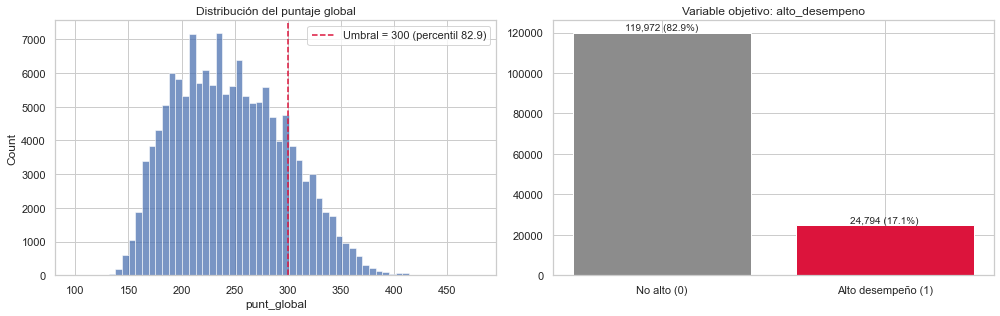

{'count': 144766.0, 'mean': 245.9, 'std': 51.59, 'min': 100.0, '25%': 205.0, '50%': 242.0, '75%': 283.0, 'max': 477.0} | asimetría: 0.312


In [13]:
# 2.3 Distribución del puntaje global y de la clase binaria derivada del umbral de 300
punt = df_raw["punt_global"].dropna()   # Se excluyen los nulos solo para describir la distribución
# kind="strict": % de estudiantes con puntaje estrictamente menor que 300
percentil_umbral = stats.percentileofscore(punt, UMBRAL_ALTO_DESEMPENO, kind="strict")
clase_eda = np.where(punt >= UMBRAL_ALTO_DESEMPENO, "Alto desempeño (1)", "No alto (0)")   # Discretización
conteo = pd.Series(clase_eda).value_counts().reindex(["No alto (0)", "Alto desempeño (1)"])   # Orden fijo para el gráfico

fig, ejes = plt.subplots(1, 2, figsize=(14, 4.5))
# Izquierda: histograma del puntaje continuo con el umbral marcado
sns.histplot(punt, bins=60, ax=ejes[0], color="#4C72B0")
ejes[0].axvline(UMBRAL_ALTO_DESEMPENO, color="crimson", ls="--",
                label=f"Umbral = {UMBRAL_ALTO_DESEMPENO} (percentil {percentil_umbral:.1f})")
ejes[0].set_title("Distribución del puntaje global"); ejes[0].set_xlabel("punt_global"); ejes[0].legend()
# Derecha: conteo de cada clase con su porcentaje (evidencia el desbalance)
ejes[1].bar(conteo.index, conteo.values, color=["#8C8C8C", "crimson"])
for i, v in enumerate(conteo.values):
    ejes[1].text(i, v, f"{v:,} ({v / conteo.sum():.1%})", ha="center", va="bottom")   # Etiqueta sobre cada barra
ejes[1].set_title("Variable objetivo: alto_desempeno")
plt.tight_layout(); guardar_figura("distribucion_objetivo"); plt.show()

# Asimetría > 0: cola larga hacia puntajes altos (pocos estudiantes con puntajes muy altos)
print(punt.describe().round(2).to_dict(), "| asimetría:", round(stats.skew(punt), 3))

🔎 **Interpretación:** El gráfico muestra la distribución del puntaje global con el umbral de 300 marcado (izquierda) y el tamaño de cada clase de la variable objetivo (derecha).
En general, el puntaje tiene media 245,9, mediana 242 y desviación 51,6, con una ligera asimetría positiva (0,31): pocos estudiantes alcanzan puntajes muy altos. El umbral de 300 queda en el **percentil 82,9**, así que solo el 17,1 % de los registros es "alto desempeño" (24.794 frente a 119.972, antes de quitar duplicados). Es un problema **desbalanceado**: un modelo que siempre dijera "no alto" acertaría el 82,9 % de las veces sin ninguna utilidad. Por eso la métrica principal es F1 y en 3.7 se evalúa el balanceo.

### 2.4 Análisis exploratorio de datos (EDA)

**¿Qué hacemos y por qué?** Preparamos la base del EDA **sin duplicados**, para que cada estudiante cuente una sola vez, y
con las variables derivadas: edad válida, subregión e indicador de alto desempeño.

In [14]:
# 2.4.0 Base para el análisis exploratorio: cada estudiante una sola vez y variables derivadas
df_eda = df_raw.drop_duplicates().copy()                                   # Evita contar dos veces a cada evaluado
df_eda["edad"] = calcular_edad(df_eda["estu_fechanacimiento"])             # Edad en años cumplidos
df_eda.loc[~df_eda["edad"].between(13, 30), "edad"] = np.nan              # Edades imposibles quedan fuera del análisis
df_eda["subregion"] = np.where(df_eda["cole_cod_mcpio_ubicacion"].isin(CODIGOS_VALLE_ABURRA),
                               "Valle de Aburrá", "Resto de Antioquia")     # Área metropolitana frente al resto
df_eda["alto"] = (df_eda["punt_global"] >= UMBRAL_ALTO_DESEMPENO).astype(int)   # 1 = alto desempeño (regla 1)
# Ficha rápida de la base del EDA
print(f"Estudiantes únicos: {len(df_eda):,} | tasa de alto desempeño: {df_eda['alto'].mean():.2%}")
print(f"Municipios: {df_eda['cole_mcpio_ubicacion'].nunique()} | "
      f"establecimientos: {df_eda['cole_cod_dane_establecimiento'].nunique():,} | "
      f"sedes: {df_eda['cole_cod_dane_sede'].nunique():,}")

Estudiantes únicos: 72,383 | tasa de alto desempeño: 17.13%
Municipios: 125 | establecimientos: 1,122 | sedes: 1,447


🔎 **Interpretación:** La salida muestra la ficha de la base del análisis exploratorio: **72.383 estudiantes únicos** (una vez quitados los duplicados exactos), con una tasa de alto desempeño del 17,13 %, distribuidos en 125 municipios, 1.122 establecimientos y 1.447 sedes.
En general, explorar sobre estudiantes únicos evita que los conteos salgan duplicados. Las tres variables derivadas (`edad`, `subregion` y `alto`) se calculan una sola vez aquí y se reutilizan en todos los gráficos de la sección. Esta base es solo descriptiva: la limpieza formal que alimenta el modelo se hace en la fase 3.

#### 2.4.1 Histogramas
**¿Qué hacemos y por qué?** Dibujamos el histograma del puntaje global, de los cinco puntajes por área y de la edad, con
la mediana marcada, para conocer la forma de cada distribución (simetría, colas, concentración). Los puntajes por área
**no entran al modelo** (son fuga de información), pero ayudan a entender el puntaje global.

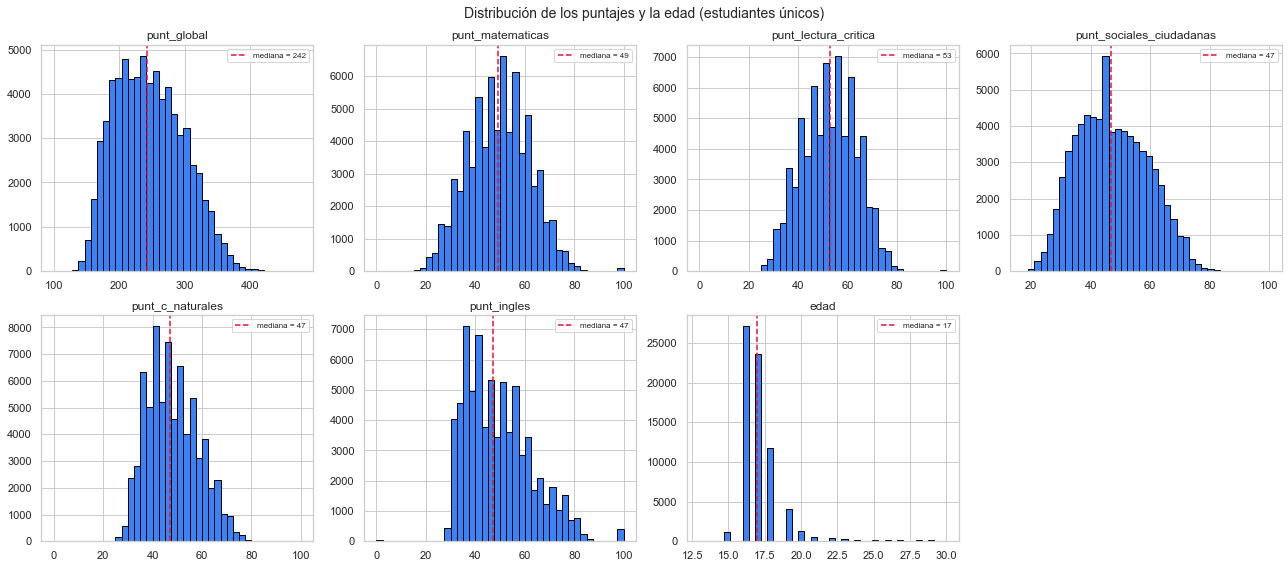

,count,mean,std,min,25%,50%,75%,max
punt_global,72383.0000,245.9000,51.5900,100.0000,205.0000,242.0000,283.0000,477.0000
punt_matematicas,72383.0000,49.2400,12.3000,0.0000,40.0000,49.0000,58.0000,100.0000
punt_lectura_critica,72383.0000,52.4200,10.8500,0.0000,44.0000,53.0000,61.0000,100.0000
punt_sociales_ciudadanas,72383.0000,47.2500,11.7900,17.0000,38.0000,47.0000,56.0000,100.0000
punt_c_naturales,72383.0000,47.8300,10.2600,0.0000,40.0000,47.0000,55.0000,100.0000
punt_ingles,72332.0000,49.1000,13.4000,0.0000,38.0000,47.0000,57.0000,100.0000
edad,71257.0000,17.1400,1.6700,13.0000,16.0000,17.0000,18.0000,30.0000


In [15]:
# 2.4.1 Histogramas de los puntajes y de la edad (forma de cada distribución)
COLS_HIST = ["punt_global", "punt_matematicas", "punt_lectura_critica", "punt_sociales_ciudadanas",
             "punt_c_naturales", "punt_ingles", "edad"]
fig, ejes = plt.subplots(2, 4, figsize=(18, 8))                            # Rejilla de 8 paneles (7 variables)
for eje, col in zip(ejes.flat, COLS_HIST):
    serie = df_eda[col].dropna()                                            # Sin nulos para el histograma
    eje.hist(serie, bins=40, color="#3b82f6", edgecolor="black")            # Barras con borde para distinguirlas
    eje.axvline(serie.median(), color="crimson", ls="--", lw=1.5, label=f"mediana = {serie.median():.0f}")
    eje.set_title(col); eje.legend(fontsize=8)
ejes.flat[-1].axis("off")                                                   # El octavo panel queda vacío
plt.suptitle("Distribución de los puntajes y la edad (estudiantes únicos)", fontsize=14)
plt.tight_layout(); guardar_figura("e_histogramas"); plt.show()
# Resumen numérico que acompaña a los histogramas
resumen_numerico = df_eda[COLS_HIST].describe().T.round(2)
guardar_tabla(resumen_numerico.reset_index().rename(columns={"index": "variable"}), "e_resumen_numerico")
resumen_numerico

🔎 **Interpretación:** El gráfico muestra los histogramas de los seis puntajes y de la edad, con la mediana marcada en rojo.
En general:
- El **puntaje global** (mediana 242, media 245,9, rango 100–477) tiene forma de campana con una cola larga hacia la derecha: pocos estudiantes superan los 350 puntos.
- Los **puntajes por área** se concentran entre 40 y 60 (medianas de 47 a 53). Lectura crítica es la más alta (mediana 53) e inglés la más asimétrica, con una acumulación en 100 que marca el tope de la escala.
- La **edad** se concentra en 16 y 17 años (mediana 17), pero tiene una cola hasta los 30 años que corresponde a estudiantes en extraedad y a programas de adultos.

Los puntajes por área no se usan como entradas del modelo, porque forman el puntaje global (fuga de información); aquí solo describen la prueba.

#### 2.4.2 Frecuencias de las variables categóricas
**¿Qué hacemos y por qué?** Para cada variable categórica de entrada mostramos el porcentaje de estudiantes en cada
categoría, con "Sin dato" como una categoría más. Es el equivalente categórico del histograma y revela las categorías
poco representadas.

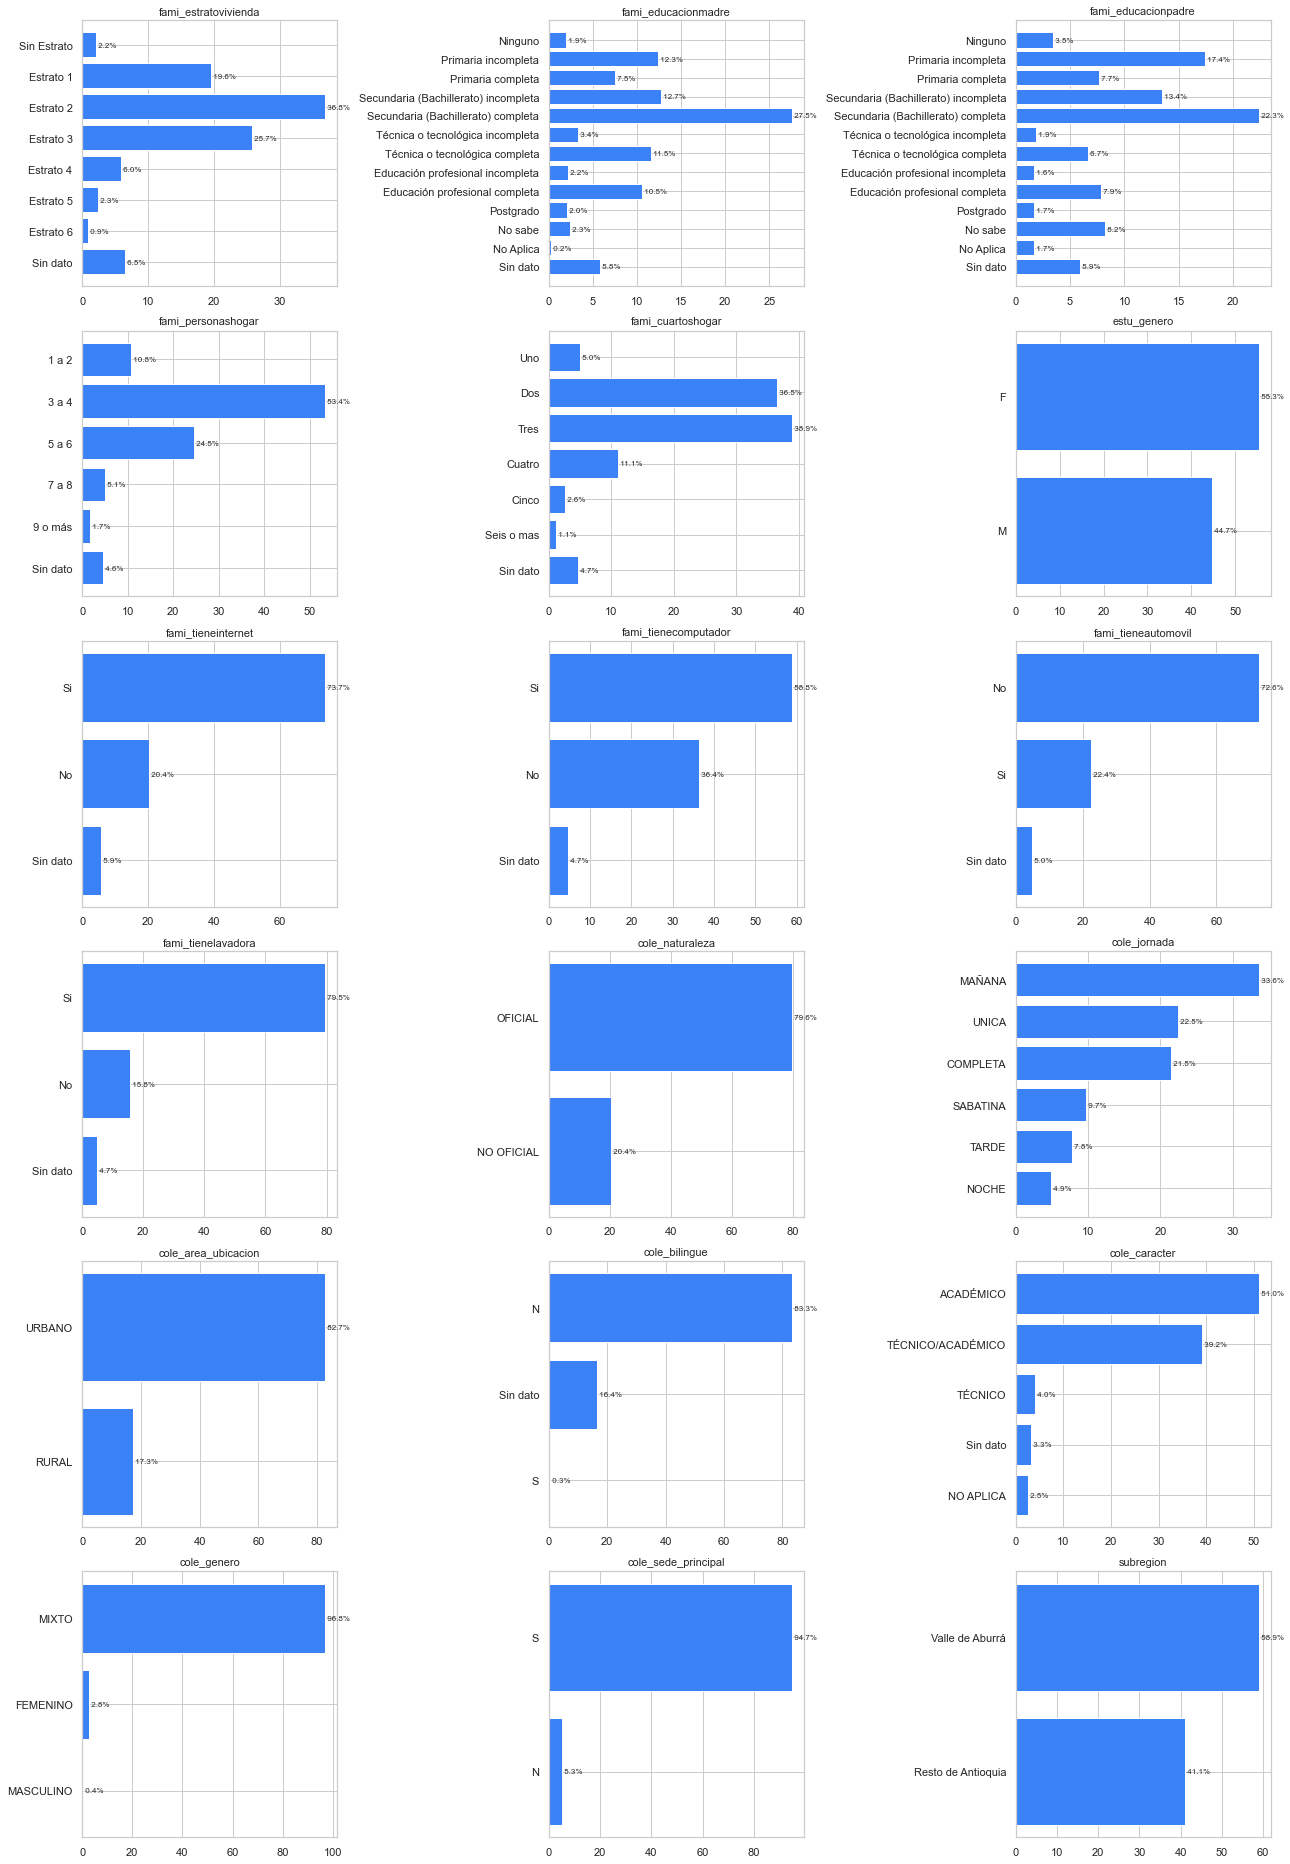

In [16]:
# 2.4.2 Frecuencia (%) de cada categoría en las variables categóricas de entrada
VARS_CAT_EDA = [v for v in FEATURES if v not in ("edad", "cole_valle_aburra")] + ["subregion"]   # 18 variables
fig, ejes = plt.subplots(6, 3, figsize=(18, 26))
for eje, var in zip(ejes.flat, VARS_CAT_EDA):
    pct = df_eda[var].fillna("Sin dato").value_counts(normalize=True).mul(100)   # % por categoría (incluye faltantes)
    if var in VARIABLES_ORDINALES:                                              # Las ordinales se muestran en su orden natural
        pct = pct.reindex([c for c in CATEGORIAS_VALIDAS[var] + ["Sin dato"] if c in pct.index])
    eje.barh(pct.index.astype(str), pct.values, color="#3b82f6")
    for y_pos, valor in enumerate(pct.values):
        eje.text(valor, y_pos, f" {valor:.1f}%", va="center", fontsize=8)     # Etiqueta con el porcentaje
    eje.set_title(var, fontsize=11); eje.invert_yaxis()                        # Primera categoría arriba
plt.tight_layout(); guardar_figura("e_frecuencias_categoricas"); plt.show()

🔎 **Interpretación:** El gráfico muestra el porcentaje de estudiantes en cada categoría de las 18 variables categóricas de entrada, incluida la categoría "Sin dato".
En general:
- **Hogar:** predominan el estrato 2 (36,8 %) y el 3 (25,7 %), madres y padres con bachillerato completo (27,5 % y 22,3 %) y hogares de 3 a 4 personas (53,4 %). El 73,7 % tiene internet, pero solo el 58,8 % tiene computador.
- **Colegio:** el 79,6 % estudia en colegios oficiales, el 82,7 % en zona urbana y el 58,9 % en el Valle de Aburrá.
- **Categorías casi vacías:** colegio bilingüe (0,3 %), colegios masculinos (0,4 %) y estrato 6 (0,9 %). Al codificarlas generan columnas con muy pocos casos.
- **Faltantes:** "No sabe" es frecuente en la educación del padre (8,2 %) y `cole_bilingue` no tiene dato en el 16,4 % de los casos.

Estas frecuencias guían la codificación (3.5) y el tratamiento de nulos (3.4).

#### 2.4.3 Gráficos exploratorios frente a la variable objetivo
**¿Qué hacemos y por qué?** Comparamos la tasa de alto desempeño entre las categorías de cuatro factores clave (educación
de la madre, estrato, computador en el hogar y jornada) con la tasa global como referencia. Así se ve qué factores
"separan" a los estudiantes.

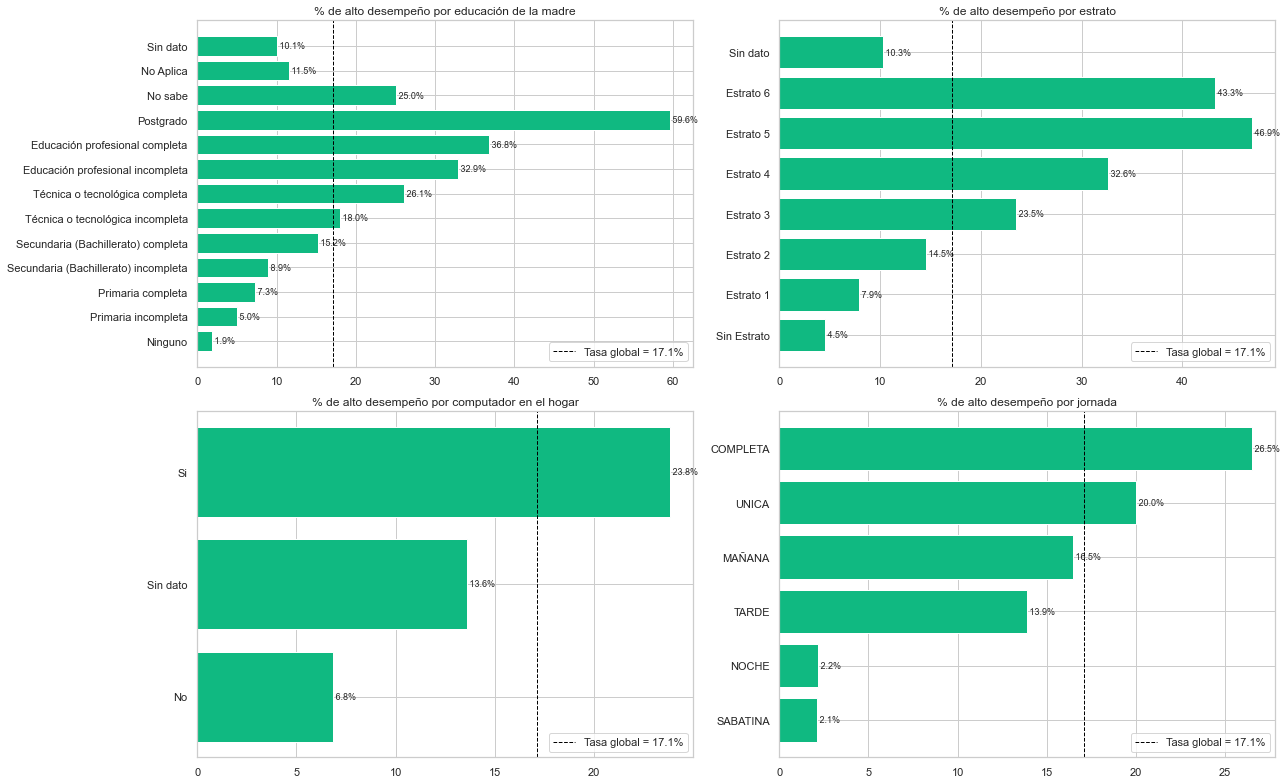

In [17]:
# 2.4.3 Tasa de alto desempeño (%) según factores del hogar y del colegio
FACTORES = {"fami_educacionmadre": "Educación de la madre", "fami_estratovivienda": "Estrato",
            "fami_tienecomputador": "Computador en el hogar", "cole_jornada": "Jornada"}
tasa_global = 100 * df_eda["alto"].mean()                                  # Línea de referencia de cada panel
fig, ejes = plt.subplots(2, 2, figsize=(18, 11))
for eje, (var, titulo) in zip(ejes.flat, FACTORES.items()):
    tasa = df_eda.groupby(df_eda[var].fillna("Sin dato"))["alto"].mean().mul(100)   # % de alto desempeño por categoría
    if var in VARIABLES_ORDINALES:                                          # Orden natural para las ordinales
        tasa = tasa.reindex([c for c in CATEGORIAS_VALIDAS[var] + ["Sin dato"] if c in tasa.index])
    else:                                                                   # De menor a mayor para las nominales
        tasa = tasa.sort_values()
    eje.barh(tasa.index.astype(str), tasa.values, color="#10b981")
    eje.axvline(tasa_global, color="black", ls="--", lw=1, label=f"Tasa global = {tasa_global:.1f}%")
    for y_pos, valor in enumerate(tasa.values):
        eje.text(valor, y_pos, f" {valor:.1f}%", va="center", fontsize=9)    # Valor al final de cada barra
    eje.set_title(f"% de alto desempeño por {titulo.lower()}"); eje.legend(loc="lower right")
plt.tight_layout(); guardar_figura("e_tasa_por_factor"); plt.show()

🔎 **Interpretación:** El gráfico muestra la tasa de alto desempeño en cada categoría de cuatro factores (educación de la madre, estrato, computador y jornada) frente a la tasa global de 17,1 % (línea punteada).
En general:
- **Educación de la madre:** la tasa crece casi en escalera, desde 1,9 % (ninguna) hasta 59,6 % (postgrado). Es el gradiente más marcado de todos.
- **Estrato:** sube de 7,9 % (estrato 1) a 46,9 % (estrato 5); "Sin estrato" queda en 4,5 %.
- **Computador:** 23,8 % con computador frente a 6,8 % sin él: más del triple.
- **Jornada:** completa (26,5 %) y única (20,0 %) superan la media, mientras la nocturna y la sabatina apenas llegan al 2 %.

Los cuatro factores separan bien las clases, así que son candidatos fuertes para el modelo.

**¿Qué hacemos y por qué?** Con diagramas de caja comparamos la **distribución completa** del puntaje global (mediana,
cuartiles y atípicos) según naturaleza, zona, subregión y jornada del colegio. La línea roja marca el umbral de 300.

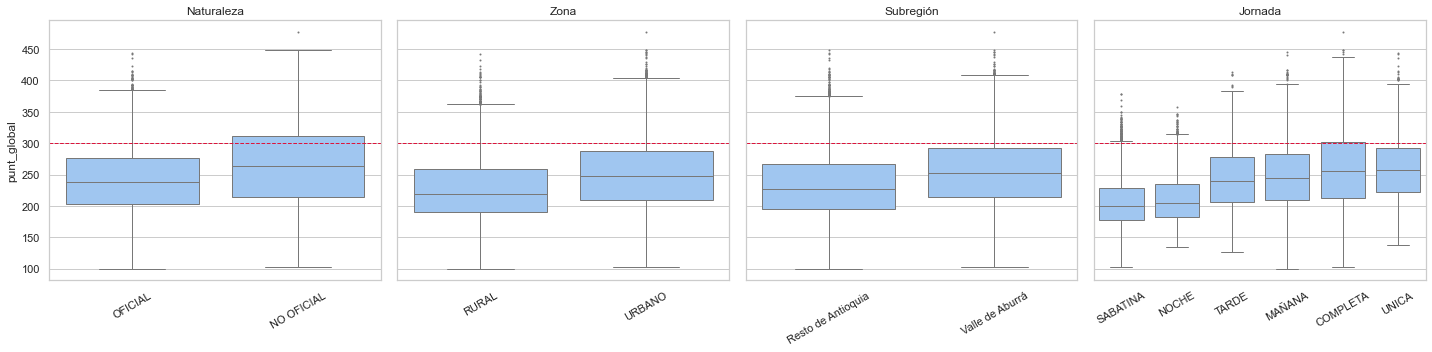

mediana
Naturaleza NO OFICIAL         264.0000
           OFICIAL            238.0000
Zona       RURAL              219.0000
           URBANO             247.0000
Subregión  Resto de Antioquia 227.0000
           Valle de Aburrá    253.0000
Jornada    COMPLETA           256.0000
           MAÑANA             244.0000
           NOCHE              205.0000
           SABATINA           199.0000
           TARDE              240.0000
           UNICA              257.0000

In [19]:
# 2.4.4 Diagramas de caja del puntaje global según características del colegio
GRUPOS_BOX = {"cole_naturaleza": "Naturaleza", "cole_area_ubicacion": "Zona", "subregion": "Subregión", "cole_jornada": "Jornada"}
fig, ejes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)               # Mismo eje Y para comparar niveles
for eje, (var, titulo) in zip(ejes, GRUPOS_BOX.items()):
    orden = df_eda.groupby(var)["punt_global"].median().sort_values().index   # Cajas ordenadas por mediana
    sns.boxplot(data=df_eda, x=var, y="punt_global", order=orden, ax=eje, color="#93c5fd", fliersize=1)
    eje.axhline(UMBRAL_ALTO_DESEMPENO, color="crimson", ls="--", lw=1)          # Umbral de alto desempeño
    eje.set_title(titulo); eje.set_xlabel(""); eje.tick_params(axis="x", rotation=30)
plt.tight_layout(); guardar_figura("e_boxplots_colegio"); plt.show()
# Mediana del puntaje por grupo: el número que resume cada caja
pd.concat({titulo: df_eda.groupby(var)["punt_global"].median() for var, titulo in GRUPOS_BOX.items()}).rename("mediana").to_frame()

🔎 **Interpretación:** El gráfico muestra diagramas de caja del puntaje global según la naturaleza, la zona, la subregión y la jornada del colegio, con el umbral de 300 en rojo; la tabla da la mediana de cada grupo.
En general, la mediana es más alta en colegios no oficiales (264 frente a 238), urbanos (247 frente a 219) y del Valle de Aburrá (253 frente a 227). En la jornada el contraste es mayor: la sabatina (199) y la nocturna (205) quedan casi enteras por debajo de 250, mientras la única (257) y la completa (256) llegan con su cuartil superior hasta cerca de 300.
En todos los grupos las cajas se solapan mucho: hay estudiantes de alto desempeño en todos los contextos. Por eso ninguna variable sola basta para predecir, y el modelo debe combinarlas.

**¿Qué hacemos y por qué?** Usamos un **gráfico de radar** para comparar de un vistazo los 10 municipios con mayor
puntaje global promedio. Solo se incluyen municipios con al menos 300 estudiantes, para que el promedio sea estable.

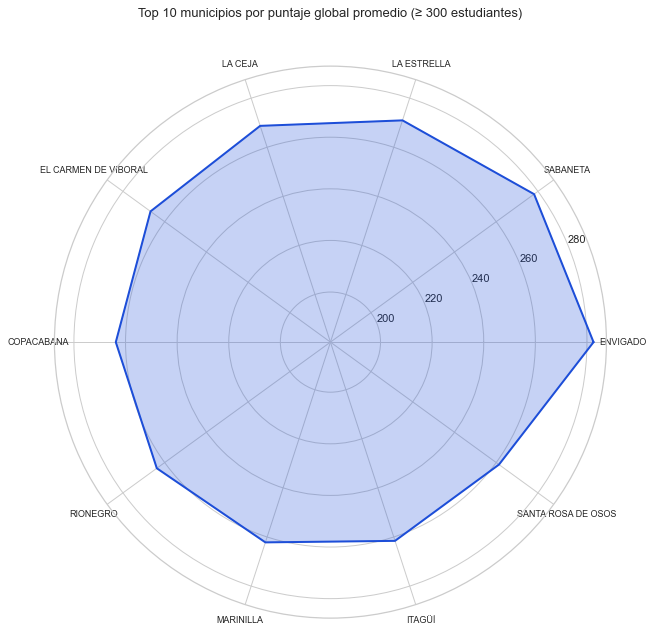

,estudiantes,puntaje_medio,tasa_alto
cole_mcpio_ubicacion,,,
ENVIGADO,2109,282.5490,0.4010
SABANETA,797,278.1430,0.3610
LA ESTRELLA,748,270.9530,0.3260
LA CEJA,673,268.7160,0.2750
EL CARMEN DE VIBORAL,696,266.7830,0.2610
COPACABANA,981,263.7760,0.2600
RIONEGRO,1577,263.7650,0.2640
MARINILLA,772,262.1920,0.2670
ITAGÜÍ,2864,261.5790,0.2420


In [20]:
# 2.4.5 Radar: los 10 municipios con mayor puntaje global promedio (con al menos 300 estudiantes)
por_mcpio = (df_eda.groupby("cole_mcpio_ubicacion")
             .agg(estudiantes=("punt_global", "size"), puntaje_medio=("punt_global", "mean"), tasa_alto=("alto", "mean")))
top10 = por_mcpio[por_mcpio["estudiantes"] >= 300].nlargest(10, "puntaje_medio")   # Umbral de tamaño: promedios estables
etiquetas = top10.index.tolist() + [top10.index[0]]                        # El radar se cierra repitiendo el primer punto
valores = top10["puntaje_medio"].tolist() + [top10["puntaje_medio"].iloc[0]]
angulos = np.linspace(0, 2 * np.pi, len(etiquetas))                        # Un ángulo por municipio (el último = el primero)
fig, eje = plt.subplots(figsize=(9, 9), subplot_kw={"polar": True})
eje.plot(angulos, valores, color="#1d4ed8", lw=2); eje.fill(angulos, valores, color="#1d4ed8", alpha=0.25)
eje.set_xticks(angulos[:-1]); eje.set_xticklabels(etiquetas[:-1], fontsize=9)
eje.set_ylim(por_mcpio["puntaje_medio"].min() - 10, top10["puntaje_medio"].max() + 5)   # Escala que resalta las diferencias
eje.set_title("Top 10 municipios por puntaje global promedio (≥ 300 estudiantes)", y=1.08, fontsize=13)
plt.tight_layout(); guardar_figura("e_radar_municipios"); plt.show()
top10.round(3)

🔎 **Interpretación:** El gráfico muestra, en forma de radar, el puntaje global promedio de los 10 municipios con mejor resultado entre los que tienen al menos 300 estudiantes.
En general, Envigado encabeza con 282,5 puntos, seguido de Sabaneta (278,1) y La Estrella (271,0); el décimo municipio ronda los 261. Los municipios del grupo pertenecen al Valle de Aburrá (Envigado, Sabaneta, La Estrella, Itagüí, Copacabana) o al Oriente cercano (La Ceja, Rionegro, Marinilla, El Carmen de Viboral), con Santa Rosa de Osos como excepción del Norte.
Todos están por encima de la media departamental (245,9), pero ninguno alcanza en promedio el umbral de 300: incluso en los mejores municipios, el alto desempeño es minoritario.

#### 2.4.6 Tablas exploratorias de datos
**¿Qué hacemos y por qué?** Listamos los 10 municipios con **mayor** y los 10 con **menor** tasa de alto desempeño (con
al menos 300 estudiantes). Esta tabla "top N" pone en cifras la brecha territorial del departamento.

In [21]:
# 2.4.6 Municipios con mayor y menor tasa de alto desempeño (≥ 300 estudiantes)
base_mcpio = (por_mcpio[por_mcpio["estudiantes"] >= 300]
              .assign(tasa_alto_pct=lambda d: (100 * d["tasa_alto"]).round(2),       # Tasa en porcentaje
                      puntaje_medio=lambda d: d["puntaje_medio"].round(1))
              .drop(columns="tasa_alto"))
tabla_top = pd.concat({"Mayor tasa": base_mcpio.nlargest(10, "tasa_alto_pct"),
                       "Menor tasa": base_mcpio.nsmallest(10, "tasa_alto_pct")})     # Dos bloques en una tabla
guardar_tabla(tabla_top.reset_index().rename(columns={"level_0": "grupo", "cole_mcpio_ubicacion": "municipio"}), "e_municipios")
print(f"Municipios con al menos 300 estudiantes: {len(base_mcpio)} de {len(por_mcpio)}")
tabla_top

Municipios con al menos 300 estudiantes: 38 de 125


estudiantes  puntaje_medio  tasa_alto_pct
           cole_mcpio_ubicacion                                           
Mayor tasa ENVIGADO                     2109       282.5000        40.0700
           SABANETA                      797       278.1000        36.1400
           LA ESTRELLA                   748       271.0000        32.6200
           LA CEJA                       673       268.7000        27.4900
           MARINILLA                     772       262.2000        26.6800
           RIONEGRO                     1577       263.8000        26.3800
           EL CARMEN DE VIBORAL          696       266.8000        26.1500
           COPACABANA                    981       263.8000        25.9900
           SANTA ROSA DE OSOS            523       261.3000        25.6200
           ITAGÜÍ                       2864       261.6000        24.2000
Menor tasa ANORÍ                         447       192.3000         1.3400
           REMEDIOS                      371       209.1000         2.4300
           NECOCLÍ                       778       209.1000         2.7000
           ZARAGOZA                      359       205.0000         2.7900
           CÁCERES                       335       212.3000         3.5800
           EL BAGRE                      766       214.6000         3.6600
           ARBOLETES                     481       213.0000         3.7400
           TURBO                        1825       214.5000         4.1600
           SEGOVIA                       367       215.8000         4.6300
           SAN PEDRO DE URABÁ            447       224.4000         4.9200

🔎 **Interpretación:** La tabla muestra los 10 municipios con mayor y los 10 con menor tasa de alto desempeño, entre los 38 municipios (de 125) con al menos 300 estudiantes.
En general, la brecha territorial es enorme: en Envigado el 40,1 % de los estudiantes supera los 300 puntos, frente al 1,3 % en Anorí, una diferencia de 30 veces. Los municipios con menor tasa se concentran en el Bajo Cauca y el Nordeste (Anorí, Remedios, Zaragoza, Cáceres, El Bagre, Segovia) y en Urabá (Necoclí, Arboletes, Turbo, San Pedro de Urabá), con puntajes medios entre 192 y 224.
Esta diferencia justifica incluir la subregión en el modelo y, en la fase 6, analizar las bandas de acompañamiento por municipio.

**¿Qué hacemos y por qué?** Con una **tabla dinámica** cruzamos estrato y naturaleza del colegio y calculamos la tasa de
alto desempeño de cada combinación, con fila y columna de **totales**. La tabla de conteos acompaña a la de tasas para
saber cuántos estudiantes respaldan cada porcentaje.

In [22]:
# 2.4.7 Tabla dinámica: tasa de alto desempeño (%) por estrato y naturaleza del colegio, con totales
pivote = pd.pivot_table(df_eda, values="alto", index="fami_estratovivienda", columns="cole_naturaleza",
                        aggfunc="mean", margins=True, margins_name="TOTAL").mul(100).round(1)   # margins = fila y columna TOTAL
pivote = pivote.reindex([c for c in CATEGORIAS_VALIDAS["fami_estratovivienda"] + ["TOTAL"] if c in pivote.index])
conteo = pd.crosstab(df_eda["fami_estratovivienda"], df_eda["cole_naturaleza"],
                     margins=True, margins_name="TOTAL").reindex(pivote.index)                 # Estudiantes por celda
guardar_tabla(pivote.reset_index(), "e_pivote_estrato_naturaleza")
print("Estudiantes por celda:"); display(conteo)
print("Tasa de alto desempeño (%):")
pivote

Estudiantes por celda:


cole_naturaleza,NO OFICIAL,OFICIAL,TOTAL
fami_estratovivienda,,,
Sin Estrato,202,1359,1561
Estrato 1,1474,12699,14173
Estrato 2,3643,23009,26652
Estrato 3,4623,13973,18596
Estrato 4,2185,2132,4317
Estrato 5,1199,495,1694
Estrato 6,452,216,668
TOTAL,13778,53883,67661


Tasa de alto desempeño (%):


cole_naturaleza,NO OFICIAL,OFICIAL,TOTAL
fami_estratovivienda,,,
Sin Estrato,8.9000,3.9000,4.5000
Estrato 1,7.0000,8.0000,7.9000
Estrato 2,19.0000,13.8000,14.5000
Estrato 3,33.3000,20.2000,23.5000
Estrato 4,48.8000,15.9000,32.6000
Estrato 5,62.3000,9.5000,46.9000
Estrato 6,61.9000,4.2000,43.3000
TOTAL,32.3000,13.9000,17.6000


🔎 **Interpretación:** La tabla dinámica muestra la tasa de alto desempeño (%) cruzando el estrato con la naturaleza del colegio; la fila y la columna TOTAL dan las tasas marginales. Encima se muestra cuántos estudiantes hay en cada celda (67.661 con estrato reportado; por eso el TOTAL es 17,6 % y no 17,1 %).
En general:
- En los **colegios no oficiales** la tasa crece con el estrato de forma sostenida: de 7,0 % en el estrato 1 a 62,3 % en el estrato 5.
- En los **oficiales** crece solo hasta el estrato 3 (20,2 %) y luego **cae** (15,9 % en el estrato 4, 9,5 % en el 5 y 4,2 % en el 6). Las dos últimas celdas son pequeñas (495 y 216 estudiantes), así que conviene leerlas con cautela.
- En el estrato 1 ocurre lo contrario: el colegio oficial (8,0 %) supera levemente al no oficial (7,0 %).

El efecto del estrato depende del tipo de colegio: es una **interacción**. Un modelo aditivo como la regresión logística solo la capta de forma aproximada.

#### 2.4.8 Análisis de correlación
**¿Qué hacemos y por qué?** Calculamos la correlación de **Spearman** (adecuada para variables ordinales) entre los
puntajes, la edad y las variables ordinales del hogar codificadas en su orden natural. Después listamos los pares más
correlacionados, que se comentan uno a uno.

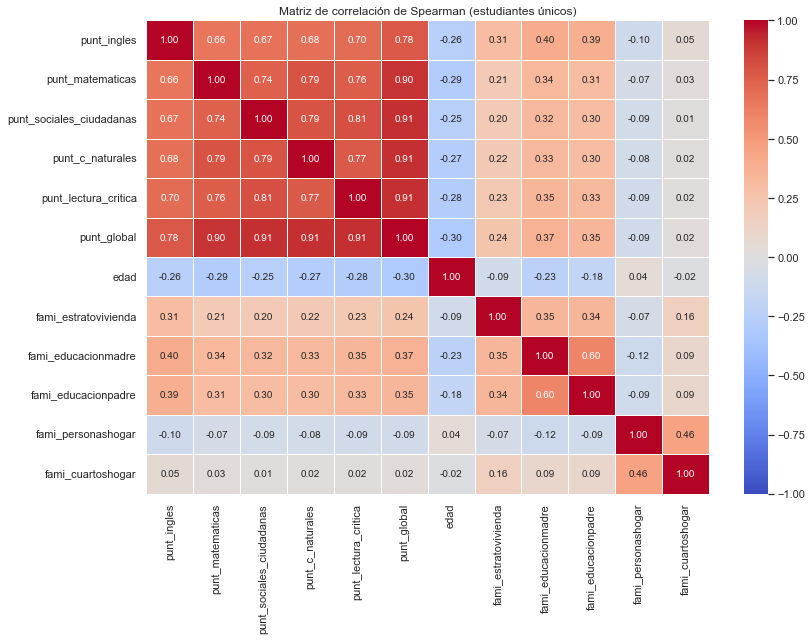

,level_0,level_1,rho
38,punt_lectura_critica,punt_global,0.9130
23,punt_sociales_ciudadanas,punt_global,0.9130
31,punt_c_naturales,punt_global,0.9080
14,punt_matematicas,punt_global,0.9040
22,punt_sociales_ciudadanas,punt_lectura_critica,0.8110
12,punt_matematicas,punt_c_naturales,0.7930
21,punt_sociales_ciudadanas,punt_c_naturales,0.7890
4,punt_ingles,punt_global,0.7800
30,punt_c_naturales,punt_lectura_critica,0.7690
13,punt_matematicas,punt_lectura_critica,0.7610


In [23]:
# 2.4.8 Matriz de correlación de Spearman entre puntajes, edad y variables ordinales del hogar
df_corr = df_eda[COLS_PUNTAJES + ["edad"]].copy()
for var in VARIABLES_ORDINALES:
    orden = [c for c in CATEGORIAS_VALIDAS[var] if c not in ("No sabe", "No Aplica")]      # Respuestas sin orden quedan como NaN
    df_corr[var] = df_eda[var].map({c: i for i, c in enumerate(orden)})                  # Código ordinal 0, 1, 2, ...
matriz = df_corr.corr(method="spearman")
fig, eje = plt.subplots(figsize=(12, 9))
sns.heatmap(matriz, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.5, ax=eje)
eje.set_title("Matriz de correlación de Spearman (estudiantes únicos)")
plt.tight_layout(); guardar_figura("e_correlaciones"); plt.show()
# Pares ordenados por magnitud (triángulo superior, sin la diagonal): insumo para la explicación
pares = matriz.where(np.triu(np.ones(matriz.shape, dtype=bool), k=1)).stack().rename("rho").reset_index()
pares.reindex(pares["rho"].abs().sort_values(ascending=False).index).head(12).round(3)

🔎 **Interpretación:** El gráfico muestra la matriz de correlación de Spearman entre los puntajes, la edad y las variables ordinales del hogar; la tabla lista los 12 pares con mayor correlación en valor absoluto, y todos son pares de puntajes.
En general:
- Los **puntajes por área** se correlacionan muy fuerte con el global (ρ = 0,90–0,91; inglés 0,78) y entre sí (0,66–0,81). Por eso no pueden usarse como entradas: serían una fuga de información.
- Entre las variables de entrada, la **educación de la madre** (ρ = 0,37) y la **del padre** (0,35) son las más asociadas con el puntaje global, seguidas por el **estrato** (0,24). La **edad** tiene relación negativa (−0,30).
- Hay **multicolinealidad moderada** entre las dos educaciones (0,60) y entre personas y cuartos del hogar (0,46).

Ninguna correlación entre entradas es tan alta como para obligar a eliminar variables, pero sí explica por qué el estrato pierde importancia en el modelo cuando ya están las educaciones (5.3.9).

### 2.5 Sesgos en los datos

**¿Qué hacemos y por qué?** Medimos, para seis variables de grupo, qué porcentaje de estudiantes representa cada grupo
(**sesgo de representación**) y cuál es su tasa de alto desempeño (**inequidad de base**, o sesgo histórico que el modelo
podría aprender).

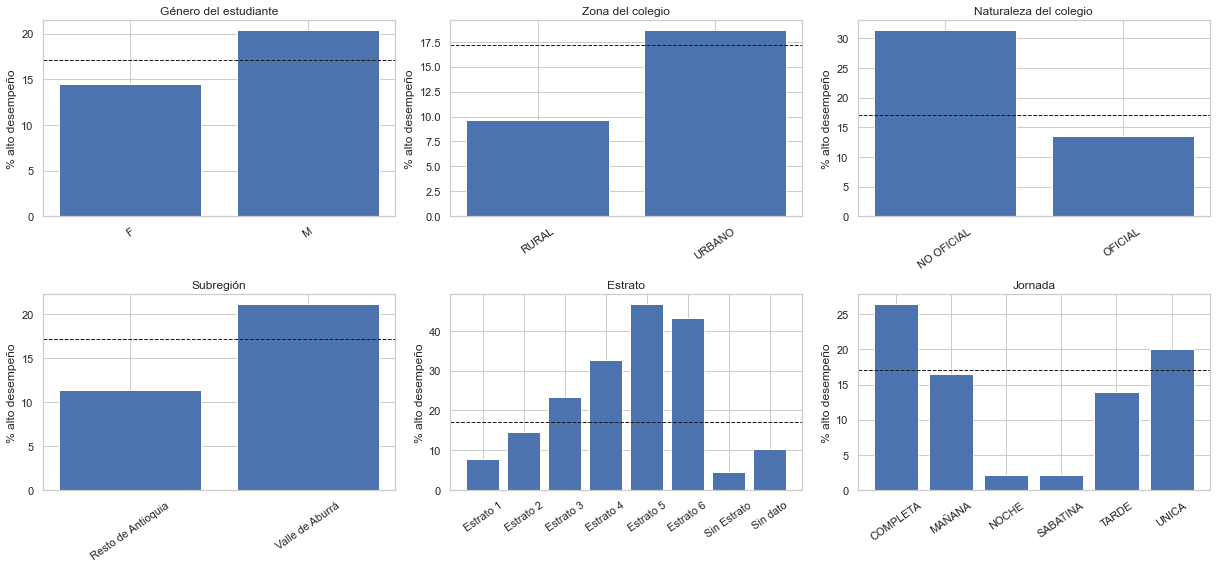

,variable,grupo,estudiantes,pct_estudiantes,tasa_alto_desempeno_pct
0,Género del estudiante,F,40011,55.2800,14.4700
1,Género del estudiante,M,32372,44.7200,20.4100
2,Zona del colegio,RURAL,12539,17.3200,9.6300
3,Zona del colegio,URBANO,59844,82.6800,18.7000
4,Naturaleza del colegio,NO OFICIAL,14753,20.3800,31.4500
5,Naturaleza del colegio,OFICIAL,57630,79.6200,13.4600
6,Subregión,Resto de Antioquia,29736,41.0800,11.3400
7,Subregión,Valle de Aburrá,42647,58.9200,21.1600
8,Estrato,Estrato 1,14173,19.5800,7.9100
9,Estrato,Estrato 2,26652,36.8200,14.5100


In [24]:
# 2.5 Representación de cada grupo y su tasa de alto desempeño (estudiantes únicos)
GRUPOS_SESGO = {"estu_genero": "Género del estudiante", "cole_area_ubicacion": "Zona del colegio",
                "cole_naturaleza": "Naturaleza del colegio", "subregion": "Subregión",
                "fami_estratovivienda": "Estrato", "cole_jornada": "Jornada"}
filas = []
for var, titulo in GRUPOS_SESGO.items():
    grupos = df_eda.groupby(df_eda[var].fillna("Sin dato"))["alto"].agg(["size", "mean"])   # Tamaño y tasa por grupo
    for grupo, fila in grupos.iterrows():
        filas.append({"variable": titulo, "grupo": grupo, "estudiantes": int(fila["size"]),
                      "pct_estudiantes": 100 * fila["size"] / len(df_eda), "tasa_alto_desempeno_pct": 100 * fila["mean"]})
tabla_sesgos = guardar_tabla(pd.DataFrame(filas).round(2), "e_sesgos")
fig, ejes = plt.subplots(2, 3, figsize=(17, 8))
for eje, (titulo, sub) in zip(ejes.flat, tabla_sesgos.groupby("variable", sort=False)):   # Un panel por variable
    eje.bar(sub["grupo"].astype(str), sub["tasa_alto_desempeno_pct"], color="#4C72B0")
    eje.axhline(100 * df_eda["alto"].mean(), ls="--", color="k", lw=1)                    # Tasa global como referencia
    eje.set_title(titulo); eje.set_ylabel("% alto desempeño"); eje.tick_params(axis="x", rotation=35)
plt.tight_layout(); guardar_figura("e_sesgos_por_grupo"); plt.show()
tabla_sesgos

🔎 **Interpretación:** El gráfico y la tabla muestran, para seis variables sensibles, cuántos estudiantes hay en cada grupo y su tasa de alto desempeño frente a la tasa global (línea punteada).
En general, los datos contienen **inequidades de base** marcadas:
- **Estrato:** la tasa pasa de 7,9 % (estrato 1) a 46,9 % (estrato 5); "Sin estrato" solo llega al 4,5 %.
- **Naturaleza y subregión:** 31,5 % en colegios no oficiales frente a 13,5 % en oficiales; 21,2 % en el Valle de Aburrá frente a 11,3 % en el resto de Antioquia.
- **Zona y género:** 18,7 % en zona urbana frente a 9,6 % en rural; 20,4 % en hombres frente a 14,5 % en mujeres.
- **Jornada:** en la nocturna y la sabatina (jóvenes y adultos) la tasa es de apenas 2,1–2,2 %.
- **Representación:** los colegios rurales (17,3 %), la jornada nocturna (4,9 %) y los estratos 5 y 6 (3,3 % entre ambos) son minoría.

Estas diferencias son un **sesgo histórico**: reflejan desigualdades reales del sistema educativo, y el modelo las aprenderá. Por eso en 5.4 se audita su desempeño por grupo.

## 3. Preparación de los datos
### 3.1 Selección de variables

**¿Qué hacemos y por qué?** Armamos el conjunto de trabajo con las 17 variables originales elegidas por criterio de
dominio y construimos dos variables nuevas: `edad` y `cole_valle_aburra`. Cada variable queda justificada en una tabla.

In [26]:
# 3.1 Conjunto de trabajo: variables seleccionadas + las dos derivadas (edad y Valle de Aburrá)
# Las 17 variables originales que entran al modelo (las otras 2 de FEATURES se construyen aquí)
VARS_ORIGINALES_SELECCIONADAS = [v for v in FEATURES if v not in ("edad", "cole_valle_aburra")]

# Se conservan también el estado del resultado (para filtrar) y el puntaje global (para construir el objetivo)
df_sel = df_raw[VARS_ORIGINALES_SELECCIONADAS + ["estu_estadoinvestigacion", "punt_global"]].copy()
df_sel["edad"] = calcular_edad(df_raw["estu_fechanacimiento"])                  # Derivada: edad en años cumplidos
df_sel["cole_valle_aburra"] = np.where(                                         # Derivada: área metropolitana
    df_raw["cole_cod_mcpio_ubicacion"].isin(CODIGOS_VALLE_ABURRA), "Sí", "No")
df_sel = df_sel[FEATURES + ["estu_estadoinvestigacion", "punt_global"]]         # Orden de columnas estable

# Justificación de dominio de cada variable seleccionada (tabla 3.1 del informe)
JUSTIFICACION_SELECCION = {
    "edad": "Derivada de la fecha de nacimiento; la extraedad se asocia con rezago escolar",
    "estu_genero": "Brechas de género documentadas en pruebas estandarizadas; permite auditar sesgo",
    "fami_estratovivienda": "Nivel socioeconómico del hogar",
    "fami_educacionmadre": "Capital cultural del hogar; predictor clásico del logro académico",
    "fami_educacionpadre": "Capital cultural del hogar",
    "fami_personashogar": "Tamaño del hogar (recursos per cápita)",
    "fami_cuartoshogar": "Condiciones de la vivienda (hacinamiento)",
    "fami_tieneinternet": "Acceso a recursos digitales de estudio",
    "fami_tienecomputador": "Acceso a recursos digitales de estudio",
    "fami_tieneautomovil": "Ingreso del hogar",
    "fami_tienelavadora": "Condiciones materiales del hogar",
    "cole_naturaleza": "Oficial vs. privado: diferencias de recursos y de selección de estudiantes",
    "cole_jornada": "Intensidad horaria y tipo de población (sabatina/noche = jóvenes y adultos)",
    "cole_area_ubicacion": "Brecha urbano-rural",
    "cole_bilingue": "Intensidad en inglés y recursos del colegio",
    "cole_caracter": "Orientación académica vs. técnica",
    "cole_genero": "Composición del colegio (mixto, femenino, masculino)",
    "cole_sede_principal": "Las sedes principales suelen concentrar más recursos",
    "cole_valle_aburra": "Resume 125 municipios en un indicador área metropolitana vs. resto de Antioquia",
}
tabla_seleccion = guardar_tabla(pd.DataFrame({"variable": FEATURES,
                                              "justificacion": [JUSTIFICACION_SELECCION[v] for v in FEATURES]}),
                                "seleccion_variables")
print(f"Variables de entrada: {len(FEATURES)} (numéricas: {len(VARIABLES_NUMERICAS)}, "
      f"ordinales: {len(VARIABLES_ORDINALES)}, nominales: {len(VARIABLES_NOMINALES)})")
tabla_seleccion

Variables de entrada: 19 (numéricas: 1, ordinales: 5, nominales: 13)


,variable,justificacion
0,edad,Derivada de la fecha de nacimiento; la extraed...
1,fami_estratovivienda,Nivel socioeconómico del hogar
2,fami_educacionmadre,Capital cultural del hogar; predictor clásico ...
3,fami_educacionpadre,Capital cultural del hogar
4,fami_personashogar,Tamaño del hogar (recursos per cápita)
5,fami_cuartoshogar,Condiciones de la vivienda (hacinamiento)
6,estu_genero,Brechas de género documentadas en pruebas esta...
7,fami_tieneinternet,Acceso a recursos digitales de estudio
8,fami_tienecomputador,Acceso a recursos digitales de estudio
9,fami_tieneautomovil,Ingreso del hogar


🔎 **Interpretación:** La tabla muestra las **19 variables de entrada** elegidas, cada una con su justificación de dominio: 1 numérica (`edad`), 5 ordinales del hogar y 13 nominales del estudiante, el hogar y el colegio.
En general, las dos variables **construidas** muestran el valor de la ingeniería de variables:
- `edad` convierte una fecha de texto en una cantidad con sentido educativo (la extraedad refleja rezago escolar).
- `cole_valle_aburra` resume 125 municipios (alta cardinalidad) en un indicador binario fácil de interpretar.

### 3.2 Descripción estadística

**¿Qué hacemos y por qué?** Resumimos el conjunto seleccionado antes de limpiarlo: número de registros y variables y
estadísticos de cada columna. Así queda evidencia del estado original.

In [27]:
# 3.2.1 Descripción estadística del conjunto seleccionado (antes de limpiar, para evidenciar problemas)
df_perfil = df_sel[FEATURES + ["punt_global"]]   # Variables de entrada + el puntaje del que sale el objetivo
# Tabla 3.2 del informe: tamaño del conjunto y tipos de variables
tabla_descripcion = guardar_tabla(pd.DataFrame({
    "metrica": ["Número de registros", "Número de variables", "Variables numéricas", "Variables categóricas"],
    "resultado": [f"{len(df_perfil):,}", f"{df_perfil.shape[1]} ({len(FEATURES)} de entrada + punt_global)",
                  "2 (edad, punt_global)",
                  f"{len(VARIABLES_ORDINALES) + len(VARIABLES_NOMINALES)} "
                  f"({len(VARIABLES_ORDINALES)} ordinales + {len(VARIABLES_NOMINALES)} nominales)"]}),
    "descripcion_estadistica")
display(tabla_descripcion)
# include="all": numéricas (media, desviación, cuartiles) y categóricas (únicos, moda y su frecuencia)
df_perfil.describe(include="all").T

,metrica,resultado
0,Número de registros,"144,766"
1,Número de variables,20 (19 de entrada + punt_global)
2,Variables numéricas,"2 (edad, punt_global)"
3,Variables categóricas,18 (5 ordinales + 13 nominales)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
edad,144766.0000,NaN,NaN,NaN,17.4833,3.4302,0.0000,16.0000,17.0000,18.0000,79.0000
fami_estratovivienda,135322,7,Estrato 2,53304,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fami_educacionmadre,136374,12,Secundaria (Bachillerato) completa,39854,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fami_educacionpadre,136232,12,Secundaria (Bachillerato) completa,32312,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fami_personashogar,138158,5,3 a 4,77258,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fami_cuartoshogar,137944,6,Tres,56286,NaN,NaN,NaN,NaN,NaN,NaN,NaN
estu_genero,144766,2,F,80022,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fami_tieneinternet,136252,2,Si,106744,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fami_tienecomputador,137940,2,Si,85188,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fami_tieneautomovil,137554,2,No,105056,NaN,NaN,NaN,NaN,NaN,NaN,NaN


🔎 **Interpretación:** La tabla muestra la descripción estadística del conjunto seleccionado: 144.766 registros y 20 variables (las 19 de entrada más el puntaje global), 2 numéricas y 18 categóricas.
En general, las categorías más frecuentes son estrato 2, madre con bachillerato completo, colegio oficial y jornada de la mañana. La edad tiene media 17,5 años, pero un **mínimo de 0 y un máximo de 79**, evidencia directa de fechas erróneas. Los datos todavía no se han limpiado a propósito: el perfilamiento debe documentar el estado original.

**¿Qué hacemos y por qué?** Generamos el reporte automático de **ydata-profiling**, entregable exigido por la actividad, con
distribuciones, faltantes, alertas y correlaciones de cada variable.

In [28]:
# 3.2.2 Reporte exploratorio automático con ydata-profiling (se adjunta como HTML al informe)
import os
os.environ["TQDM_DISABLE"] = "1"   # Oculta las barras de progreso internas de la librería (no aportan al análisis)

inicio = time.time()
with warnings.catch_warnings():    # Silencia solo aquí los avisos internos de la librería (deprecación, copias de pandas)
    warnings.simplefilter("ignore")
    from ydata_profiling import ProfileReport   # Import local: la librería es pesada y solo se usa aquí
    # interactions desactivado: los diagramas de dispersión por pares cuestan O(p²) y aportan poco con variables categóricas
    perfil = ProfileReport(df_perfil, title="Saber 11 · Antioquia 2022-2 · Variables seleccionadas",
                           interactions={"continuous": False}, progress_bar=False)
    RUTA_PERFIL = DIR_REPORTES / "perfilamiento_saber11_antioquia.html"
    perfil.to_file(RUTA_PERFIL)   # Entregable exigido por la actividad
print(f"Reporte: {RUTA_PERFIL.name} ({RUTA_PERFIL.stat().st_size / 1e6:.1f} MB) en {time.time() - inicio:.0f} s")

Reporte: perfilamiento_saber11_antioquia.html (1.6 MB) en 21 s


🔎 **Interpretación:** La salida confirma que se generó el reporte `reports/perfilamiento_saber11_antioquia.html` (unos 1,8 MB), con histogramas, faltantes, cardinalidad y alertas por variable, además de las matrices de correlación.
En general, el perfilamiento automático complementa, y no reemplaza, la revisión manual de la fase 2: sus alertas de desbalance, faltantes y alta cardinalidad coinciden con lo encontrado allí. El aviso de deprecación indica que ydata-profiling dejará de actualizarse en favor de `fg-data-profiling`; se mantiene porque la actividad lo exige explícitamente.

### 3.3 Limpieza de errores

**¿Qué hacemos y por qué?** Aplicamos reglas fijas que no aprenden de los datos: eliminar duplicados exactos y resultados
no oficiales, marcar edades imposibles y validar categorías. Por eso pueden aplicarse antes de partir los datos.

In [29]:
# 3.3 Reglas determinísticas (no aprenden de los datos), por eso se aplican antes de la partición
# Variantes de escritura conocidas -> valor canónico (se amplía si la tabla 2.2.2 muestra otras)
HOMOLOGACIONES = {"fami_cuartoshogar": {"Seis o más": "Seis o mas"}, "fami_personashogar": {"9 o mas": "9 o más"}}
df_limpio = df_sel.copy()   # Se trabaja sobre una copia para conservar df_sel como evidencia del estado original
registro = []               # Bitácora de cada regla: (error, acción, registros afectados) -> tabla 3.3 del informe

# (a) Duplicados exactos detectados con las 51 columnas originales (dos estudiantes pueden compartir el mismo perfil)
mascara = df_raw.loc[df_limpio.index].duplicated(keep="first")
df_limpio = df_limpio.loc[~mascara]
registro.append(("Filas duplicadas exactas (51 columnas)", "Eliminadas; se conserva la primera ocurrencia", int(mascara.sum())))

# (b) Resultados no oficiales: el ICFES los marca con un estado distinto de PUBLICAR
mascara = df_limpio["estu_estadoinvestigacion"] != "PUBLICAR"
df_limpio = df_limpio.loc[~mascara]
registro.append(("Resultado en investigación", "Eliminados: el puntaje no es oficial", int(mascara.sum())))

# (c) Puntaje global ausente o fuera de [0, 500]: sin él no hay variable objetivo confiable
mascara = df_limpio["punt_global"].isna() | ~df_limpio["punt_global"].between(0, 500)
df_limpio = df_limpio.loc[~mascara]
registro.append(("Puntaje global nulo o fuera de [0, 500]", "Eliminados: no se puede construir el objetivo", int(mascara.sum())))

# (d) Edad imposible: no se elimina el registro (el resto de su información es válida); se marca como faltante
mascara = df_limpio["edad"].notna() & ~df_limpio["edad"].between(13, 30)
df_limpio.loc[mascara, "edad"] = np.nan
registro.append(("Edad fuera de [13, 30]", "Convertida a NaN (imputación por mediana en el pipeline)", int(mascara.sum())))

# (e) Texto: espacios sobrantes y variantes de escritura; (f) valores fuera del dominio válido -> NaN
total_invalidas = 0
for var, validas in CATEGORIAS_VALIDAS.items():
    df_limpio[var] = df_limpio[var].str.strip().replace(HOMOLOGACIONES.get(var, {}))   # Normaliza antes de validar
    mascara = df_limpio[var].notna() & ~df_limpio[var].isin(validas)                   # Valores que siguen siendo inválidos
    total_invalidas += int(mascara.sum())
    df_limpio.loc[mascara, var] = np.nan
registro.append(("Categorías fuera del dominio válido", "Homologadas si son variantes; si no, NaN", total_invalidas))

# Construcción de la variable objetivo (regla de negocio de la fase 1)
df_limpio[OBJETIVO] = (df_limpio["punt_global"] >= UMBRAL_ALTO_DESEMPENO).astype(int)
tabla_errores = guardar_tabla(pd.DataFrame(registro, columns=["tipo_error", "accion", "registros_afectados"]),
                              "limpieza_errores")
print(f"Registros: {len(df_sel):,} -> {len(df_limpio):,}")
tabla_errores

Registros: 144,766 -> 72,357


,tipo_error,accion,registros_afectados
0,Filas duplicadas exactas (51 columnas),Eliminadas; se conserva la primera ocurrencia,72383
1,Resultado en investigación,Eliminados: el puntaje no es oficial,26
2,"Puntaje global nulo o fuera de [0, 500]",Eliminados: no se puede construir el objetivo,0
3,"Edad fuera de [13, 30]",Convertida a NaN (imputación por mediana en el...,1126
4,Categorías fuera del dominio válido,"Homologadas si son variantes; si no, NaN",0


🔎 **Interpretación:** La tabla muestra, regla por regla, cuántos registros afectó la limpieza de errores.
En general, el conjunto pasa de 144.766 a **72.357 registros**:
- Se eliminan 72.383 duplicados exactos y 26 resultados no oficiales.
- Ningún puntaje estaba nulo ni fuera de rango.
- 1.126 edades imposibles pasan a faltante (la mitad de las 2.252 detectadas, por los duplicados).
- Ninguna categoría estaba fuera de dominio.

Son reglas **determinísticas**: cada una da el mismo resultado para un registro sin mirar los demás, así que se pueden aplicar antes de partir los datos sin riesgo de fuga de información. La tabla corresponde a la tabla 3.3 del informe.

**¿Qué hacemos y por qué?** Verificamos con aserciones automáticas que después de limpiar se cumplen todas las reglas de
calidad de 2.2.

In [30]:
# 3.3.1 Verificación automática: las reglas de calidad se cumplen después de limpiar
# Los assert detienen el cuaderno si alguna regla falla: la limpieza se prueba, no se supone
assert not df_raw.loc[df_limpio.index].duplicated().any(), "Persisten duplicados"
assert (df_limpio["estu_estadoinvestigacion"] == "PUBLICAR").all()     # Solo resultados oficiales
assert df_limpio["punt_global"].between(0, 500).all()                   # Objetivo válido en todas las filas
assert df_limpio["edad"].dropna().between(13, 30).all()                 # Edades plausibles (los NaN se imputarán)
for var, validas in CATEGORIAS_VALIDAS.items():
    assert df_limpio[var].dropna().isin(validas).all(), var            # Dominios categóricos respetados
print("Todas las reglas de calidad se cumplen en df_limpio")

Todas las reglas de calidad se cumplen en df_limpio


🔎 **Interpretación:** La salida muestra que todas las aserciones pasan: no quedan duplicados, solo hay resultados oficiales, el objetivo es válido en todas las filas, las edades son plausibles y las categorías están dentro de su dominio.
En general, convertir las reglas de calidad en `assert` es una práctica de **pruebas de datos**: si la fuente cambiara y reapareciera un problema, el cuaderno se detendría aquí en lugar de entrenar un modelo con datos defectuosos.

### 3.4 Limpieza de nulos

**¿Qué hacemos y por qué?** Convertimos "No sabe" y "No Aplica" en faltantes y medimos el % de nulos por variable. La
imputación se hará dentro del pipeline, para que aprenda solo del entrenamiento.

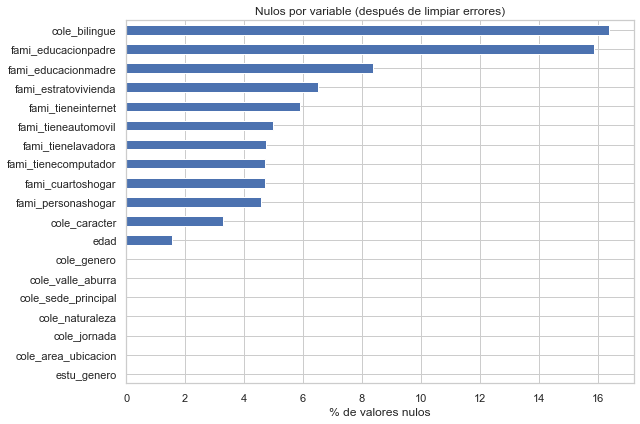

,variable,pct_nulos,metodo
14,cole_bilingue,16.3900,Categoría explícita 'DESCONOCIDO' (pipeline)
3,fami_educacionpadre,15.8800,Mediana del código ordinal + indicador de falt...
2,fami_educacionmadre,8.3600,Mediana del código ordinal + indicador de falt...
1,fami_estratovivienda,6.5200,Mediana del código ordinal + indicador de falt...
7,fami_tieneinternet,5.8800,Categoría explícita 'DESCONOCIDO' (pipeline)
9,fami_tieneautomovil,4.9800,Categoría explícita 'DESCONOCIDO' (pipeline)
10,fami_tienelavadora,4.7300,Categoría explícita 'DESCONOCIDO' (pipeline)
8,fami_tienecomputador,4.7200,Categoría explícita 'DESCONOCIDO' (pipeline)
5,fami_cuartoshogar,4.7100,Mediana del código ordinal + indicador de falt...
4,fami_personashogar,4.5600,Mediana del código ordinal + indicador de falt...


In [31]:
# 3.4 Respuestas no informativas -> NaN y diagnóstico del % de faltantes (la imputación ocurre en el pipeline)
# "No sabe" / "No Aplica" no son un nivel educativo: no tienen lugar en la escala ordinal, así que son faltantes
for var in ["fami_educacionmadre", "fami_educacionpadre"]:
    df_limpio[var] = df_limpio[var].replace(["No sabe", "No Aplica"], np.nan)

# Método de imputación por tipo de variable (tabla 3.4 del informe); los ** fusionan los tres diccionarios
METODO_IMPUTACION = {**{v: "Mediana (SimpleImputer dentro del pipeline)" for v in VARIABLES_NUMERICAS},
                     **{v: "Mediana del código ordinal + indicador de faltante (pipeline)" for v in VARIABLES_ORDINALES},
                     **{v: "Categoría explícita 'DESCONOCIDO' (pipeline)" for v in VARIABLES_NOMINALES}}
pct_nulos = (df_limpio[FEATURES].isna().mean() * 100).round(2)   # isna().mean() = proporción de faltantes
tabla_nulos = guardar_tabla(pd.DataFrame({"variable": FEATURES, "pct_nulos": pct_nulos.values,
                                          "metodo": [METODO_IMPUTACION[v] for v in FEATURES]})
                            .sort_values("pct_nulos", ascending=False), "limpieza_nulos")

fig, eje = plt.subplots(figsize=(9, 6))
pct_nulos.sort_values().plot.barh(ax=eje, color="#4C72B0")   # Barras horizontales ordenadas: fácil de comparar
eje.set_xlabel("% de valores nulos"); eje.set_title("Nulos por variable (después de limpiar errores)")
plt.tight_layout(); guardar_figura("nulos_por_variable"); plt.show()
tabla_nulos

🔎 **Interpretación:** El gráfico y la tabla muestran el porcentaje de nulos por variable después de convertir "No sabe" y "No Aplica" en faltantes, junto con el método de imputación de cada una. Los mayores son:

| Variable | % nulos |
|---|---|
| `cole_bilingue` | 16,4 |
| `fami_educacionpadre` | 15,9 (subió desde ~6 % por las respuestas "No sabe") |
| `fami_educacionmadre` | 8,4 |
| `fami_estratovivienda` | 6,5 |
| Tenencias del hogar | entre 4,7 y 5,9 |
| Edad | 1,6 |

En general, ninguna variable supera el 20 %, así que se **imputan** en lugar de descartarse. La imputación ocurre dentro del pipeline, aprendida solo con los datos de entrenamiento, para no filtrar información de la prueba.

**¿Qué hacemos y por qué?** Comprobamos si el faltante es **informativo**: si quienes no tienen dato difieren en su tasa de
alto desempeño, no conviene eliminarlos.

In [32]:
# 3.4.1 ¿El faltante es informativo? Tasa de alto desempeño con y sin dato (justifica DESCONOCIDO e indicadores)
# Si las tasas difieren mucho, el faltante NO es MCAR: eliminar esas filas sesgaría la muestra
filas = []
for var in pct_nulos[pct_nulos > 1].index:   # Solo variables con más de 1 % de faltantes
    falta = df_limpio[var].isna()
    filas.append({"variable": var, "pct_nulos": pct_nulos[var],
                  "tasa_alto_con_dato_pct": 100 * df_limpio.loc[~falta, OBJETIVO].mean(),
                  "tasa_alto_sin_dato_pct": 100 * df_limpio.loc[falta, OBJETIVO].mean()})
pd.DataFrame(filas).round(2)

,variable,pct_nulos,tasa_alto_con_dato_pct,tasa_alto_sin_dato_pct
0,edad,1.5600,17.3800,0.8000
1,fami_estratovivienda,6.5200,17.6000,10.2900
2,fami_educacionmadre,8.3600,17.3900,14.2900
3,fami_educacionpadre,15.8800,17.3600,15.9100
4,fami_personashogar,4.5600,17.2700,14.1700
5,fami_cuartoshogar,4.7100,17.2700,14.1900
6,fami_tieneinternet,5.8800,17.5800,9.9100
7,fami_tienecomputador,4.7200,17.3000,13.6000
8,fami_tieneautomovil,4.9800,17.3300,13.1800
9,fami_tienelavadora,4.7300,17.3000,13.5300


🔎 **Interpretación:** La tabla muestra la tasa de alto desempeño de los registros con y sin dato en cada variable.
En general, la diferencia es contundente:
- Quienes **no tienen dato de edad** alcanzan alto desempeño solo en el 0,8 % de los casos, frente al 17,4 % de quienes sí lo tienen.
- Sin estrato reportado la tasa es 10,3 % (frente a 17,6 %); sin dato de internet, 9,9 % (frente a 17,6 %).

Los faltantes **no son completamente aleatorios** (no son MCAR): estar incompleto se asocia a un perfil de menor desempeño. Eliminar esas filas sesgaría la muestra hacia estudiantes más favorecidos; la categoría `DESCONOCIDO` y los indicadores de faltante permiten que el modelo aproveche esta señal.

**¿Qué hacemos y por qué?** Guardamos el conjunto limpio, con un identificador que permite rastrear cada fila hasta la
descarga original.

In [29]:
# 3.4.2 Guardado del conjunto limpio (insumo reproducible para las fases siguientes)
# index_label="id_registro" conserva la posición original en df_raw: permite rastrear cualquier fila hasta la fuente
df_limpio.to_csv(DIR_PROC / "saber11_antioquia_limpio.csv.gz", index=True, index_label="id_registro", compression="gzip")
print(df_limpio.shape, "| tasa de alto desempeño:", f"{df_limpio[OBJETIVO].mean():.2%}")

(72357, 22) | tasa de alto desempeño: 17.13%


🔎 **Interpretación:** La salida muestra que se guardó el conjunto limpio (72.357 registros × 22 columnas) con una tasa de alto desempeño del 17,13 %, prácticamente la misma que antes de limpiar.
En general, la columna `id_registro` conserva la posición original de cada fila, de modo que cualquier registro puede rastrearse hasta la descarga de la API (**trazabilidad**).

### 3.5 Codificación de variables categóricas

**¿Qué hacemos y por qué?** Antes de codificar separamos la muestra de modelado (30.000) y la partición **70/30
estratificada**. El 30 % de prueba no se toca hasta la fase 5 y el resto queda como *pool* de datos nunca vistos.

In [34]:
# 3.5.1 Muestra de modelado estratificada (30.000) y partición 70/30 estratificada
# train_size con un entero = número exacto de registros; df_pool recibe el resto (nunca participa en el modelado)
df_modelo, df_pool = train_test_split(df_limpio, train_size=N_MUESTRA_MODELADO,
                                      stratify=df_limpio[OBJETIVO], random_state=RANDOM_STATE)
X, y = df_modelo[FEATURES], df_modelo[OBJETIVO]   # X = matriz de entrada; y = vector objetivo
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE)

# Verificación: la tasa de positivos debe ser prácticamente igual en todos los conjuntos (efecto de estratificar)
pd.DataFrame({"conjunto": ["Limpio total", "Muestra de modelado", "Entrenamiento (70 %)", "Prueba (30 %)", "Pool no utilizado"],
              "registros": [len(df_limpio), len(df_modelo), len(X_train), len(X_test), len(df_pool)],
              "pct_alto_desempeno": [100 * s.mean() for s in [df_limpio[OBJETIVO], y, y_train, y_test, df_pool[OBJETIVO]]]}).round(2)

,conjunto,registros,pct_alto_desempeno
0,Limpio total,72357,17.1300
1,Muestra de modelado,30000,17.1300
2,Entrenamiento (70 %),21000,17.1300
3,Prueba (30 %),9000,17.1200
4,Pool no utilizado,42357,17.1300


🔎 **Interpretación:** La tabla muestra el tamaño y la tasa de positivos de cada conjunto:

| Conjunto | Registros |
|---|---|
| Muestra de modelado | 30.000 |
| Entrenamiento | 21.000 |
| Prueba | 9.000 |
| Pool que no participa en el modelado | 42.357 |

En general, la estratificación funciona: la tasa de positivos es 17,13 % en todos los conjuntos. La prueba queda reservada hasta la fase 5 y el pool servirá en la fase 6 como datos reales nunca vistos.

**¿Qué hacemos y por qué?** Definimos el preprocesamiento por tipo de variable:
- **Numérica:** mediana y estandarización.
- **Ordinal:** orden explícito, indicador de faltante y estandarización.
- **Nominal:** categoría DESCONOCIDO y One-Hot.

In [35]:
# 3.5.2 Preprocesamiento por tipo de variable (ColumnTransformer con transformadores nativos de scikit-learn)
# Orden explícito de cada variable ordinal: el primer elemento recibe el código 0, el siguiente 1, etc.
ORDEN_ORDINALES = {
    "fami_estratovivienda": ["Sin Estrato", "Estrato 1", "Estrato 2", "Estrato 3", "Estrato 4", "Estrato 5", "Estrato 6"],
    "fami_educacionmadre": EDUCACION_ORDEN,
    "fami_educacionpadre": EDUCACION_ORDEN,
    "fami_personashogar": ["1 a 2", "3 a 4", "5 a 6", "7 a 8", "9 o más"],
    "fami_cuartoshogar": ["Uno", "Dos", "Tres", "Cuatro", "Cinco", "Seis o mas"],
}
# Numéricas: mediana (robusta a extremos) y luego estandarización z-score
pipe_numerica = Pipeline([("imputar", SimpleImputer(strategy="median")), ("escalar", StandardScaler())])
pipe_ordinal = Pipeline([
    # Categoría no vista o faltante -> NaN, que el paso siguiente imputa (así "No sabe" no rompe la escala)
    ("codificar", OrdinalEncoder(categories=[ORDEN_ORDINALES[v] for v in VARIABLES_ORDINALES],
                                 handle_unknown="use_encoded_value", unknown_value=np.nan)),
    ("imputar", SimpleImputer(strategy="median", add_indicator=True)),   # add_indicator agrega la columna "faltaba"
    ("escalar", StandardScaler())])
pipe_nominal = Pipeline([
    ("imputar", SimpleImputer(strategy="constant", fill_value="DESCONOCIDO")),   # El faltante se vuelve una categoría
    # handle_unknown="ignore": una categoría nueva en producción se codifica como todo ceros, sin error
    ("codificar", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])
# Cada tupla: (nombre, transformación, columnas); remainder="drop" descarta cualquier otra columna
preprocesador = ColumnTransformer([("num", pipe_numerica, VARIABLES_NUMERICAS),
                                   ("ord", pipe_ordinal, VARIABLES_ORDINALES),
                                   ("nom", pipe_nominal, VARIABLES_NOMINALES)], remainder="drop")

# Método de codificación por variable (tabla 3.5 del informe)
METODO_CODIFICACION = {
    **{v: "Numérica: imputación por mediana + estandarización (z-score)" for v in VARIABLES_NUMERICAS},
    **{v: f"Ordinal con orden explícito ({ORDEN_ORDINALES[v][0]} < … < {ORDEN_ORDINALES[v][-1]}) + indicador de faltante + estandarización"
       for v in VARIABLES_ORDINALES},
    **{v: "One-Hot Encoding (una columna por categoría, incluida DESCONOCIDO)" for v in VARIABLES_NOMINALES}}
tabla_codificacion = guardar_tabla(pd.DataFrame({"variable": FEATURES, "metodo": [METODO_CODIFICACION[v] for v in FEATURES]}),
                                   "codificacion")
tabla_codificacion

,variable,metodo
0,edad,Numérica: imputación por mediana + estandariza...
1,fami_estratovivienda,Ordinal con orden explícito (Sin Estrato < … <...
2,fami_educacionmadre,Ordinal con orden explícito (Ninguno < … < Pos...
3,fami_educacionpadre,Ordinal con orden explícito (Ninguno < … < Pos...
4,fami_personashogar,Ordinal con orden explícito (1 a 2 < … < 9 o m...
5,fami_cuartoshogar,Ordinal con orden explícito (Uno < … < Seis o ...
6,estu_genero,"One-Hot Encoding (una columna por categoría, i..."
7,fami_tieneinternet,"One-Hot Encoding (una columna por categoría, i..."
8,fami_tienecomputador,"One-Hot Encoding (una columna por categoría, i..."
9,fami_tieneautomovil,"One-Hot Encoding (una columna por categoría, i..."


🔎 **Interpretación:** La tabla muestra la estrategia de codificación por tipo de variable (tabla 3.5 del informe):
- **Edad:** imputación con la mediana y estandarización.
- **5 ordinales:** código ordinal con orden explícito (p. ej. "Sin Estrato" < "Estrato 1" < … < "Estrato 6"), indicador de faltante y estandarización.
- **13 nominales:** One-Hot con la categoría `DESCONOCIDO` para los faltantes.

En general, el `ColumnTransformer` todavía no se ha ajustado: es una "receta" que cada pipeline aprenderá **solo con sus datos de entrenamiento**.

**¿Qué hacemos y por qué?** Ajustamos el preprocesamiento **solo con entrenamiento** y observamos la matriz codificada que
reciben los modelos.

In [36]:
# 3.5.3 Ajuste del preprocesamiento SOLO con entrenamiento y vista de la matriz codificada
# clone crea una copia sin entrenar: el objeto "preprocesador" original queda limpio para usarlo dentro de los pipelines
preprocesador_demo = clone(preprocesador).fit(X_train)
X_train_cod = pd.DataFrame(preprocesador_demo.transform(X_train),
                           columns=preprocesador_demo.get_feature_names_out(),   # Nombres tipo "nom__cole_jornada_MAÑANA"
                           index=X_train.index)
print(f"Variables originales: {X_train.shape[1]} -> variables codificadas: {X_train_cod.shape[1]}")
X_train_cod.head()   # Numéricas y ordinales estandarizadas; nominales como columnas 0/1

Variables originales: 19 -> variables codificadas: 50


,num__edad,ord__fami_estratovivienda,ord__fami_educacionmadre,ord__fami_educacionpadre,ord__fami_personashogar,ord__fami_cuartoshogar,ord__missingindicator_fami_estratovivienda,ord__missingindicator_fami_educacionmadre,ord__missingindicator_fami_educacionpadre,ord__missingindicator_fami_personashogar,ord__missingindicator_fami_cuartoshogar,nom__estu_genero_F,nom__estu_genero_M,nom__fami_tieneinternet_DESCONOCIDO,nom__fami_tieneinternet_No,nom__fami_tieneinternet_Si,nom__fami_tienecomputador_DESCONOCIDO,nom__fami_tienecomputador_No,nom__fami_tienecomputador_Si,nom__fami_tieneautomovil_DESCONOCIDO,nom__fami_tieneautomovil_No,nom__fami_tieneautomovil_Si,nom__fami_tienelavadora_DESCONOCIDO,nom__fami_tienelavadora_No,nom__fami_tienelavadora_Si,nom__cole_naturaleza_NO OFICIAL,nom__cole_naturaleza_OFICIAL,nom__cole_jornada_COMPLETA,nom__cole_jornada_MAÑANA,nom__cole_jornada_NOCHE,nom__cole_jornada_SABATINA,nom__cole_jornada_TARDE,nom__cole_jornada_UNICA,nom__cole_area_ubicacion_RURAL,nom__cole_area_ubicacion_URBANO,nom__cole_bilingue_DESCONOCIDO,nom__cole_bilingue_N,nom__cole_bilingue_S,nom__cole_caracter_ACADÉMICO,nom__cole_caracter_DESCONOCIDO,nom__cole_caracter_NO APLICA,nom__cole_caracter_TÉCNICO,nom__cole_caracter_TÉCNICO/ACADÉMICO,nom__cole_genero_FEMENINO,nom__cole_genero_MASCULINO,nom__cole_genero_MIXTO,nom__cole_sede_principal_N,nom__cole_sede_principal_S,nom__cole_valle_aburra_No,nom__cole_valle_aburra_Sí
69731,-0.6843,0.7417,0.8634,1.1734,2.1496,1.4140,-0.2656,-0.3018,-0.4329,-0.2177,-0.2235,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000
57939,0.5194,-0.2245,0.4036,-0.2251,0.8894,0.3018,-0.2656,-0.3018,-0.4329,-0.2177,-0.2235,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,1.0000,0.0000
20044,-0.0824,0.7417,-0.5158,-0.2251,-0.3708,0.3018,-0.2656,-0.3018,-0.4329,-0.2177,-0.2235,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000
63214,-0.0824,-0.2245,-0.0561,0.2411,-0.3708,-0.8103,-0.2656,-0.3018,-0.4329,-0.2177,-0.2235,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000
41848,0.5194,-1.1906,-1.8949,-1.6236,-1.6310,-1.9225,-0.2656,-0.3018,-0.4329,-0.2177,-0.2235,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,1.0000,0.0000


🔎 **Interpretación:** La tabla muestra las primeras filas del entrenamiento ya codificado: las 19 variables se convierten en **50 columnas numéricas** (1 de edad, 5 ordinales con sus 5 indicadores de faltante y 39 columnas one-hot).
En general, las ordinales y los indicadores quedan estandarizados (media 0) y las nominales quedan como 0/1. Los nombres (`ord__…`, `nom__cole_jornada_MAÑANA`) permiten rastrear cada columna hasta su variable original.

### 3.6 Relaciones lineales y no lineales, y reducción de dimensiones

**¿Qué hacemos y por qué?** Comparamos Pearson (relación lineal) y Spearman (relación monótona) entre las variables
numéricas u ordinales y el puntaje global, usando solo el entrenamiento.

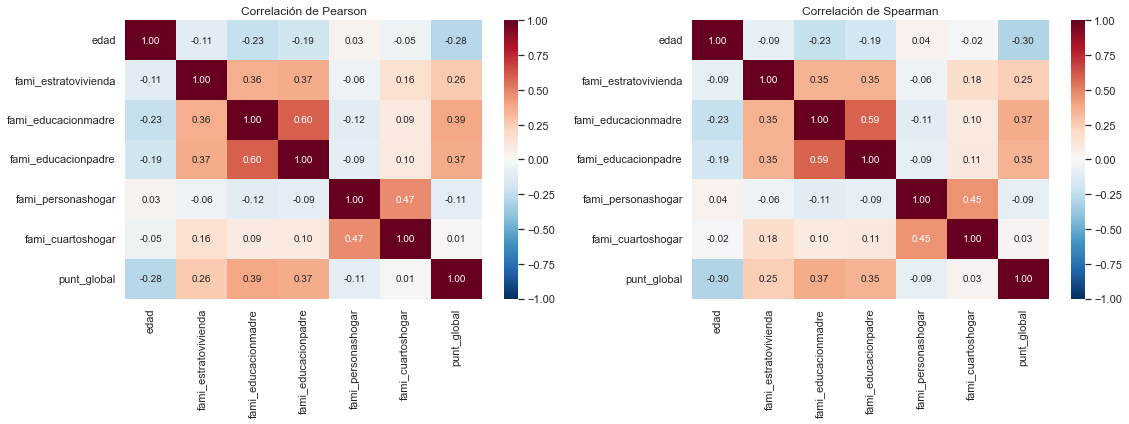

In [37]:
# 3.6.1 Correlación lineal (Pearson) y monótona (Spearman) entre variables numéricas/ordinales y el puntaje
df_analisis = X_train.copy()   # Solo entrenamiento: el análisis exploratorio tampoco debe "ver" el conjunto de prueba
for var, orden in ORDEN_ORDINALES.items():
    df_analisis[var] = df_analisis[var].map({cat: i for i, cat in enumerate(orden)})   # Código ordinal para analizar
df_analisis["punt_global"] = df_modelo.loc[X_train.index, "punt_global"]   # Puntaje continuo (más información que 0/1)
cols_corr = VARIABLES_NUMERICAS + VARIABLES_ORDINALES + ["punt_global"]

fig, ejes = plt.subplots(1, 2, figsize=(16, 6))
for eje, metodo in zip(ejes, ["pearson", "spearman"]):   # Mismo mapa de calor con cada método, para comparar
    sns.heatmap(df_analisis[cols_corr].corr(method=metodo), annot=True, fmt=".2f", cmap="RdBu_r",
                vmin=-1, vmax=1, ax=eje)                  # Escala fija [-1, 1]: rojo positivo, azul negativo
    eje.set_title(f"Correlación de {metodo.capitalize()}")
plt.tight_layout(); guardar_figura("correlaciones"); plt.show()

🔎 **Interpretación:** El gráfico muestra las matrices de correlación de Pearson y de Spearman entre el puntaje global, la edad y las variables ordinales.
En general:
- **Educación de los padres:** es la asociación más fuerte con el puntaje (madre r = 0,39 y ρ = 0,37; padre r = 0,37 y ρ = 0,35).
- **Edad:** relación negativa (r = −0,28, ρ = −0,30): a mayor edad, menor puntaje.
- **Estrato:** asociación positiva moderada (0,26).
- **Multicolinealidad:** las dos educaciones están muy correlacionadas entre sí (0,60), igual que el número de personas y de cuartos del hogar (0,47).
- **Forma de la relación:** Pearson y Spearman son muy parecidos, así que las relaciones son **aproximadamente monótonas**.

Son asociaciones, no causas: el estrato y la educación de los padres comparten un factor común, el nivel socioeconómico del hogar.

**¿Qué hacemos y por qué?** Medimos la asociación de cada variable con el objetivo con la **V de Cramér** (categóricas) y
la **información mutua**, que capta cualquier tipo de dependencia, también la no lineal.

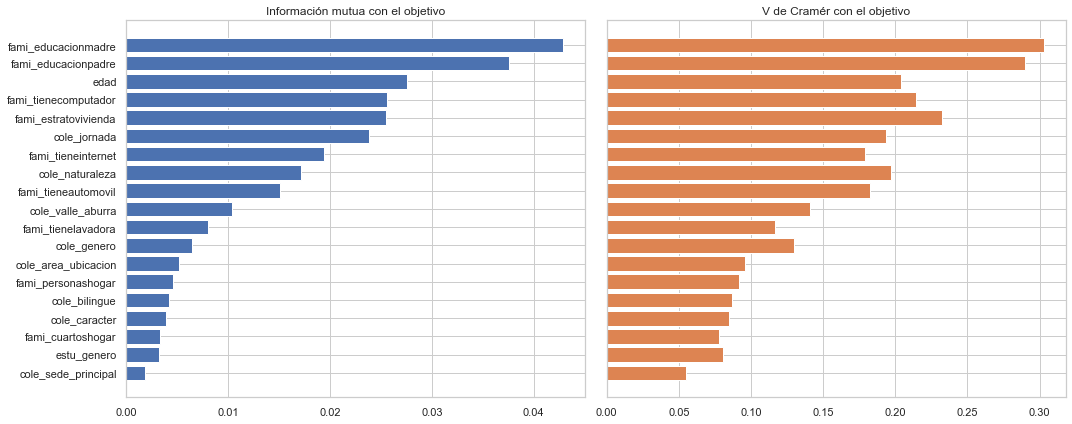

,variable,v_cramer,p_chi2,informacion_mutua,spearman_punt_global
2,fami_educacionmadre,0.3029,0.0000,0.0429,0.3734
3,fami_educacionpadre,0.2898,0.0000,0.0376,0.3504
0,edad,0.2039,0.0000,0.0276,-0.3016
8,fami_tienecomputador,0.2143,0.0000,0.0256,NaN
1,fami_estratovivienda,0.2324,0.0000,0.0255,0.2450
12,cole_jornada,0.1939,0.0000,0.0238,NaN
7,fami_tieneinternet,0.1788,0.0000,0.0194,NaN
11,cole_naturaleza,0.1970,0.0000,0.0172,NaN
9,fami_tieneautomovil,0.1827,0.0000,0.0151,NaN
18,cole_valle_aburra,0.1407,0.0000,0.0104,NaN


In [38]:
# 3.6.2 Asociación con el objetivo: V de Cramér (χ²) e información mutua (captura relaciones no lineales)
def v_cramer(x, y):
    """V de Cramér y p-valor de χ² entre dos variables categóricas."""
    tabla = pd.crosstab(x, y)                                   # Tabla de contingencia (frecuencias conjuntas)
    chi2, p_valor, _, _ = stats.chi2_contingency(tabla)         # Prueba de independencia χ²
    n = tabla.to_numpy().sum()
    return np.sqrt(chi2 / (n * (min(tabla.shape) - 1))), p_valor


# mutual_info_classif necesita números: se codifica cada categoría con un entero (el orden no importa en la IM discreta)
X_mi = pd.DataFrame(index=X_train.index)
for var in FEATURES:
    if var in VARIABLES_NUMERICAS:
        X_mi[var] = X_train[var].fillna(X_train[var].median())            # Continua: imputación simple solo para el análisis
    else:
        X_mi[var] = pd.factorize(X_train[var].fillna("DESCONOCIDO"))[0]   # Discreta: entero por categoría
info_mutua = mutual_info_classif(X_mi[FEATURES], y_train, random_state=RANDOM_STATE,
                                 discrete_features=[v not in VARIABLES_NUMERICAS for v in FEATURES])
filas = []
for var, mi in zip(FEATURES, info_mutua):
    v, p_valor = v_cramer(X_train[var].fillna("DESCONOCIDO").astype(str), y_train)
    # Spearman con el puntaje solo tiene sentido para numéricas y ordinales
    rho = df_analisis[var].corr(df_analisis["punt_global"], method="spearman") if var in cols_corr else np.nan
    filas.append({"variable": var, "v_cramer": v, "p_chi2": p_valor, "informacion_mutua": mi, "spearman_punt_global": rho})
tabla_relaciones = guardar_tabla(pd.DataFrame(filas).sort_values("informacion_mutua", ascending=False).round(4), "relaciones")

fig, ejes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)   # Mismo eje Y: se comparan ambos rankings por variable
orden_vars = tabla_relaciones["variable"]
ejes[0].barh(orden_vars, tabla_relaciones["informacion_mutua"], color="#4C72B0"); ejes[0].set_title("Información mutua con el objetivo")
ejes[1].barh(orden_vars, tabla_relaciones["v_cramer"], color="#DD8452"); ejes[1].set_title("V de Cramér con el objetivo")
ejes[0].invert_yaxis(); plt.tight_layout(); guardar_figura("asociacion_objetivo"); plt.show()   # La más asociada arriba
tabla_relaciones

🔎 **Interpretación:** El gráfico y la tabla muestran, para cada variable, la V de Cramér, el valor p de la prueba χ² y la información mutua con el objetivo.
En general, todas las variables tienen asociación estadísticamente significativa (p < 0,001), algo esperable con n = 21.000, así que lo relevante es el **tamaño** del efecto:
- Las más asociadas son la educación de la madre (V = 0,30; IM = 0,043) y la del padre (V = 0,29), la edad, tener computador, el estrato y la jornada.
- Las menos asociadas son la sede principal, el género del estudiante y el número de cuartos (V < 0,08).

La información está repartida entre varias variables y es moderada, lo que anticipa un techo de desempeño modesto para cualquier modelo.

**¿Qué hacemos y por qué?** Buscamos evidencia visual de no linealidad: el puntaje medio por edad y la tasa de alto
desempeño por estrato.

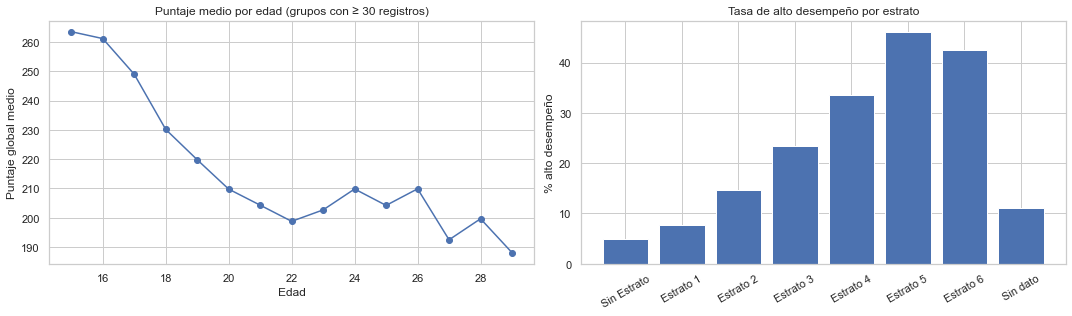

In [39]:
# 3.6.3 Evidencia de no linealidad: puntaje medio por edad y tasa de alto desempeño por estrato
fig, ejes = plt.subplots(1, 2, figsize=(15, 4.5))
# Izquierda: si la curva no es una recta, un coeficiente lineal subestima la relación edad-puntaje
por_edad = df_analisis.groupby("edad")["punt_global"].agg(["mean", "size"]).query("size >= 30")   # Grupos estables
ejes[0].plot(por_edad.index, por_edad["mean"], marker="o"); ejes[0].set_xlabel("Edad"); ejes[0].set_ylabel("Puntaje global medio")
ejes[0].set_title("Puntaje medio por edad (grupos con ≥ 30 registros)")
# Derecha: tasa de positivos por estrato, en el orden natural del estrato
por_estrato = pd.Series(y_train.groupby(X_train["fami_estratovivienda"].fillna("Sin dato")).mean() * 100)
por_estrato = por_estrato.reindex([c for c in ORDEN_ORDINALES["fami_estratovivienda"] + ["Sin dato"] if c in por_estrato.index])
ejes[1].bar(por_estrato.index, por_estrato.values, color="#4C72B0"); ejes[1].set_ylabel("% alto desempeño")
ejes[1].set_title("Tasa de alto desempeño por estrato"); ejes[1].tick_params(axis="x", rotation=30)
plt.tight_layout(); guardar_figura("no_linealidad"); plt.show()

🔎 **Interpretación:** El gráfico muestra el puntaje medio según la edad (izquierda) y la tasa de alto desempeño según el estrato (derecha).
En general:
- **Edad:** la relación **no es lineal**. El puntaje medio cae con fuerza entre los 15 y los 20 años (de ~263 a ~210) y luego se estabiliza alrededor de 200–210. Un coeficiente lineal único no describe bien esa forma, y por eso la información mutua sí la capta.
- **Estrato:** la tasa crece de forma monótona hasta el estrato 5 (~46 %) y baja un poco en el estrato 6 (~42 %, con pocos casos). "Sin estrato" es el grupo más bajo (~5 %).

Por eso tiene sentido comparar modelos lineales con modelos flexibles (árboles, SVM RBF) en la fase 4.

**¿Qué hacemos y por qué?** Evaluamos la **reducción de dimensiones con PCA**: cuántas componentes hacen falta para
explicar el 90 % de la varianza de la matriz codificada.

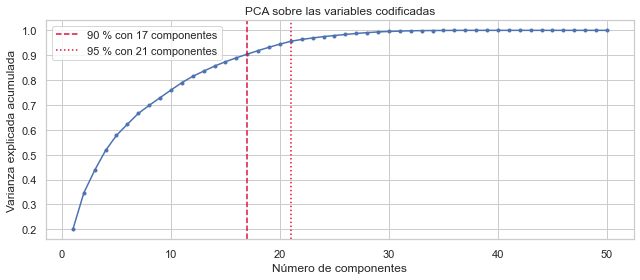

Dimensión codificada: 50 | 90 %: 17 componentes | 95 %: 21 componentes


In [40]:
# 3.6.4 Varianza explicada por componentes principales sobre la matriz codificada de entrenamiento
pca = PCA(random_state=RANDOM_STATE).fit(X_train_cod)      # Sin n_components: calcula todas las componentes
var_acum = np.cumsum(pca.explained_variance_ratio_)        # Varianza explicada acumulada
n_90 = int(np.searchsorted(var_acum, 0.90) + 1)            # Mínimo de componentes para llegar al 90 %
n_95 = int(np.searchsorted(var_acum, 0.95) + 1)            # ... y al 95 %

fig, eje = plt.subplots(figsize=(9, 4))
eje.plot(range(1, len(var_acum) + 1), var_acum, marker="o", ms=3)   # Curva de varianza acumulada
eje.axvline(n_90, ls="--", color="crimson", label=f"90 % con {n_90} componentes")
eje.axvline(n_95, ls=":", color="crimson", label=f"95 % con {n_95} componentes")
eje.set_xlabel("Número de componentes"); eje.set_ylabel("Varianza explicada acumulada")
eje.set_title("PCA sobre las variables codificadas"); eje.legend()
plt.tight_layout(); guardar_figura("pca_varianza"); plt.show()
print(f"Dimensión codificada: {X_train_cod.shape[1]} | 90 %: {n_90} componentes | 95 %: {n_95} componentes")

🔎 **Interpretación:** El gráfico muestra la varianza explicada acumulada por los componentes principales de las 50 columnas codificadas.
En general, PCA necesita **17 componentes para explicar el 90 %** de la varianza y 21 para el 95 %, y la curva crece de forma gradual, sin un "codo" marcado. La varianza está repartida porque muchas columnas son dummies casi independientes; reducir a 17 componentes quitaría dimensiones, pero cada componente mezclaría variables heterogéneas (jornada, estrato, tenencias) y perdería su significado.

**¿Qué hacemos y por qué?** Decidimos con evidencia: comparamos el F1 en validación cruzada de un mismo modelo con y sin PCA.

In [41]:
# 3.6.5 Prueba empírica: ¿PCA mejora el F1 de un modelo de referencia? (regresión logística balanceada, CV 5-fold)
# Se comparan dos pipelines idénticos salvo por el paso PCA; la decisión se basa en evidencia, no en costumbre
referencia = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)
f1_sin_pca = cross_val_score(Pipeline([("prep", clone(preprocesador)), ("modelo", clone(referencia))]),
                             X_train, y_train, cv=CV, scoring="f1", n_jobs=-1)
f1_con_pca = cross_val_score(Pipeline([("prep", clone(preprocesador)),
                                       ("pca", PCA(n_components=0.90, random_state=RANDOM_STATE)),   # 0.90 = 90 % de varianza
                                       ("modelo", clone(referencia))]),
                             X_train, y_train, cv=CV, scoring="f1", n_jobs=-1)
APLICAR_PCA = bool(f1_con_pca.mean() > f1_sin_pca.mean() + 0.01)   # Solo si mejora el F1 en más de 0,01
justificacion_pca = (
    f"PCA: {n_90} de {X_train_cod.shape[1]} componentes explican el 90 % de la varianza. "
    f"F1 CV sin PCA = {f1_sin_pca.mean():.4f}; con PCA = {f1_con_pca.mean():.4f}. "
    + ("Se aplica porque mejora el F1 en más de 0,01." if APLICAR_PCA else
       "No se aplica: no mejora el desempeño, la dimensión ya es baja y se perdería la interpretabilidad de las variables."))
guardar_tabla(pd.DataFrame({"tecnica": ["Análisis de Componentes Principales (PCA)"], "justificacion": [justificacion_pca]}),
              "reduccion_dimensiones")   # Tabla 3.6 del informe
print(justificacion_pca)

PCA: 17 de 50 componentes explican el 90 % de la varianza. F1 CV sin PCA = 0.4685; con PCA = 0.4592. No se aplica: no mejora el desempeño, la dimensión ya es baja y se perdería la interpretabilidad de las variables.


🔎 **Interpretación:** La tabla muestra el F1 en validación cruzada de la regresión logística con y sin PCA.
En general, con PCA el F1 **baja** de 0,4685 a 0,4592. Como no mejora (el criterio exigía al menos +0,01), **no se aplica** reducción de dimensiones. PCA maximiza la varianza, no el poder predictivo, y aquí descarta parte de la señal útil para la clase minoritaria. Conservar las variables originales, además, permite interpretar el modelo en la fase 5.

### 3.7 Balanceo de clases

**¿Qué hacemos y por qué?** Con un modelo de referencia comparamos cuatro estrategias frente al desbalance (~17 % de
positivos): ninguna, ponderación de clases, submuestreo y SMOTE.

In [42]:
# 3.7.1 Comparación de estrategias de balanceo con un modelo de referencia (regresión logística, CV 5-fold)
def pipeline_referencia(muestreador=None, class_weight=None):
    """Preprocesamiento + (muestreador opcional) + regresión logística."""
    pasos = [("preprocesamiento", clone(preprocesador))]
    if muestreador is not None:
        pasos.append(("balanceo", muestreador))   # imblearn aplica el muestreo solo durante fit, nunca en predict
    pasos.append(("modelo", LogisticRegression(max_iter=2000, class_weight=class_weight, random_state=RANDOM_STATE)))
    return ImbPipeline(pasos)


# Solo los muestreadores compiten para el pipeline final: sirven para los 8 modelos (class_weight no existe en KNN)
MUESTREADORES = {"Submuestreo aleatorio (RandomUnderSampler)": RandomUnderSampler(random_state=RANDOM_STATE),
                 "Sobremuestreo sintético (SMOTE)": SMOTE(random_state=RANDOM_STATE)}
estrategias = {"Sin balanceo": pipeline_referencia(),                                   # Línea base
               "Ponderación de clases (class_weight)": pipeline_referencia(class_weight="balanced"),
               **{nombre: pipeline_referencia(m) for nombre, m in MUESTREADORES.items()}}
filas = []
for nombre, pipe in estrategias.items():
    # cross_validate devuelve una métrica por fold; se reportan la media y la desviación del F1
    res = cross_validate(pipe, X_train, y_train, cv=CV, scoring=["f1", "precision", "recall", "roc_auc"], n_jobs=-1)
    filas.append({"estrategia": nombre, "f1": res["test_f1"].mean(), "f1_std": res["test_f1"].std(),
                  "precision": res["test_precision"].mean(), "recall": res["test_recall"].mean(),
                  "roc_auc": res["test_roc_auc"].mean()})
df_balanceo = guardar_tabla(pd.DataFrame(filas).round(4), "balanceo_comparacion")
df_balanceo

,estrategia,f1,f1_std,precision,recall,roc_auc
0,Sin balanceo,0.3157,0.0162,0.6052,0.2138,0.8015
1,Ponderación de clases (class_weight),0.4685,0.0120,0.3406,0.7504,0.8015
2,Submuestreo aleatorio (RandomUnderSampler),0.4696,0.0121,0.3414,0.7526,0.8010
3,Sobremuestreo sintético (SMOTE),0.4675,0.0120,0.3406,0.7456,0.8000


🔎 **Interpretación:** La tabla muestra el efecto de cada estrategia de balanceo sobre la regresión logística en validación cruzada.
En general, sin balanceo el modelo tiene Precision 0,61 pero **Recall 0,21**: detecta solo uno de cada cinco estudiantes de alto desempeño, y su F1 es 0,316. Las tres estrategias elevan el Recall a ~0,75 y el F1 a ~0,47:

| Estrategia | F1 en CV |
|---|---|
| RandomUnderSampler | 0,4696 |
| class_weight | 0,4685 |
| SMOTE | 0,4673 |

La **ROC-AUC casi no cambia** (~0,80): el balanceo no mejora la capacidad de ordenar a los estudiantes, solo desplaza el punto de decisión hacia la clase minoritaria. Balancear es, en buena medida, elegir un umbral distinto.

**¿Qué hacemos y por qué?** Elegimos el muestreador con mejor F1 y visualizamos cómo cambia la distribución de clases del
entrenamiento. Solo se aplica dentro de los folds de entrenamiento.

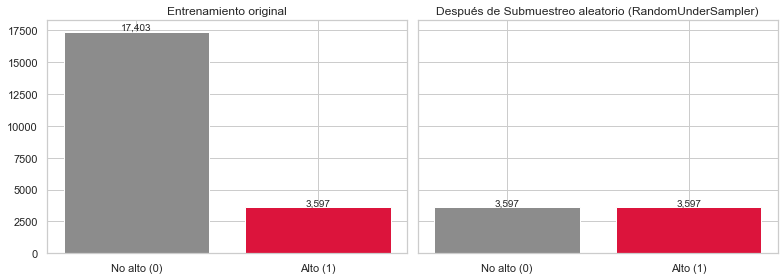

Submuestreo aleatorio (RandomUnderSampler): mejor F1 en CV entre los muestreadores (0.4696 frente a 0.3157 sin balanceo). Se aplica dentro del pipeline (imblearn), solo en los folds de entrenamiento, para no contaminar la validación ni el test.


In [43]:
# 3.7.2 Elección del muestreador (mejor F1) y efecto sobre la distribución de clases del entrenamiento
mejor_balanceo = df_balanceo[df_balanceo["estrategia"].isin(MUESTREADORES)].sort_values("f1", ascending=False).iloc[0]
BALANCEADOR = MUESTREADORES[mejor_balanceo["estrategia"]]              # Se usará en todos los pipelines de la fase 4
_, y_balanceado = clone(BALANCEADOR).fit_resample(X_train_cod, y_train)   # Solo para visualizar el efecto

fig, ejes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for eje, serie, titulo in zip(ejes, [y_train, pd.Series(y_balanceado)],
                              ["Entrenamiento original", f"Después de {mejor_balanceo['estrategia']}"]):
    conteo = serie.value_counts().sort_index()   # Índice 0 y 1 en orden
    eje.bar(["No alto (0)", "Alto (1)"], conteo.values, color=["#8C8C8C", "crimson"])
    for i, v in enumerate(conteo.values):
        eje.text(i, v, f"{v:,}", ha="center", va="bottom")   # Conteo sobre cada barra
    eje.set_title(titulo)
plt.tight_layout(); guardar_figura("balanceo_distribucion"); plt.show()

# Justificación para la tabla 3.7 del informe, con las cifras obtenidas
f1_sin_balanceo = df_balanceo.loc[df_balanceo["estrategia"] == "Sin balanceo", "f1"].iloc[0]
justificacion_balanceo = (
    f"{mejor_balanceo['estrategia']}: mejor F1 en CV entre los muestreadores ({mejor_balanceo['f1']:.4f} frente a "
    f"{f1_sin_balanceo:.4f} sin balanceo). Se aplica dentro del pipeline (imblearn), solo en los folds de entrenamiento, "
    "para no contaminar la validación ni el test.")
guardar_tabla(pd.DataFrame({"tecnica": [mejor_balanceo["estrategia"]], "justificacion": [justificacion_balanceo]}), "balanceo")
print(justificacion_balanceo)

🔎 **Interpretación:** El gráfico muestra la distribución de clases en un fold de entrenamiento antes y después de aplicar el balanceador elegido, **RandomUnderSampler**.
En general, el submuestreo deja el entrenamiento balanceado 1:1 (≈3.600 casos por clase, frente a ≈17.400 negativos originales). Su ventaja sobre SMOTE (0,0023 de F1) es mucho menor que la desviación entre folds (~0,012), así que en la práctica las estrategias empatan; se prefiere porque reduce el costo de cómputo (el SVM entrena con ~6 mil filas por fold en lugar de ~28 mil con SMOTE). Solo actúa en `fit` dentro de cada fold, de modo que validación y prueba conservan la distribución real.

## 4. Modelamiento

**Variables de entrada y salida del modelo**

| Rol | Variables |
|---|---|
| Entrada numérica (1) | `edad` |
| Entrada ordinal (5) | `fami_estratovivienda`, `fami_educacionmadre`, `fami_educacionpadre`, `fami_personashogar`, `fami_cuartoshogar` |
| Entrada nominal (13) | `estu_genero`, `fami_tieneinternet`, `fami_tienecomputador`, `fami_tieneautomovil`, `fami_tienelavadora`, `cole_naturaleza`, `cole_jornada`, `cole_area_ubicacion`, `cole_bilingue`, `cole_caracter`, `cole_genero`, `cole_sede_principal`, `cole_valle_aburra` |
| **Salida** | `alto_desempeno` (1 = puntaje global ≥ 300) |

**¿Qué hacemos y por qué?** Creamos una "fábrica" de pipelines con preprocesamiento, balanceo y modelo, y una función de
validación cruzada común. Todos los modelos se evalúan igual y con los mismos 5 folds, así que la comparación es justa y
sin fuga de información.

In [44]:
# 4.0 Fábrica de pipelines y función de validación cruzada común
def crear_pipeline(modelo):
    """Preprocesamiento + (PCA opcional) + balanceo + modelo; todo se ajusta dentro de cada fold."""
    pasos = [("preprocesamiento", clone(preprocesador))]   # clone: cada pipeline recibe su propio preprocesador sin entrenar
    if APLICAR_PCA:                                         # Decisión tomada con evidencia en la prueba de PCA (fase 3)
        pasos.append(("pca", PCA(n_components=0.90, random_state=RANDOM_STATE)))
    pasos += [("balanceo", clone(BALANCEADOR)), ("modelo", modelo)]   # Muestreador elegido al comparar estrategias de balanceo (fase 3)
    return ImbPipeline(pasos)


METRICAS_CV = ["f1", "precision", "recall", "accuracy", "roc_auc"]   # F1 es la principal; las demás dan contexto


def evaluar_cv(nombre, modelo):
    """CV estratificada 5-fold sobre el entrenamiento; devuelve el resumen y el F1 de cada fold."""
    inicio = time.time()
    # n_jobs=-1 entrena los 5 folds en paralelo con todos los núcleos disponibles
    res = cross_validate(crear_pipeline(modelo), X_train, y_train, cv=CV, scoring=METRICAS_CV, n_jobs=-1)
    resumen = {"modelo": nombre, **{f"{m}_mean": res[f"test_{m}"].mean() for m in METRICAS_CV},
               "f1_std": res["test_f1"].std(), "tiempo_s": time.time() - inicio}   # std del F1 = estabilidad
    return resumen, res["test_f1"]   # También el F1 por fold, para las pruebas estadísticas pareadas


# Se muestran los pasos del pipeline para verificar el orden
print("Pasos del pipeline:", [nombre for nombre, _ in crear_pipeline(LogisticRegression()).steps])

Pasos del pipeline: ['preprocesamiento', 'balanceo', 'modelo']


🔎 **Interpretación:** La salida muestra la estructura del pipeline que comparten todos los modelos: `preprocesamiento` → `balanceo` → `modelo`. No hay paso `pca`, por la decisión tomada en 3.6.5.
En general, con esta fábrica cada modelo se evalúa exactamente igual: mismos folds, mismo preprocesamiento aprendido dentro de cada fold y mismo muestreador. Cualquier diferencia de F1 se debe al algoritmo y no a cómo se prepararon los datos.

### 4.1 Modelos clásicos

**¿Qué hacemos y por qué?** Evaluamos con validación cruzada los cinco modelos clásicos del curso: Regresión Logística,
KNN, Árbol de Decisión, SVM y Random Forest, con hiperparámetros iniciales razonables.

In [45]:
# 4.1.1 Cinco modelos clásicos con hiperparámetros iniciales razonables
modelos_clasicos = {
    "Regresión Logística": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),   # max_iter alto: asegura convergencia
    "KNN": KNeighborsClassifier(n_neighbors=15),                                           # k impar evita empates
    "Árbol de Decisión": DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE),   # Profundidad acotada contra sobreajuste
    "SVM (RBF)": SVC(kernel="rbf", C=1.0, gamma="scale", random_state=RANDOM_STATE),       # Valores por defecto de scikit-learn
    # n_jobs=1 dentro del modelo: el paralelismo ya lo aporta la validación cruzada (evita saturar la CPU)
    "Random Forest": RandomForestClassifier(n_estimators=200, min_samples_leaf=5, random_state=RANDOM_STATE, n_jobs=1),
}
# Texto para la tabla 4.1 del informe
HIPERPARAMETROS_INICIALES = {
    "Regresión Logística": "C=1.0, penalización L2, max_iter=2000",
    "KNN": "n_neighbors=15, weights='uniform', p=2 (euclidiana)",
    "Árbol de Decisión": "max_depth=8, criterion='gini', min_samples_leaf=1",
    "SVM (RBF)": "kernel='rbf', C=1.0, gamma='scale'",
    "Random Forest": "n_estimators=200, min_samples_leaf=5, max_features='sqrt'",
}
resultados_cv, f1_por_fold = [], {}   # Resúmenes por modelo y F1 de cada fold (para comparaciones pareadas)
for nombre, modelo in modelos_clasicos.items():
    resumen, f1s = evaluar_cv(nombre, modelo)
    resultados_cv.append(resumen)
    f1_por_fold[nombre] = f1s
    print(f"{nombre:<22} F1 = {resumen['f1_mean']:.4f} ± {resumen['f1_std']:.4f}  ({resumen['tiempo_s']:.0f} s)")

df_clasicos = pd.DataFrame(resultados_cv).sort_values("f1_mean", ascending=False).reset_index(drop=True)   # Ranking
guardar_tabla(pd.DataFrame({"modelo": df_clasicos["modelo"],
                            "hiperparametros_iniciales": df_clasicos["modelo"].map(HIPERPARAMETROS_INICIALES),
                            "metrica": "F1 (clase positiva)", "cv_mean": df_clasicos["f1_mean"].round(4),
                            "cv_std": df_clasicos["f1_std"].round(4)}), "modelos_clasicos")   # Tabla 4.1 del informe
df_clasicos.round(4)

Regresión Logística    F1 = 0.4696 ± 0.0121  (1 s)
KNN                    F1 = 0.4289 ± 0.0093  (1 s)
Árbol de Decisión      F1 = 0.4298 ± 0.0130  (1 s)
SVM (RBF)              F1 = 0.4659 ± 0.0131  (5 s)
Random Forest          F1 = 0.4690 ± 0.0099  (2 s)


,modelo,f1_mean,precision_mean,recall_mean,accuracy_mean,roc_auc_mean,f1_std,tiempo_s
0,Regresión Logística,0.4696,0.3414,0.7526,0.7086,0.8010,0.0121,0.8022
1,Random Forest,0.4690,0.3445,0.7348,0.7150,0.8002,0.0099,1.5385
2,SVM (RBF),0.4659,0.3359,0.7598,0.7015,0.7943,0.0131,4.6181
3,Árbol de Decisión,0.4298,0.3058,0.7231,0.6711,0.7520,0.0130,0.6491
4,KNN,0.4289,0.2983,0.7629,0.6520,0.7687,0.0093,1.1622


🔎 **Interpretación:** La tabla muestra el desempeño de los cinco modelos clásicos en validación cruzada, ordenados por F1:

| Modelo | F1 en CV |
|---|---|
| Regresión Logística | 0,4696 ± 0,012 |
| Random Forest | 0,4690 ± 0,010 |
| SVM RBF | 0,4659 ± 0,013 |
| Árbol de decisión | 0,4298 |
| KNN | 0,4289 |

En general:
- **Los tres primeros empatan en la práctica:** sus diferencias son mucho menores que la desviación entre folds y los tres tienen ROC-AUC cercana a 0,80. Que el modelo **lineal** empate con los flexibles indica que la señal disponible es esencialmente aditiva.
- **El árbol y KNN quedan claramente atrás:** el árbol individual tiene alta varianza y KNN pierde eficacia con 50 dimensiones, en su mayoría binarias.
- **Costo:** el SVM es, con diferencia, el más lento (unos 25 s frente a 2 s de la logística), aun con el submuestreo.

**¿Qué hacemos y por qué?** Miramos la variabilidad del F1 entre folds: dos modelos con cajas solapadas pueden no ser
realmente distintos.

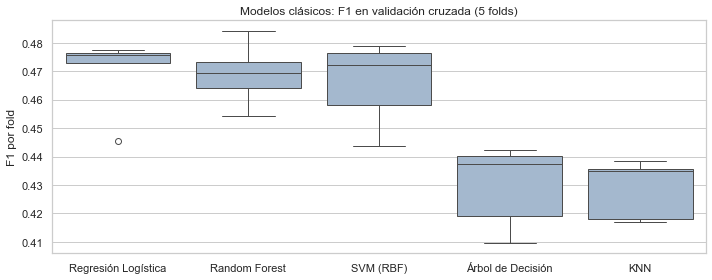

In [46]:
# 4.1.2 Variabilidad del F1 entre folds (misma partición para todos: comparación pareada)
# Un diagrama de caja muestra mediana, dispersión y folds atípicos: dos modelos con cajas solapadas pueden no diferir realmente
fig, eje = plt.subplots(figsize=(10, 4))
sns.boxplot(data=pd.DataFrame(f1_por_fold)[df_clasicos["modelo"]], ax=eje, color="#9DB7D5")   # Orden del ranking
eje.set_ylabel("F1 por fold"); eje.set_title("Modelos clásicos: F1 en validación cruzada (5 folds)")
plt.tight_layout(); guardar_figura("cv_clasicos"); plt.show()

🔎 **Interpretación:** El gráfico muestra la distribución del F1 en los 5 folds de cada modelo clásico.
En general, las cajas de la logística, Random Forest y el SVM se solapan casi por completo, mientras las del árbol y KNN están claramente más abajo. Mirar la distribución por fold, y no solo la media, evita conclusiones apresuradas: con desviaciones de ~0,01, una diferencia de medias de 0,0006 (logística frente a Random Forest) es ruido. Esa intuición se formaliza con el t-test corregido en 5.2.

### 4.2 Modelos de ensamble

**¿Qué hacemos y por qué?** Implementamos los tres tipos de ensamble que pide la actividad:
- **Votación suave:** combina los 3 mejores clásicos.
- **Bagging:** muchos árboles entrenados sobre muestras *bootstrap*.
- **Boosting (XGBoost):** árboles secuenciales que corrigen el error de los anteriores.

Luego medimos su mejora frente al mejor clásico.

In [47]:
# 4.2.1 Votación suave (3 mejores clásicos con probabilidades), Bagging de árboles y XGBoost
# Alias cortos: VotingClassifier exige nombres simples para sus modelos internos
ALIAS = {"Regresión Logística": "logistica", "KNN": "knn", "Árbol de Decisión": "arbol",
         "SVM (RBF)": "svm", "Random Forest": "rf"}
# El voto suave necesita predict_proba: el SVC sin probability=True no lo tiene y queda excluido automáticamente
con_probabilidad = [n for n in df_clasicos["modelo"] if hasattr(modelos_clasicos[n], "predict_proba")]
TOP3_VOTO = con_probabilidad[:3]   # Los tres mejores clásicos según el ranking de 4.1
modelos_ensamble = {
    "Votación (soft)": VotingClassifier([(ALIAS[n], clone(modelos_clasicos[n])) for n in TOP3_VOTO], voting="soft"),
    # Bagging de árboles sin límite de profundidad (alta varianza, que el promedio reduce); max_samples = 80 % por árbol
    "Bagging (árboles)": BaggingClassifier(estimator=DecisionTreeClassifier(random_state=RANDOM_STATE), n_estimators=100,
                                           max_samples=0.8, random_state=RANDOM_STATE, n_jobs=1),
    # Boosting: árboles poco profundos (max_depth=4) + tasa de aprendizaje moderada + submuestreo de filas y columnas
    "XGBoost": XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=4, subsample=0.8, colsample_bytree=0.8,
                             eval_metric="logloss", tree_method="hist", random_state=RANDOM_STATE, n_jobs=1),
}
resultados_ens = []
for nombre, modelo in modelos_ensamble.items():   # Misma evaluación y mismos folds que los clásicos
    resumen, f1s = evaluar_cv(nombre, modelo)
    resultados_ens.append(resumen)
    f1_por_fold[nombre] = f1s
    print(f"{nombre:<22} F1 = {resumen['f1_mean']:.4f} ± {resumen['f1_std']:.4f}  ({resumen['tiempo_s']:.0f} s)")
df_ensambles = pd.DataFrame(resultados_ens).sort_values("f1_mean", ascending=False).reset_index(drop=True)

mejor_clasico = df_clasicos.iloc[0]   # Referencia para medir la mejora de cada ensamble
TIPOS_ENSAMBLE = {"Votación (soft)": "Votación suave (heterogéneo): " + ", ".join(TOP3_VOTO),
                  "Bagging (árboles)": "Bagging (homogéneo, paralelo, bootstrap)",
                  "XGBoost": "Boosting (secuencial, por gradiente)"}
guardar_tabla(pd.DataFrame({   # Tabla 4.2 del informe
    "modelo": df_ensambles["modelo"], "tipo": df_ensambles["modelo"].map(TIPOS_ENSAMBLE),
    "desempeno": [f"F1 CV = {m:.4f} ± {s:.4f}" for m, s in zip(df_ensambles["f1_mean"], df_ensambles["f1_std"])],
    "mejora_vs_clasico": [f"{d:+.4f} vs {mejor_clasico['modelo']}" for d in df_ensambles["f1_mean"] - mejor_clasico["f1_mean"]],
}), "modelos_ensamble")
df_ensambles.round(4)

Votación (soft)        F1 = 0.4643 ± 0.0138  (2 s)
Bagging (árboles)      F1 = 0.4363 ± 0.0090  (3 s)
XGBoost                F1 = 0.4602 ± 0.0084  (2 s)


,modelo,f1_mean,precision_mean,recall_mean,accuracy_mean,roc_auc_mean,f1_std,tiempo_s
0,Votación (soft),0.4643,0.3376,0.7434,0.7060,0.7971,0.0138,2.1146
1,XGBoost,0.4602,0.3338,0.7406,0.7025,0.7969,0.0084,1.6504
2,Bagging (árboles),0.4363,0.3196,0.6872,0.6958,0.7654,0.0090,3.3065


🔎 **Interpretación:** La tabla muestra el desempeño de los tres ensambles en validación cruzada. Ninguno supera a la regresión logística:

| Ensamble | F1 en CV | Diferencia con la logística |
|---|---|---|
| Votación suave (logística + Random Forest + árbol) | 0,4643 | −0,005 |
| XGBoost | 0,4606 | −0,009 |
| Bagging de árboles | 0,4363 | −0,033 |

En general:
- La **votación** no mejora porque sus miembros cometen errores muy parecidos (usan la misma información) y el árbol débil resta.
- El **boosting** reduce sesgo, pero aquí el límite no está en el algoritmo, sino en la información que contienen las variables.
- El **bagging** reduce la varianza del árbol (0,4298 → 0,4363), pero no alcanza a Random Forest, que además decorrelaciona los árboles.

Los ensambles ayudan cuando los modelos base se equivocan de forma distinta o cuando el problema tiene alta varianza; no son una garantía de mejora.

**¿Qué hacemos y por qué?** Unimos clásicos y ensambles en un único ranking por F1 en validación cruzada, con barras de error.

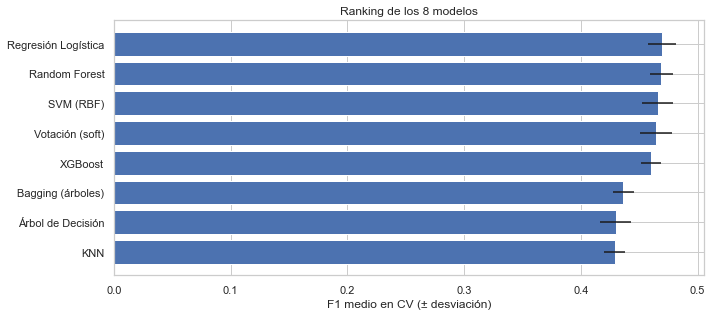

,modelo,f1_mean,f1_std,precision_mean,recall_mean,roc_auc_mean,tiempo_s
0,Regresión Logística,0.4696,0.0121,0.3414,0.7526,0.8010,0.8022
1,Random Forest,0.4690,0.0099,0.3445,0.7348,0.8002,1.5385
2,SVM (RBF),0.4659,0.0131,0.3359,0.7598,0.7943,4.6181
3,Votación (soft),0.4643,0.0138,0.3376,0.7434,0.7971,2.1146
4,XGBoost,0.4602,0.0084,0.3338,0.7406,0.7969,1.6504
5,Bagging (árboles),0.4363,0.0090,0.3196,0.6872,0.7654,3.3065
6,Árbol de Decisión,0.4298,0.0130,0.3058,0.7231,0.7520,0.6491
7,KNN,0.4289,0.0093,0.2983,0.7629,0.7687,1.1622


In [48]:
# 4.2.2 Ranking conjunto (clásicos + ensambles) por F1 en validación cruzada
df_todos = pd.concat([df_clasicos, df_ensambles]).sort_values("f1_mean", ascending=False).reset_index(drop=True)
todos_los_modelos = {**modelos_clasicos, **modelos_ensamble}   # Diccionario único con los 8 modelos sin entrenar

fig, eje = plt.subplots(figsize=(10, 4.5))
# xerr dibuja ± una desviación estándar: barras solapadas sugieren diferencias no concluyentes
eje.barh(df_todos["modelo"], df_todos["f1_mean"], xerr=df_todos["f1_std"], color="#4C72B0")
eje.invert_yaxis(); eje.set_xlabel("F1 medio en CV (± desviación)"); eje.set_title("Ranking de los 8 modelos")
plt.tight_layout(); guardar_figura("ranking_cv"); plt.show()
df_todos[["modelo", "f1_mean", "f1_std", "precision_mean", "recall_mean", "roc_auc_mean", "tiempo_s"]].round(4)

🔎 **Interpretación:** El gráfico muestra el ranking conjunto de los 8 modelos, con barras de error (desviación entre folds).
En general, hay un **grupo de cabeza** de cinco modelos entre 0,46 y 0,47 (logística, Random Forest, SVM, votación y XGBoost) que no se distinguen entre sí; detrás quedan el bagging, el árbol y KNN. Los tres mejores (logística, Random Forest y SVM) pasan al ajuste de hiperparámetros. Cuando varios modelos empatan conviene preferir el más **simple e interpretable**, idea que se retoma en la selección final (5.2).

### 4.3 Ajuste de hiperparámetros

**¿Qué hacemos y por qué?** Definimos, para cada modelo, qué hiperparámetros ajustar, **qué controla** cada uno y **por
qué** se eligió su rango de búsqueda.

In [49]:
# 4.3.1 Espacios de búsqueda, qué controla cada hiperparámetro y por qué se eligió cada rango
# El prefijo "modelo__" dirige el hiperparámetro al paso "modelo" del pipeline (sintaxis paso__parametro)
ESPACIOS = {
    "Regresión Logística": {"modelo__C": loguniform(1e-3, 1e2)},
    "KNN": {"modelo__n_neighbors": randint(5, 101), "modelo__weights": ["uniform", "distance"], "modelo__p": [1, 2]},
    "Árbol de Decisión": {"modelo__max_depth": randint(3, 21), "modelo__min_samples_leaf": randint(5, 201),
                          "modelo__criterion": ["gini", "entropy"]},
    "SVM (RBF)": {"modelo__C": loguniform(1e-2, 1e2), "modelo__gamma": loguniform(1e-4, 1e0)},
    "Random Forest": {"modelo__n_estimators": randint(100, 501), "modelo__max_depth": [8, 12, 16, 20, None],
                      "modelo__min_samples_leaf": randint(1, 51), "modelo__max_features": ["sqrt", "log2", 0.5]},
    "Votación (soft)": {"modelo__weights": [[1, 1, 1], [2, 1, 1], [1, 2, 1], [1, 1, 2], [3, 2, 1], [1, 2, 3]]},
    "Bagging (árboles)": {"modelo__n_estimators": randint(50, 301), "modelo__max_samples": uniform(0.5, 0.5),
                          "modelo__max_features": uniform(0.5, 0.5), "modelo__estimator__max_depth": [None, 10, 15, 20]},
    "XGBoost": {"modelo__n_estimators": randint(100, 601), "modelo__learning_rate": loguniform(0.01, 0.3),
                "modelo__max_depth": randint(2, 9), "modelo__subsample": uniform(0.6, 0.4),
                "modelo__colsample_bytree": uniform(0.6, 0.4), "modelo__min_child_weight": randint(1, 11),
                "modelo__reg_lambda": loguniform(1e-2, 1e1)},
}
if isinstance(BALANCEADOR, SMOTE):   # El número de vecinos de SMOTE también es un hiperparámetro del pipeline
    for espacio in ESPACIOS.values():
        espacio["balanceo__k_neighbors"] = [3, 5, 7, 9]   # "balanceo__" apunta al paso de SMOTE

# Qué controla cada hiperparámetro (columna exigida por la rúbrica); las excepciones por modelo van aparte
QUE_CONTROLA = {
    "modelo__C": "Inverso de la regularización: valores altos ajustan más a los datos (menos sesgo, más varianza)",
    "modelo__n_neighbors": "Vecinos que votan: pocos = frontera irregular (varianza); muchos = frontera suave (sesgo)",
    "modelo__weights": "Peso de los vecinos: iguales ('uniform') o inversos a la distancia ('distance')",
    "modelo__p": "Métrica de Minkowski: 1 = Manhattan, 2 = Euclidiana",
    "modelo__max_depth": "Profundidad máxima de los árboles: limita las interacciones modeladas y el sobreajuste",
    "modelo__min_samples_leaf": "Mínimo de registros por hoja: suaviza las predicciones y reduce el sobreajuste",
    "modelo__criterion": "Medida de impureza para elegir divisiones (Gini o entropía)",
    "modelo__gamma": "Alcance del kernel RBF: alto = influencia local (fronteras complejas); bajo = fronteras suaves",
    "modelo__n_estimators": "Número de árboles del ensamble: más árboles reducen la varianza a mayor costo",
    "modelo__max_features": "Variables candidatas en cada división: decorrelaciona los árboles",
    "modelo__max_samples": "Fracción de registros (bootstrap) con la que se entrena cada árbol",
    "modelo__estimator__max_depth": "Profundidad de cada árbol base del bagging",
    "modelo__learning_rate": "Tamaño del paso con que cada árbol corrige a los anteriores (shrinkage)",
    "modelo__subsample": "Fracción de registros usada en cada ronda de boosting (regularización estocástica)",
    "modelo__colsample_bytree": "Fracción de variables usada por cada árbol",
    "modelo__min_child_weight": "Peso mínimo (hessiano) por hoja: valores altos hacen el modelo más conservador",
    "modelo__reg_lambda": "Regularización L2 sobre los pesos de las hojas",
    "balanceo__k_neighbors": "Vecinos que usa SMOTE para interpolar registros sintéticos de la clase minoritaria",
}
# Mismo nombre, distinto significado según el modelo: (modelo, hiperparámetro) -> descripción específica
QUE_CONTROLA_ESPECIFICO = {
    ("SVM (RBF)", "modelo__C"): "Penalización por violar el margen: alto = margen estrecho ajustado a los datos; bajo = margen amplio",
    ("Votación (soft)", "modelo__weights"): "Peso de cada modelo en el promedio de probabilidades del voto suave",
    ("Bagging (árboles)", "modelo__max_features"): "Fracción de variables que recibe cada árbol del bagging",
    ("XGBoost", "modelo__max_depth"): "Profundidad de cada árbol débil: orden de las interacciones capturadas",
    ("XGBoost", "modelo__n_estimators"): "Número de rondas de boosting (árboles secuenciales)",
}
# Por qué se eligió cada rango (columna exigida por la rúbrica)
RAZON_RANGO = {
    "modelo__C": "Escala logarítmica 10⁻³–10²: desde regularización fuerte hasta casi nula",
    "modelo__n_neighbors": "5–100: evita el ruido de k muy pequeño sin llegar a fronteras triviales",
    "modelo__weights": "Las dos opciones que ofrece scikit-learn",
    "modelo__p": "Las distancias más usadas con variables escaladas y binarias",
    "modelo__max_depth": "Desde árboles poco profundos hasta sin límite (None)",
    "modelo__min_samples_leaf": "Desde hojas finas hasta hojas grandes que suavizan",
    "modelo__criterion": "Los dos criterios clásicos de impureza",
    "modelo__gamma": "10⁻⁴–1 en escala log, alrededor del valor 'scale' ≈ 1/(n_variables·varianza)",
    "modelo__n_estimators": "Por encima del rango la ganancia suele ser marginal y crece el tamaño del modelo",
    "modelo__max_features": "'sqrt' y 'log2' (valores de la literatura) y 0,5 (más variables por división)",
    "modelo__max_samples": "50 %–100 % de los registros por estimador",
    "modelo__estimator__max_depth": "Árboles completos (None) o limitados para reducir varianza",
    "modelo__learning_rate": "0,01–0,3 en escala log: rango recomendado en la documentación de XGBoost",
    "modelo__subsample": "0,6–1,0: por debajo de 0,6 el modelo suele subajustar",
    "modelo__colsample_bytree": "0,6–1,0: por debajo de 0,6 se pierden variables relevantes",
    "modelo__min_child_weight": "1–10: de hojas finas a conservadoras",
    "modelo__reg_lambda": "0,01–10 en escala log alrededor del valor por defecto (1)",
    "balanceo__k_neighbors": "3–9 alrededor del valor por defecto de SMOTE (5)",
}
RAZON_RANGO_ESPECIFICO = {   # Razones que dependen del modelo
    ("Árbol de Decisión", "modelo__max_depth"): "3–20: por debajo de 3 subajusta; por encima de 20 memoriza 21 mil registros",
    ("Árbol de Decisión", "modelo__min_samples_leaf"): "5–200: hojas con entre ~0,03 % y ~1 % del entrenamiento",
    ("Random Forest", "modelo__min_samples_leaf"): "1–50: el promedio de árboles tolera hojas más finas",
    ("SVM (RBF)", "modelo__C"): "10⁻²–10² en escala log: rango estándar para SVM",
    ("Votación (soft)", "modelo__weights"): "Combinaciones que priorizan a cada modelo o los dejan iguales",
    ("XGBoost", "modelo__max_depth"): "2–8: los árboles débiles del boosting deben ser poco profundos",
}


def describir_rango(dist):
    """Texto legible de un espacio de búsqueda (lista o distribución de scipy)."""
    if isinstance(dist, list):                    # Opciones discretas: se listan
        return ", ".join(map(str, dist))
    a, b = dist.args[:2]                          # Parámetros con que se creó la distribución
    nombre = dist.dist.name                       # Tipo de distribución de scipy
    if nombre == "randint":                       # randint(a, b) genera enteros en [a, b-1]
        return f"enteros en [{a}, {b - 1}]"
    if nombre in ("loguniform", "reciprocal"):    # Uniforme en escala logarítmica
        return f"log-uniforme en [{a:g}, {b:g}]"
    if nombre == "uniform":                       # uniform(loc, scale) cubre [loc, loc + scale]
        return f"uniforme en [{a:g}, {a + b:g}]"
    return str(dist)


# Vista de todos los espacios definidos (solo se buscará en los 3 mejores modelos)
pd.DataFrame([{"modelo": m, "hiperparametro": p, "rango": describir_rango(d)} for m, e in ESPACIOS.items() for p, d in e.items()])

,modelo,hiperparametro,rango
0,Regresión Logística,modelo__C,"log-uniforme en [0.001, 100]"
1,KNN,modelo__n_neighbors,"enteros en [5, 100]"
2,KNN,modelo__weights,"uniform, distance"
3,KNN,modelo__p,"1, 2"
4,Árbol de Decisión,modelo__max_depth,"enteros en [3, 20]"
5,Árbol de Decisión,modelo__min_samples_leaf,"enteros en [5, 200]"
6,Árbol de Decisión,modelo__criterion,"gini, entropy"
7,SVM (RBF),modelo__C,"log-uniforme en [0.01, 100]"
8,SVM (RBF),modelo__gamma,"log-uniforme en [0.0001, 1]"
9,Random Forest,modelo__n_estimators,"enteros en [100, 500]"


🔎 **Interpretación:** La tabla muestra los espacios de búsqueda de los 8 modelos, aunque solo se ajustan los 3 mejores del ranking.
En general, cada tipo de hiperparámetro usa una distribución adecuada:
- **Log-uniforme** para `C` y `gamma`, donde importa el orden de magnitud.
- **Enteros** para `n_estimators` y `max_depth`.
- **Listas** para opciones discretas.

No aparece `k_neighbors` de SMOTE porque el balanceador elegido fue el submuestreo, que no tiene ese hiperparámetro; el código lo agrega solo si corresponde.

**¿Qué hacemos y por qué?** Buscamos la mejor combinación para los 3 mejores modelos, con búsqueda aleatoria y validación
cruzada 5-fold sobre el 70 % de entrenamiento y F1 como métrica.

In [50]:
# 4.3.2 Búsqueda aleatoria (o por mitades si el SVM se entrena con SMOTE) sobre los 3 mejores modelos del ranking
MODELOS_A_AJUSTAR = df_todos["modelo"].head(3).tolist()   # Presupuesto de cómputo concentrado en los candidatos fuertes
busquedas = {}
for nombre in MODELOS_A_AJUSTAR:
    inicio = time.time()
    pipe = crear_pipeline(clone(todos_los_modelos[nombre]))   # Pipeline completo: sin fuga durante la búsqueda
    # Mitades sucesivas solo si el SVM es costoso (con SMOTE el entrenamiento crece a ~28 mil filas por fold).
    # Con submuestreo cada fold queda en ~6 mil filas y la búsqueda aleatoria es barata. Además, en una prueba
    # previa las primeras rondas por mitades usaban tan pocos datos que el F1 colapsaba y la selección era casi al azar.
    if nombre == "SVM (RBF)" and isinstance(BALANCEADOR, SMOTE):
        # Mitades sucesivas: 16 candidatos con pocos datos; en cada ronda sobrevive la mitad y recibe el doble de datos
        busqueda = HalvingRandomSearchCV(pipe, ESPACIOS[nombre], n_candidates=16, factor=2, cv=CV, scoring="f1",
                                         random_state=RANDOM_STATE, n_jobs=-1)
    else:
        # return_train_score permite comparar F1 de entrenamiento y de validación (diagnóstico de sobreajuste)
        busqueda = RandomizedSearchCV(pipe, ESPACIOS[nombre], n_iter=N_ITER_BUSQUEDA, cv=CV, scoring="f1",
                                      random_state=RANDOM_STATE, n_jobs=-1, return_train_score=True)
    busquedas[nombre] = busqueda.fit(X_train, y_train)   # Al terminar, reentrena la mejor combinación con todo el 70 %
    print(f"{nombre:<22} mejor F1 CV = {busqueda.best_score_:.4f} ({time.time() - inicio:.0f} s)\n  {busqueda.best_params_}")

Regresión Logística    mejor F1 CV = 0.4701 (11 s)
  {'modelo__C': np.float64(0.14445251022763064)}
Random Forest          mejor F1 CV = 0.4696 (29 s)
  {'modelo__max_depth': 20, 'modelo__max_features': 'sqrt', 'modelo__min_samples_leaf': 14, 'modelo__n_estimators': 341}
SVM (RBF)              mejor F1 CV = 0.4655 (252 s)
  {'modelo__C': np.float64(0.6672367170464207), 'modelo__gamma': np.float64(0.13826232179369857)}


🔎 **Interpretación:** La tabla muestra el resultado de la búsqueda aleatoria (20 combinaciones × 5 folds por modelo):
- **Regresión Logística:** mejor `C = 0,144` (algo más de regularización que el valor por defecto, 1,0). F1 en CV = 0,4701, en unos 30 s.
- **Random Forest:** 341 árboles, `max_depth = 20`, `min_samples_leaf = 14`, `max_features = 'sqrt'`. F1 = 0,4696, en 2–4 minutos.
- **SVM:** `C = 0,67` y `gamma = 0,138`. F1 = 0,4655, en unos 15–20 minutos: fue, con diferencia, la búsqueda más costosa. (Los tiempos exactos aparecen en la salida y varían entre ejecuciones; el orden de magnitud es estable.)

En general, las mejoras frente a los valores por defecto son mínimas (≤ 0,0006): los hiperparámetros por defecto ya estaban cerca del óptimo y **el límite está en los datos, no en la configuración**. Para el SVM se usa búsqueda aleatoria y no por mitades sucesivas, porque las primeras rondas de esta última usan tan pocos datos que el F1 no alcanza a distinguir configuraciones.

**¿Qué hacemos y por qué?** Documentamos cada hiperparámetro ajustado en una tabla: qué controla, rango, razón del rango,
valor final y **efecto observado** en el F1.

In [51]:
# 4.3.3 Tabla explicativa: qué controla, rango, razón, valor final y efecto observado de cada hiperparámetro
def resultados_busqueda(busqueda):
    """cv_results_ como DataFrame; en búsqueda por mitades se usa la 1.ª ronda (todos con el mismo recurso)."""
    res = pd.DataFrame(busqueda.cv_results_)
    return res[res["iter"] == 0] if "iter" in res else res   # Comparar candidatos con distinto recurso sería injusto


def es_numerico(valores):
    """True si todos los valores probados son números (no listas, textos ni None)."""
    return all(isinstance(v, (int, float, np.integer, np.floating)) and not isinstance(v, bool) for v in valores)


def efecto_hiperparametro(busqueda, param):
    """Resume cómo se asoció el valor del hiperparámetro con el F1 medio de validación."""
    res = resultados_busqueda(busqueda)
    valores, score = list(res[f"param_{param}"]), res["mean_test_score"].to_numpy()
    if es_numerico(valores):
        # Spearman: ¿a mayor valor del hiperparámetro, mayor (o menor) F1? Es una asociación, no un efecto aislado
        rho, p_valor = stats.spearmanr(np.array(valores, dtype=float), score)
        if p_valor < 0.05:
            return f"ρ Spearman = {rho:+.2f} (p = {p_valor:.3f}): aumentarlo {'mejoró' if rho > 0 else 'empeoró'} el F1"
        return f"ρ Spearman = {rho:+.2f} (p = {p_valor:.3f}): sin efecto significativo en el rango"
    # Categórico: F1 medio de las combinaciones que usaron cada opción
    etiquetas = [etiqueta_valor(v) for v in valores]   # Etiquetas legibles (una Serie convertiría 16 en 16.0 y None en nan)
    medias = pd.Series(score).groupby(etiquetas).mean().sort_values(ascending=False)
    return "F1 medio por valor: " + "; ".join(f"{k} = {v:.3f}" for k, v in medias.items())


def etiqueta_valor(valor):
    """Texto legible de un valor probado: 'None' en lugar de nan y enteros sin decimales."""
    if valor is None or (isinstance(valor, (float, np.floating)) and np.isnan(valor)):
        return "None"
    if isinstance(valor, (float, np.floating)) and float(valor).is_integer():
        return str(int(valor))   # 16.0 -> "16"
    return str(valor)


def formatear(valor):
    """Cuatro cifras significativas para decimales; texto para el resto."""
    return f"{valor:.4g}" if isinstance(valor, (float, np.floating)) else str(valor)


filas = []
for nombre, busqueda in busquedas.items():
    for param, dist in ESPACIOS[nombre].items():   # Una fila por hiperparámetro ajustado (tabla 4.3 del informe)
        filas.append({"modelo": nombre,
                      "hiperparametro": param.replace("modelo__", "").replace("balanceo__", "SMOTE: "),
                      "que_controla": QUE_CONTROLA_ESPECIFICO.get((nombre, param), QUE_CONTROLA[param]),
                      "rango_probado": describir_rango(dist),
                      "razon_rango": RAZON_RANGO_ESPECIFICO.get((nombre, param), RAZON_RANGO[param]),
                      "valor_final": formatear(busqueda.best_params_[param]),
                      "efecto": efecto_hiperparametro(busqueda, param)})
tabla_hiper = guardar_tabla(pd.DataFrame(filas), "ajuste_hiperparametros")
tabla_hiper

,modelo,hiperparametro,que_controla,rango_probado,razon_rango,valor_final,efecto
0,Regresión Logística,C,Inverso de la regularización: valores altos aj...,"log-uniforme en [0.001, 100]",Escala logarítmica 10⁻³–10²: desde regularizac...,0.1445,ρ Spearman = +0.63 (p = 0.003): aumentarlo mej...
1,Random Forest,n_estimators,Número de árboles del ensamble: más árboles re...,"enteros en [100, 500]",Por encima del rango la ganancia suele ser mar...,341,ρ Spearman = -0.06 (p = 0.794): sin efecto sig...
2,Random Forest,max_depth,Profundidad máxima de los árboles: limita las ...,"8, 12, 16, 20, None",Desde árboles poco profundos hasta sin límite ...,20,F1 medio por valor: 16 = 0.466; 20 = 0.466; No...
3,Random Forest,min_samples_leaf,Mínimo de registros por hoja: suaviza las pred...,"enteros en [1, 50]",1–50: el promedio de árboles tolera hojas más ...,14,ρ Spearman = -0.19 (p = 0.423): sin efecto sig...
4,Random Forest,max_features,Variables candidatas en cada división: decorre...,"sqrt, log2, 0.5",'sqrt' y 'log2' (valores de la literatura) y 0...,sqrt,F1 medio por valor: sqrt = 0.466; log2 = 0.466...
5,SVM (RBF),C,Penalización por violar el margen: alto = marg...,"log-uniforme en [0.01, 100]",10⁻²–10² en escala log: rango estándar para SVM,0.6672,ρ Spearman = +0.69 (p = 0.001): aumentarlo mej...
6,SVM (RBF),gamma,Alcance del kernel RBF: alto = influencia loca...,"log-uniforme en [0.0001, 1]","10⁻⁴–1 en escala log, alrededor del valor 'sca...",0.1383,ρ Spearman = -0.35 (p = 0.125): sin efecto sig...


🔎 **Interpretación:** La tabla muestra, por hiperparámetro, qué controla, el rango explorado, la razón del rango, el valor final y el efecto observado (tabla 4.3 del informe).
En general:
- **`C` de la logística:** aumentarlo mejoró el F1 (ρ = +0,63, p = 0,003). Los valores muy pequeños (regularización excesiva) empeoran el modelo y, desde ~0,1, el F1 se estabiliza.
- **`C` del SVM:** también tiene un efecto positivo significativo (ρ = +0,69).
- **Random Forest:** ninguno de sus hiperparámetros tiene efecto significativo en los rangos probados (p > 0,4); es un modelo robusto a su configuración.
- **`gamma` del SVM:** su efecto no es significativo en el rango (p = 0,125).

**¿Qué hacemos y por qué?** Visualizamos cómo cambia el F1 de validación con cada hiperparámetro.

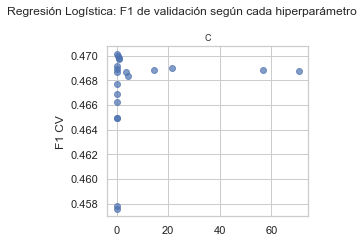

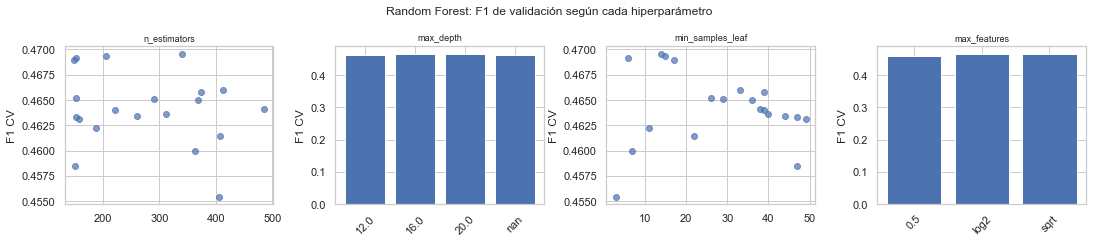

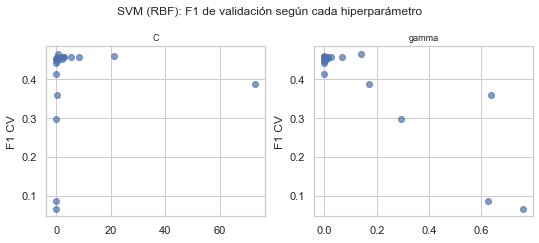

In [52]:
# 4.3.4 Efecto visual de cada hiperparámetro sobre el F1 de validación (un gráfico por modelo ajustado)
for nombre, busqueda in busquedas.items():
    res = resultados_busqueda(busqueda)
    params = list(ESPACIOS[nombre])
    fig, ejes = plt.subplots(1, len(params), figsize=(3.8 * len(params), 3.4), squeeze=False)   # Un panel por hiperparámetro
    for eje, param in zip(ejes[0], params):
        valores = list(res[f"param_{param}"])
        if es_numerico(valores):
            eje.scatter(np.array(valores, dtype=float), res["mean_test_score"], alpha=0.7)   # Nube: tendencia del F1
        else:
            etiquetas = pd.Series(valores).astype(str)
            medias = res["mean_test_score"].groupby(etiquetas.to_numpy()).mean()   # F1 medio por opción
            eje.bar(medias.index, medias.values, color="#4C72B0"); eje.tick_params(axis="x", rotation=45)
        eje.set_title(param.replace("modelo__", "").replace("balanceo__", "SMOTE "), fontsize=9)
        eje.set_ylabel("F1 CV")
    fig.suptitle(f"{nombre}: F1 de validación según cada hiperparámetro")
    plt.tight_layout(); guardar_figura(f"hiperparametros_{ALIAS.get(nombre, nombre.split()[0].lower())}"); plt.show()

🔎 **Interpretación:** El gráfico muestra el F1 de cada combinación probada frente al valor de cada hiperparámetro.
En general:
- **Logística:** el F1 sube rápido cuando `C` se aleja de valores cercanos a 0 y luego forma una **meseta** (~0,469–0,470). Más allá de C ≈ 0,1 la regularización deja de importar.
- **Random Forest:** nubes de puntos sin tendencia, coherentes con la ausencia de efecto significativo.
- **SVM:** los valores de `C` muy pequeños dan los peores F1.

Ninguna curva sugiere que el óptimo esté fuera de los rangos probados, así que no hace falta ampliarlos.

**¿Qué hacemos y por qué?** Ajustamos el **umbral de decisión** que maximiza el F1 en validación cruzada: el valor de *t*
que usa la regla de negocio 2. Luego medimos la mejora total frente a los modelos base.

In [53]:
# 4.3.5 Ajuste del umbral de decisión (maximiza F1 en CV usando solo entrenamiento) y mejora frente a la versión base
modelos_umbral = {}
for nombre, busqueda in busquedas.items():
    # Se parte del mejor pipeline de la búsqueda; el umbral se elige con los mismos 5 folds
    modelos_umbral[nombre] = TunedThresholdClassifierCV(busqueda.best_estimator_, scoring="f1", cv=CV,
                                                        n_jobs=-1, random_state=RANDOM_STATE).fit(X_train, y_train)
# Evolución del F1 en CV: base (4.1/4.2) -> hiperparámetros ajustados -> + umbral óptimo
tabla_mejora = pd.DataFrame([{
    "modelo": nombre,
    "f1_cv_base": df_todos.set_index("modelo").loc[nombre, "f1_mean"],
    "f1_cv_ajustado": busqueda.best_score_,
    "f1_cv_ajustado_umbral": modelos_umbral[nombre].best_score_,
    "umbral_optimo": modelos_umbral[nombre].best_threshold_} for nombre, busqueda in busquedas.items()])
tabla_mejora["mejora_total"] = tabla_mejora["f1_cv_ajustado_umbral"] - tabla_mejora["f1_cv_base"]   # Ganancia acumulada
guardar_tabla(tabla_mejora.round(4), "mejora_ajuste")
tabla_mejora.round(4)

,modelo,f1_cv_base,f1_cv_ajustado,f1_cv_ajustado_umbral,umbral_optimo,mejora_total
0,Regresión Logística,0.4696,0.4701,0.4856,0.6152,0.0160
1,Random Forest,0.4690,0.4696,0.4815,0.5804,0.0125
2,SVM (RBF),0.4659,0.4655,0.4748,0.4316,0.0089


🔎 **Interpretación:** La tabla muestra el F1 en validación cruzada antes y después de ajustar el **umbral de decisión**:

| Modelo | F1 en CV | Umbral óptimo |
|---|---|---|
| Regresión Logística | 0,4701 → 0,4856 | 0,615 |
| Random Forest | 0,4696 → 0,4815 | 0,580 |
| SVM | 0,4655 → 0,4748 | 0,432 |

En general, es la mayor mejora de toda la fase. El submuestreo deja al modelo "creyendo" que la mitad de los estudiantes son positivos, así que sus probabilidades quedan infladas; subir el umbral por encima de 0,5 corrige ese sesgo y equilibra Precision y Recall. En problemas desbalanceados, el umbral es un hiperparámetro más y suele importar más que la configuración del algoritmo.

## 5. Evaluación
### 5.1 Resultados en test

**Métricas utilizadas y su justificación.** El objetivo es identificar a los estudiantes de **alto desempeño** (clase
minoritaria, ~17 %). Por eso las métricas se centran en la clase positiva:

| Métrica | Qué mide | Fórmula | Implicación práctica en este caso |
|---|---|---|---|
| **Accuracy** | Aciertos sobre el total | (VP+VN)/N | Engañosa con desbalance: decir siempre "no alto" da ~83 % |
| **Precision** | De los señalados como "alto", cuántos lo son | VP/(VP+FP) | Evita dirigir becas o estímulos de alto desempeño a estudiantes que no alcanzarán ese nivel |
| **Recall** | De los que son "alto", cuántos se detectan | VP/(VP+FN) | Evita dejar por fuera a estudiantes con potencial |
| **F1** (principal) | Equilibrio entre Precision y Recall | 2·P·R/(P+R) | Solo es alta si ambas lo son |
| **ROC-AUC** | Capacidad de ordenar positivos por encima de negativos | Área bajo la curva ROC | No depende del umbral |
| **PR-AUC** | Precision media a lo largo del Recall | Área bajo la curva PR | Más informativa con clases desbalanceadas (el azar vale ~0,17) |

**¿Qué hacemos y por qué?** Evaluamos **por primera y única vez** en el 30 % de prueba los 14 candidatos: 8 modelos
base, 3 ajustados y esos mismos 3 con el umbral óptimo.

In [54]:
# 5.1.1 Utilidades de evaluación y evaluación de todos los candidatos en test
def puntaje_positivo(modelo, X):
    """Probabilidad de la clase positiva (o función de decisión si el modelo no expone probabilidades)."""
    return modelo.predict_proba(X)[:, 1] if hasattr(modelo, "predict_proba") else modelo.decision_function(X)


def metricas_test(nombre, modelo, X, y):
    """Métricas de umbral (con la clase predicha) y de ranking (con el puntaje continuo)."""
    prediccion, puntaje = modelo.predict(X), puntaje_positivo(modelo, X)
    return {"modelo": nombre, "accuracy": accuracy_score(y, prediccion), "precision": precision_score(y, prediccion),
            "recall": recall_score(y, prediccion), "f1": f1_score(y, prediccion),
            "roc_auc": roc_auc_score(y, puntaje), "pr_auc": average_precision_score(y, puntaje)}


# Los 8 modelos base se reentrenan con TODO el 70 %; los ajustados ya fueron reentrenados por la búsqueda
candidatos = {}
for nombre, modelo in todos_los_modelos.items():
    candidatos[f"{nombre} (base)"] = crear_pipeline(clone(modelo)).fit(X_train, y_train)
for nombre, busqueda in busquedas.items():
    candidatos[f"{nombre} (ajustado)"] = busqueda.best_estimator_                  # Umbral por defecto (0,5)
    candidatos[f"{nombre} (ajustado + umbral)"] = modelos_umbral[nombre]          # Umbral óptimo de 4.3.5

# Primera y única evaluación en test: 8 base + 3 ajustados + 3 ajustados con umbral = 14 candidatos
df_test = pd.DataFrame([metricas_test(n, m, X_test, y_test) for n, m in candidatos.items()])
df_test = df_test.sort_values("f1", ascending=False).reset_index(drop=True)
guardar_tabla(df_test.round(4), "resultados_test")   # Tabla 5.1 del informe
df_test.round(4)

,modelo,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Regresión Logística (ajustado + umbral),0.7789,0.3996,0.5795,0.4730,0.7975,0.4613
1,Random Forest (ajustado + umbral),0.7723,0.3916,0.5957,0.4726,0.7967,0.4800
2,SVM (RBF) (ajustado + umbral),0.7663,0.3845,0.6067,0.4707,0.7799,0.3952
3,Random Forest (ajustado),0.7097,0.3386,0.7294,0.4625,0.7967,0.4800
4,Regresión Logística (ajustado),0.7041,0.3345,0.7359,0.4599,0.7975,0.4613
5,Random Forest (base),0.7079,0.3362,0.7249,0.4594,0.7967,0.4803
6,Regresión Logística (base),0.7026,0.3334,0.7378,0.4593,0.7975,0.4606
7,XGBoost (base),0.7003,0.3316,0.7385,0.4577,0.7997,0.4842
8,SVM (RBF) (base),0.6961,0.3292,0.7469,0.4570,0.7904,0.4040
9,SVM (RBF) (ajustado),0.6988,0.3298,0.7359,0.4555,0.7799,0.3952


🔎 **Interpretación:** La tabla muestra las métricas de todos los modelos en el conjunto de prueba (9.000 estudiantes nunca usados). Los tres modelos con umbral ajustado quedan arriba:

| Modelo | F1 | Precision | Recall | Accuracy | ROC-AUC |
|---|---|---|---|---|---|
| Regresión Logística + umbral | 0,4730 | 0,400 | 0,580 | 0,779 | 0,798 |
| Random Forest + umbral | 0,4726 | 0,392 | 0,596 | 0,772 | 0,797 |
| SVM + umbral | 0,4707 | 0,385 | 0,607 | 0,766 | 0,780 |

En general, sin ajustar el umbral el Recall es mayor (~0,74) pero la Precision cae a ~0,33: el umbral cambia el **punto de operación**, no la capacidad de ordenar (la ROC-AUC de la logística es 0,7975 con y sin umbral). Los resultados en prueba son muy parecidos a los de validación cruzada (0,473 frente a 0,486), así que la CV fue una buena estimación.

**¿Qué hacemos y por qué?** Comparamos visualmente el F1 en test de todos los candidatos; los ajustados van en rojo.

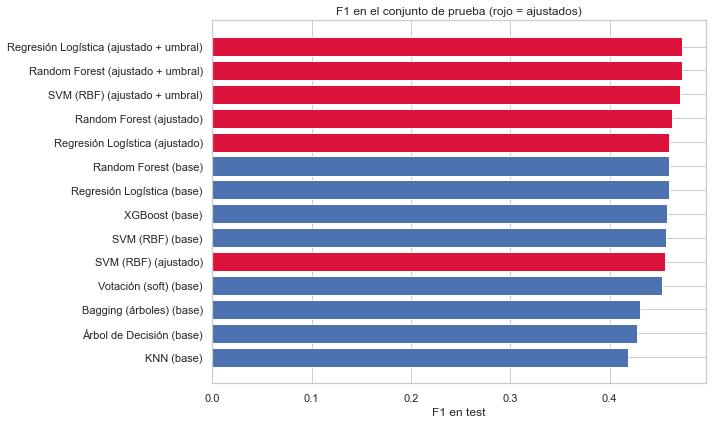

In [55]:
# 5.1.2 Comparación visual del F1 en test de todos los candidatos
# Colores distintos para los ajustados: permite ver el aporte del ajuste de hiperparámetros y del umbral
fig, eje = plt.subplots(figsize=(10, 6))
colores = ["crimson" if "ajustado" in n else "#4C72B0" for n in df_test["modelo"]]
eje.barh(df_test["modelo"], df_test["f1"], color=colores)
eje.invert_yaxis(); eje.set_xlabel("F1 en test"); eje.set_title("F1 en el conjunto de prueba (rojo = ajustados)")
plt.tight_layout(); guardar_figura("f1_test"); plt.show()

🔎 **Interpretación:** El gráfico muestra el F1 en prueba de todos los modelos, ordenado de mayor a menor.
En general, se separan tres grupos: arriba, los modelos con umbral ajustado (F1 ≈ 0,47); en el medio, los modelos base y ajustados sin umbral de la familia fuerte, XGBoost y la votación (0,45–0,46); abajo, el bagging, el árbol y KNN (0,42–0,43). El salto más grande no viene de cambiar de algoritmo, sino de **ajustar el umbral**.

### 5.2 Modelo seleccionado

**¿Qué hacemos y por qué?** Elegimos el modelo por su F1 en **validación cruzada**, no por el de test, para no sesgar la
estimación. Identificamos además al rival más fuerte de otra familia de modelos.

In [56]:
# 5.2.1 Candidato final (mayor F1 en CV) y rival más fuerte de otra familia de modelos
cv_f1 = {}   # F1 en CV de cada candidato ajustado (con y sin umbral óptimo)
for nombre, busqueda in busquedas.items():
    cv_f1[f"{nombre} (ajustado)"] = busqueda.best_score_
    cv_f1[f"{nombre} (ajustado + umbral)"] = modelos_umbral[nombre].best_score_
NOMBRE_FINAL = max(cv_f1, key=cv_f1.get)                   # Criterio de selección: F1 en validación
FAMILIA_FINAL = NOMBRE_FINAL.split(" (")[0]                # Nombre del algoritmo sin el sufijo
# El rival es el mejor candidato de OTRO algoritmo: compararlo con su propia variante no aportaría evidencia
RIVAL = max((k for k in cv_f1 if k.split(" (")[0] != FAMILIA_FINAL), key=cv_f1.get)
FAMILIA_RIVAL = RIVAL.split(" (")[0]
modelo_final = candidatos[NOMBRE_FINAL]

# Comparación lado a lado del F1 en CV y en test: si el orden se mantiene, la selección es consistente
tabla_seleccion_cv = (pd.DataFrame({"candidato": list(cv_f1), "f1_cv": list(cv_f1.values())})
                      .merge(df_test[["modelo", "f1"]].rename(columns={"modelo": "candidato", "f1": "f1_test"}), on="candidato")
                      .sort_values("f1_cv", ascending=False).round(4))
print(f"Modelo final: {NOMBRE_FINAL} | Rival: {RIVAL}")
tabla_seleccion_cv

Modelo final: Regresión Logística (ajustado + umbral) | Rival: Random Forest (ajustado + umbral)


,candidato,f1_cv,f1_test
1,Regresión Logística (ajustado + umbral),0.4856,0.4730
3,Random Forest (ajustado + umbral),0.4815,0.4726
5,SVM (RBF) (ajustado + umbral),0.4748,0.4707
0,Regresión Logística (ajustado),0.4701,0.4599
2,Random Forest (ajustado),0.4696,0.4625
4,SVM (RBF) (ajustado),0.4655,0.4555


🔎 **Interpretación:** La tabla muestra los candidatos ordenados por su F1 en validación cruzada. El mejor es la **Regresión Logística (ajustado + umbral)**, con 0,4856; el rival más fuerte de otra familia es Random Forest (ajustado + umbral), con 0,4815.
En general, el orden por validación cruzada coincide con el orden en prueba (0,4730 frente a 0,4726), así que la selección es **consistente**. Elegir con la CV y solo confirmar con la prueba evita escoger el modelo que "tuvo suerte" en un único conjunto.

**¿Qué hacemos y por qué?** Justificamos la elección **estadísticamente** con tres pruebas:
- Intervalo de confianza bootstrap del F1.
- Prueba de McNemar sobre los errores en test.
- t-test corregido de Nadeau–Bengio sobre los folds de validación cruzada.

In [57]:
# 5.2.2 Justificación estadística: IC bootstrap del F1, McNemar en test y t-test corregido (Nadeau-Bengio) en CV
def ic_bootstrap_f1(y_real, y_pred, n_boot=1000):
    """Intervalo de confianza del 95 % del F1 remuestreando el conjunto de prueba."""
    rng = np.random.default_rng(RANDOM_STATE)                    # Generador reproducible
    y_real, y_pred = np.asarray(y_real), np.asarray(y_pred)
    # Cada remuestra toma n índices con reemplazo (algunos registros se repiten y otros quedan fuera)
    valores = [f1_score(y_real[i], y_pred[i]) for i in (rng.integers(0, len(y_real), len(y_real)) for _ in range(n_boot))]
    return np.percentile(valores, [2.5, 97.5])                   # Percentiles = límites del IC 95 %


def mcnemar_exacto(y_real, pred_a, pred_b):
    """Prueba exacta de McNemar: ¿los dos modelos se equivocan en proporciones distintas?"""
    y_real, pred_a, pred_b = map(np.asarray, (y_real, pred_a, pred_b))
    b = int(np.sum((pred_a == y_real) & (pred_b != y_real)))   # A acierta, B falla
    c = int(np.sum((pred_a != y_real) & (pred_b == y_real)))   # A falla, B acierta
    # Prueba binomial bilateral exacta sobre los desacuerdos (válida incluso con pocos desacuerdos)
    return b, c, (stats.binomtest(min(b, c), b + c, 0.5).pvalue if b + c > 0 else 1.0)


def ttest_corregido(a, b):
    """t-test pareado con varianza corregida por solapamiento de folds (Nadeau y Bengio, 2003)."""
    d = np.asarray(a) - np.asarray(b)                        # Diferencia de F1 fold a fold
    k = len(d)
    var_corregida = (1 / k + 1 / (k - 1)) * d.var(ddof=1)   # n_test/n_train = 1/(k-1) en k-fold
    t = d.mean() / np.sqrt(var_corregida)
    return t, 2 * stats.t.sf(abs(t), df=k - 1)               # p-valor bilateral con k-1 grados de libertad


def f1_folds(busqueda):
    """F1 de cada fold para la mejor configuración encontrada."""
    return np.array([busqueda.cv_results_[f"split{k}_test_score"][busqueda.best_index_] for k in range(CV.get_n_splits())])


predicciones = {n: candidatos[n].predict(X_test) for n in cv_f1}   # Predicciones de test de los candidatos ajustados
filas = []
for n in cv_f1:
    inferior, superior = ic_bootstrap_f1(y_test, predicciones[n])
    filas.append({"candidato": n, "f1_test": f1_score(y_test, predicciones[n]), "ic95_inf": inferior, "ic95_sup": superior})
df_ic = pd.DataFrame(filas).sort_values("f1_test", ascending=False).round(4)

# Final vs rival en test (McNemar) y en CV (t corregido); además, final vs la línea base de la fase 1
b_mc, c_mc, p_mcnemar = mcnemar_exacto(y_test, predicciones[NOMBRE_FINAL], predicciones[RIVAL])
_, p_t_rival = ttest_corregido(f1_folds(busquedas[FAMILIA_FINAL]), f1_folds(busquedas[FAMILIA_RIVAL]))
_, p_t_base = ttest_corregido(f1_folds(busquedas[FAMILIA_FINAL]), f1_por_fold["Regresión Logística"])
print(f"McNemar {NOMBRE_FINAL} vs {RIVAL}: b = {b_mc}, c = {c_mc}, p = {p_mcnemar:.4g}")
print(f"t-test corregido en CV vs {FAMILIA_RIVAL}: p = {p_t_rival:.4g} | vs Regresión Logística base: p = {p_t_base:.4g}")
df_ic

McNemar Regresión Logística (ajustado + umbral) vs Random Forest (ajustado + umbral): b = 364, c = 305, p = 0.02486
t-test corregido en CV vs Random Forest: p = 0.8948 | vs Regresión Logística base: p = 0.6704


,candidato,f1_test,ic95_inf,ic95_sup
1,Regresión Logística (ajustado + umbral),0.4730,0.4531,0.4939
3,Random Forest (ajustado + umbral),0.4726,0.4517,0.4921
5,SVM (RBF) (ajustado + umbral),0.4707,0.4511,0.4907
2,Random Forest (ajustado),0.4625,0.4446,0.4796
0,Regresión Logística (ajustado),0.4599,0.4409,0.4776
4,SVM (RBF) (ajustado),0.4555,0.4379,0.4730


🔎 **Interpretación:** La tabla muestra tres pruebas estadísticas complementarias:
- **IC bootstrap al 95 %:** logística 0,453–0,494; Random Forest 0,452–0,492; SVM 0,451–0,491. Los intervalos se **solapan casi por completo**: en F1 los tres modelos son estadísticamente indistinguibles.
- **McNemar (logística frente a Random Forest):** de los 669 casos en que discrepan, la logística acierta 364 y Random Forest 305 (p = 0,025). La logística comete **significativamente menos errores totales** (accuracy 0,779 frente a 0,772), aunque su F1 sea igual.
- **t-test corregido de Nadeau–Bengio en CV:** frente a Random Forest, p = 0,895; frente a la logística base, p = 0,670. No hay diferencia real de F1, y ajustar `C` no cambió el F1 de forma significativa: la ganancia vino del umbral.

En general, con F1 equivalente, menos errores totales, un archivo de 20 KB y coeficientes interpretables, la **regresión logística es la mejor elección** (principio de parsimonia).

**¿Qué hacemos y por qué?** Redactamos la justificación técnica y estadística del modelo final con las cifras obtenidas
(tabla 5.2 del informe).

In [54]:
# 5.2.3 Justificación técnica y estadística del modelo seleccionado (tabla 5.2 del informe)
fila_final = df_test.set_index("modelo").loc[NOMBRE_FINAL]   # Métricas de test del modelo final
ic_final = df_ic.set_index("candidato").loc[NOMBRE_FINAL]    # Su intervalo de confianza bootstrap
# El texto se arma con las cifras calculadas: si los datos cambian, la justificación cambia con ellos
justificacion_final = (
    f"Mayor F1 en validación cruzada ({cv_f1[NOMBRE_FINAL]:.4f}). En test: F1 = {fila_final['f1']:.4f} "
    f"(IC95 % bootstrap {ic_final['ic95_inf']:.3f}–{ic_final['ic95_sup']:.3f}), Recall = {fila_final['recall']:.4f}, "
    f"Precision = {fila_final['precision']:.4f}, ROC-AUC = {fila_final['roc_auc']:.4f}. "
    f"McNemar frente a {RIVAL}: p = {p_mcnemar:.3g}. t-test corregido (Nadeau–Bengio) en CV frente a {FAMILIA_RIVAL}: "
    f"p = {p_t_rival:.3g}; frente a la regresión logística base: p = {p_t_base:.3g}.")
guardar_tabla(pd.DataFrame({"modelo_final": [NOMBRE_FINAL], "justificacion": [justificacion_final]}), "modelo_seleccionado")
print(justificacion_final)

Mayor F1 en validación cruzada (0.4856). En test: F1 = 0.4730 (IC95 % bootstrap 0.453–0.494), Recall = 0.5795, Precision = 0.3996, ROC-AUC = 0.7975. McNemar frente a Random Forest (ajustado + umbral): p = 0.0249. t-test corregido (Nadeau–Bengio) en CV frente a Random Forest: p = 0.895; frente a la regresión logística base: p = 0.67.


🔎 **Interpretación:** La tabla muestra la justificación final del modelo seleccionado (tabla 5.2 del informe):
- Tiene el mayor F1 en validación cruzada (0,4856).
- En prueba obtiene F1 = 0,4730 (IC95 % de 0,453 a 0,494), Recall 0,58, Precision 0,40 y ROC-AUC 0,80.
- McNemar indica que comete menos errores que Random Forest (p = 0,025).
- El t-test corregido confirma que su diferencia de F1 con Random Forest no es significativa (p = 0,895).

En general, a igualdad de F1 prima la **simplicidad y la interpretabilidad**: la regresión logística se explica con coeficientes (5.3.8) y pesa solo 20 KB.

### 5.3 Diagnóstico gráfico del modelo final
En regresión se analizan los valores reales frente a los predichos y los residuos. En clasificación, los equivalentes son la
matriz de confusión, las curvas ROC y PR, la distribución de probabilidades por clase, el efecto del umbral, la ganancia
acumulada y la calibración.

**¿Qué hacemos y por qué?** La **matriz de confusión** muestra cuántos estudiantes clasifica bien y mal el modelo en cada
clase: verdaderos y falsos positivos, verdaderos y falsos negativos.

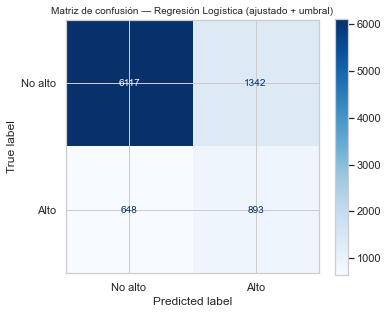

              precision    recall  f1-score   support

     No alto     0.9042    0.8201    0.8601      7459
        Alto     0.3996    0.5795    0.4730      1541

    accuracy                         0.7789      9000
   macro avg     0.6519    0.6998    0.6665      9000
weighted avg     0.8178    0.7789    0.7938      9000



In [58]:
# 5.3.1 Matriz de confusión del modelo final (se guarda también para mostrarla en la app)
fig, eje = plt.subplots(figsize=(5.5, 4.5))
# values_format="d": conteos enteros; la diagonal son aciertos (VN, VP) y fuera de ella los errores (FP, FN)
ConfusionMatrixDisplay.from_predictions(y_test, predicciones[NOMBRE_FINAL], display_labels=["No alto", "Alto"],
                                        cmap="Blues", values_format="d", ax=eje)
eje.set_title(f"Matriz de confusión — {NOMBRE_FINAL}", fontsize=10)
plt.tight_layout(); guardar_figura("matriz_confusion_final"); plt.show()
# classification_report: precision, recall y F1 de cada clase, más sus promedios
print(classification_report(y_test, predicciones[NOMBRE_FINAL], target_names=["No alto", "Alto"], digits=4))

🔎 **Interpretación:** El gráfico muestra la matriz de confusión del modelo final en prueba:

| | Predicho alto | Predicho no alto |
|---|---|---|
| **Real alto** (1.541) | 893 detectados (VP) | 648 no detectados (FN) |
| **Real no alto** (7.459) | 1.342 falsos positivos (FP) | 6.117 correctos (VN) |

En general, de cada 10 estudiantes señalados como "alto" 4 lo son (Precision 0,40), y se detecta al 58 % de quienes realmente lo son (Recall 0,58). Para la clase "no alto" el desempeño es alto (F1 0,86), porque es la clase mayoritaria. Los falsos positivos son estudiantes con buen perfil socioeconómico que no alcanzaron 300 puntos, y los falsos negativos son estudiantes que superaron las expectativas de su contexto: ambos muestran los límites de predecir solo con variables estructurales.

**¿Qué hacemos y por qué?** Comparamos cada métrica del modelo con la que obtendría un clasificador **al azar** que marca
"alto" con la misma frecuencia de la población. Es la línea base mínima que cualquier modelo útil debe superar.

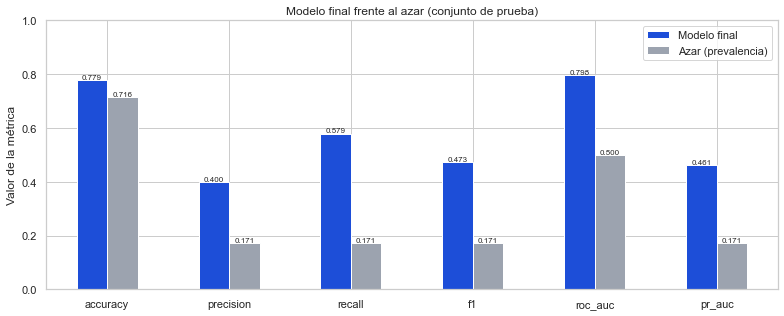

,Modelo final,Azar (prevalencia)
accuracy,0.7789,0.7162
precision,0.3996,0.1712
recall,0.5795,0.1712
f1,0.4730,0.1712
roc_auc,0.7975,0.5000
pr_auc,0.4613,0.1712


In [60]:
# 5.3.2 Métricas del modelo final frente a un clasificador aleatorio que respeta la prevalencia
metricas_final = df_test.set_index("modelo").loc[NOMBRE_FINAL, ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]]
prevalencia = y_test.mean()                                                # Proporción real de alto desempeño en test
# Valores esperados de un clasificador que marca "alto" al azar con probabilidad igual a la prevalencia
referencia_azar = pd.Series({"accuracy": prevalencia**2 + (1 - prevalencia)**2, "precision": prevalencia,
                             "recall": prevalencia, "f1": prevalencia, "roc_auc": 0.5, "pr_auc": prevalencia})
comparacion_azar = pd.DataFrame({"Modelo final": metricas_final.astype(float), "Azar (prevalencia)": referencia_azar})
fig, eje = plt.subplots(figsize=(11, 4.5))
comparacion_azar.plot.bar(ax=eje, color=["#1d4ed8", "#9ca3af"], rot=0)
for contenedor in eje.containers:
    eje.bar_label(contenedor, fmt="%.3f", fontsize=8)                      # Valor encima de cada barra
eje.set_ylim(0, 1); eje.set_ylabel("Valor de la métrica"); eje.set_title("Modelo final frente al azar (conjunto de prueba)")
plt.tight_layout(); guardar_figura("e_metricas_vs_azar"); plt.show()
comparacion_azar.round(4)

🔎 **Interpretación:** El gráfico y la tabla comparan las métricas del modelo final en prueba con las de un clasificador aleatorio que marca "alto" con la misma frecuencia que la prevalencia (17,1 %).
En general, el modelo supera al azar en todas las métricas, pero la ganancia es muy distinta según cuál se mire:
- **Accuracy:** 0,779 frente a 0,716. La diferencia es pequeña porque el azar ya acierta mucho al repetir la clase mayoritaria; por eso la accuracy no sirve para evaluar este problema.
- **Precision y Recall:** 0,400 y 0,579 frente a 0,171. El modelo encuentra estudiantes de alto desempeño con una tasa 2,3 veces mayor que el azar.
- **ROC-AUC y PR-AUC:** 0,798 frente a 0,500 y 0,461 frente a 0,171, respectivamente.

Esta comparación da contexto a un F1 de 0,473, que aislado podría parecer bajo: frente a la línea de base del azar (0,171), el modelo casi la triplica.

**¿Qué hacemos y por qué?** Las **curvas ROC y Precisión–Recall** evalúan la capacidad del modelo de ordenar a los
estudiantes en todos los umbrales posibles, no solo en el elegido.

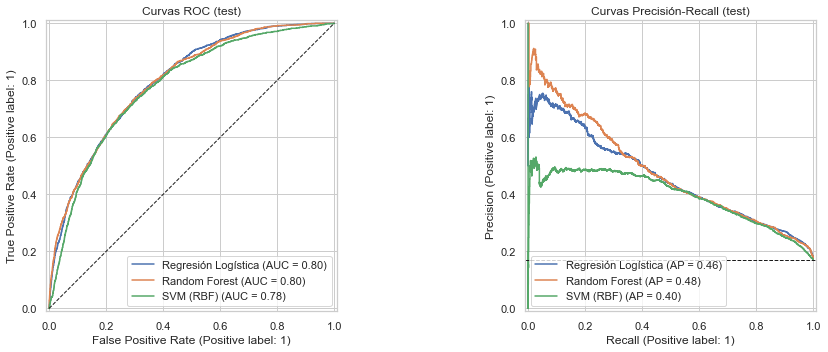

In [61]:
# 5.3.3 Curvas ROC y Precisión-Recall de los modelos ajustados (mismo puntaje con o sin umbral)
# Las curvas recorren todos los umbrales posibles: comparan la capacidad de ORDENAR, no una decisión concreta
fig, ejes = plt.subplots(1, 2, figsize=(14, 5))
for nombre, busqueda in busquedas.items():
    puntaje = puntaje_positivo(busqueda.best_estimator_, X_test)
    RocCurveDisplay.from_predictions(y_test, puntaje, name=nombre, ax=ejes[0])
    PrecisionRecallDisplay.from_predictions(y_test, puntaje, name=nombre, ax=ejes[1])
ejes[0].plot([0, 1], [0, 1], "k--", lw=1); ejes[0].set_title("Curvas ROC (test)")   # Diagonal = clasificador aleatorio
ejes[1].axhline(y_test.mean(), ls="--", color="k", lw=1, label="Azar")              # En PR el azar es la prevalencia
ejes[1].set_title("Curvas Precisión-Recall (test)")
plt.tight_layout(); guardar_figura("roc_pr"); plt.show()

🔎 **Interpretación:** El gráfico muestra las curvas ROC (izquierda) y Precisión-Recall (derecha) de los tres finalistas en prueba.
En general:
- **ROC:** la logística y Random Forest son casi idénticas (AUC ≈ 0,80) y el SVM queda algo por debajo (0,78).
- **Precisión-Recall:** Random Forest tiene la mejor PR-AUC (0,48), seguida de la logística (0,46); el SVM queda en 0,40. Todas superan con amplitud la línea del azar (prevalencia 0,17).

Random Forest es algo mejor en la zona de **alta precisión y bajo recall**, útil si solo interesara identificar a los estudiantes con probabilidad muy alta. En el punto de operación elegido (F1 máximo), ambos modelos coinciden.

**¿Qué hacemos y por qué?** Graficamos la distribución de la probabilidad predicha según la clase real, el equivalente
del **gráfico de residuos**. Si el modelo separa bien, los "alto" reales se concentran a la derecha del umbral y los "no
alto" a la izquierda.

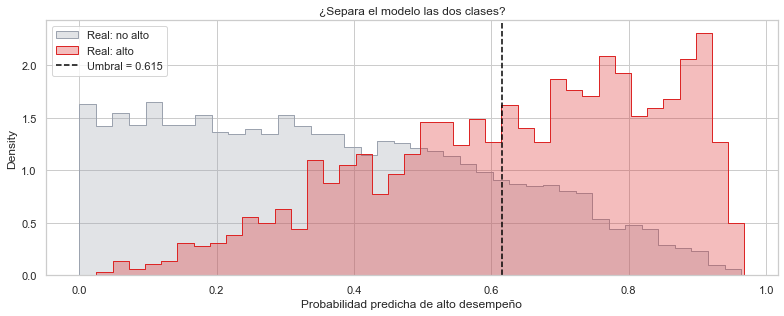

,count,mean,std,min,25%,50%,75%,max
clase_real,,,,,,,,
0,7459.0000,0.3670,0.2360,0.0000,0.1660,0.3420,0.5470,0.9640
1,1541.0000,0.6370,0.2090,0.0250,0.4890,0.6680,0.8080,0.9680


In [62]:
# 5.3.4 Distribución de la probabilidad predicha según la clase real (equivalente a los residuos en regresión)
prob_test = puntaje_positivo(modelo_final, X_test)                         # Probabilidad de alto desempeño en test
UMBRAL_MODELO = float(getattr(modelo_final, "best_threshold_", 0.5))       # Umbral con el que decide el modelo final
fig, eje = plt.subplots(figsize=(11, 4.5))
for clase, color, nombre in [(0, "#9ca3af", "Real: no alto"), (1, "#dc2626", "Real: alto")]:
    sns.histplot(prob_test[y_test.to_numpy() == clase], bins=40, stat="density", element="step",
                 fill=True, alpha=0.3, color=color, label=nombre, ax=eje)  # Densidad: compara formas, no tamaños
eje.axvline(UMBRAL_MODELO, color="black", ls="--", label=f"Umbral = {UMBRAL_MODELO:.3f}")
eje.set_xlabel("Probabilidad predicha de alto desempeño"); eje.set_title("¿Separa el modelo las dos clases?"); eje.legend()
plt.tight_layout(); guardar_figura("e_distribucion_probabilidades"); plt.show()
# Resumen de la probabilidad predicha por clase real
pd.DataFrame({"probabilidad": prob_test, "clase_real": y_test.to_numpy()}).groupby("clase_real")["probabilidad"].describe().round(3)

🔎 **Interpretación:** El gráfico muestra la distribución de la probabilidad predicha por el modelo para los estudiantes que realmente son "no alto" (gris) y "alto" (rojo), con el umbral de 0,615 marcado. Es el equivalente, en clasificación, al análisis de residuos de una regresión.
En general:
- Los estudiantes de alto desempeño reciben probabilidades claramente mayores: mediana 0,668 frente a 0,342.
- Las dos distribuciones **se solapan mucho** entre 0,35 y 0,75: allí conviven perfiles socioeconómicos parecidos con resultados distintos. Ese solapamiento es el límite de lo que se puede predecir con estas variables.
- A la derecha del umbral queda la mayoría de los "alto" (58 %, el Recall), pero también una cola de "no alto" que forma los falsos positivos.

Mover el umbral solo cambia qué parte del solapamiento se acepta; no elimina el error.

**¿Qué hacemos y por qué?** Mostramos cómo cambian Precision, Recall y F1 al mover el umbral de decisión. Así se explica
por qué el umbral elegido en validación cruzada no es 0,5.

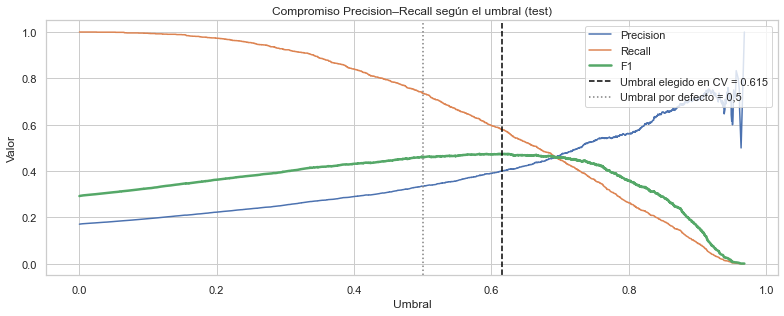

F1 máximo posible en test = 0.4745 (umbral 0.619); con el umbral elegido en CV = 0.4730


In [63]:
# 5.3.5 Precision, Recall y F1 según el umbral de decisión
precision_c, recall_c, umbrales_c = precision_recall_curve(y_test, prob_test)
f1_c = 2 * precision_c * recall_c / np.clip(precision_c + recall_c, 1e-12, None)   # F1 en cada umbral (sin dividir por 0)
fig, eje = plt.subplots(figsize=(11, 4.5))
eje.plot(umbrales_c, precision_c[:-1], label="Precision")                  # La curva trae un punto más que umbrales
eje.plot(umbrales_c, recall_c[:-1], label="Recall")
eje.plot(umbrales_c, f1_c[:-1], label="F1", lw=2.5)
eje.axvline(UMBRAL_MODELO, color="black", ls="--", label=f"Umbral elegido en CV = {UMBRAL_MODELO:.3f}")
eje.axvline(0.5, color="gray", ls=":", label="Umbral por defecto = 0,5")
eje.set_xlabel("Umbral"); eje.set_ylabel("Valor"); eje.set_title("Compromiso Precision–Recall según el umbral (test)"); eje.legend()
plt.tight_layout(); guardar_figura("e_metricas_vs_umbral"); plt.show()
mejor_i = int(np.nanargmax(f1_c[:-1]))                                     # Umbral que maximizaría F1 en test (solo referencia)
print(f"F1 máximo posible en test = {f1_c[mejor_i]:.4f} (umbral {umbrales_c[mejor_i]:.3f}); "
      f"con el umbral elegido en CV = {f1_score(y_test, prob_test >= UMBRAL_MODELO):.4f}")

🔎 **Interpretación:** El gráfico muestra cómo cambian Precision, Recall y F1 en prueba al mover el umbral de decisión entre 0 y 1, con el umbral por defecto (0,5) y el elegido en validación cruzada (0,615).
En general, al subir el umbral la Precision aumenta y el Recall disminuye, y el F1 forma una **meseta amplia** entre 0,5 y 0,7. El F1 máximo posible en prueba sería 0,4745, con un umbral de 0,619, casi igual al 0,4730 obtenido con el umbral elegido solo con entrenamiento (0,615).
Que el umbral de la validación cruzada caiga tan cerca del óptimo de prueba confirma que se eligió sin sobreajuste. En la práctica, el umbral podría moverse dentro de la meseta según la prioridad del programa (más Recall para no dejar candidatos por fuera, o más Precision para concentrar recursos) casi sin perder F1.

**¿Qué hacemos y por qué?** La **curva de ganancia acumulada** responde a la pregunta del negocio: si se revisa primero
al X % de estudiantes con mayor probabilidad, ¿qué % de los de alto desempeño se capta? El *lift* compara ese resultado
con una selección al azar.

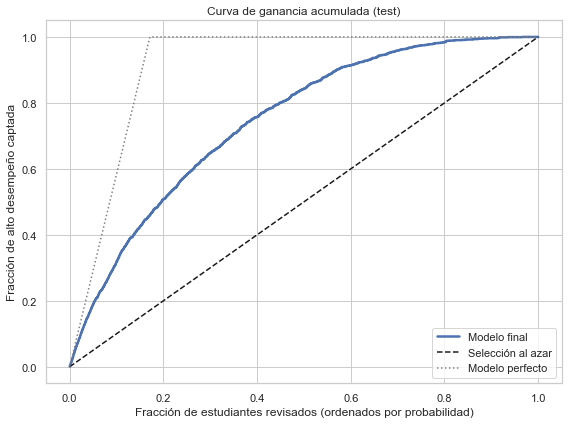

,top_pct_revisado,pct_alto_captado,lift
0,5,18.8000,3.7600
1,10,31.9000,3.1900
2,20,50.7000,2.5400
3,30,64.7000,2.1600
4,50,84.3000,1.6900


In [64]:
# 5.3.6 Curva de ganancia acumulada y tabla de lift
orden = np.argsort(-prob_test)                                             # Estudiantes de mayor a menor probabilidad
positivos_ordenados = y_test.to_numpy()[orden]
fraccion_poblacion = np.arange(1, len(orden) + 1) / len(orden)             # % de estudiantes revisados
fraccion_captada = np.cumsum(positivos_ordenados) / positivos_ordenados.sum()   # % de alto desempeño captado
fig, eje = plt.subplots(figsize=(8, 6))
eje.plot(fraccion_poblacion, fraccion_captada, lw=2.5, label="Modelo final")
eje.plot([0, 1], [0, 1], "k--", label="Selección al azar")
eje.plot([0, prevalencia, 1], [0, 1, 1], color="gray", ls=":", label="Modelo perfecto")   # Capta todo al revisar la prevalencia
eje.set_xlabel("Fracción de estudiantes revisados (ordenados por probabilidad)"); eje.set_ylabel("Fracción de alto desempeño captada")
eje.set_title("Curva de ganancia acumulada (test)"); eje.legend()
plt.tight_layout(); guardar_figura("e_ganancia_acumulada"); plt.show()
# Tabla de lift: cuántas veces mejor que el azar es revisar el top X %
filas = []
for p in [0.05, 0.10, 0.20, 0.30, 0.50]:
    captado = fraccion_captada[int(np.ceil(p * len(orden))) - 1]
    filas.append({"top_pct_revisado": int(p * 100), "pct_alto_captado": round(100 * captado, 1), "lift": round(captado / p, 2)})
guardar_tabla(pd.DataFrame(filas), "e_ganancia_lift")

🔎 **Interpretación:** El gráfico muestra la curva de ganancia acumulada: qué fracción de los estudiantes de alto desempeño se capta al revisar a los estudiantes ordenados de mayor a menor probabilidad. La tabla resume el *lift* en varios cortes.

| Estudiantes revisados | % de "alto" captado | Lift |
|---|---|---|
| 5 % | 18,8 % | 3,76 |
| 10 % | 31,9 % | 3,19 |
| 20 % | 50,7 % | 2,54 |
| 30 % | 64,7 % | 2,16 |
| 50 % | 84,3 % | 1,69 |

En general, revisando solo al 20 % de los estudiantes con mayor probabilidad se encuentra a la mitad de los de alto desempeño: 2,5 veces más de lo que daría una selección al azar. El lift es mayor en los primeros cortes, así que el modelo es más útil cuando los recursos son escasos y solo se puede atender a una fracción pequeña.

**¿Qué hacemos y por qué?** La **curva de calibración** compara la probabilidad predicha con la frecuencia real de alto
desempeño en 10 grupos. Muestra si "70 %" significa realmente 70 %.

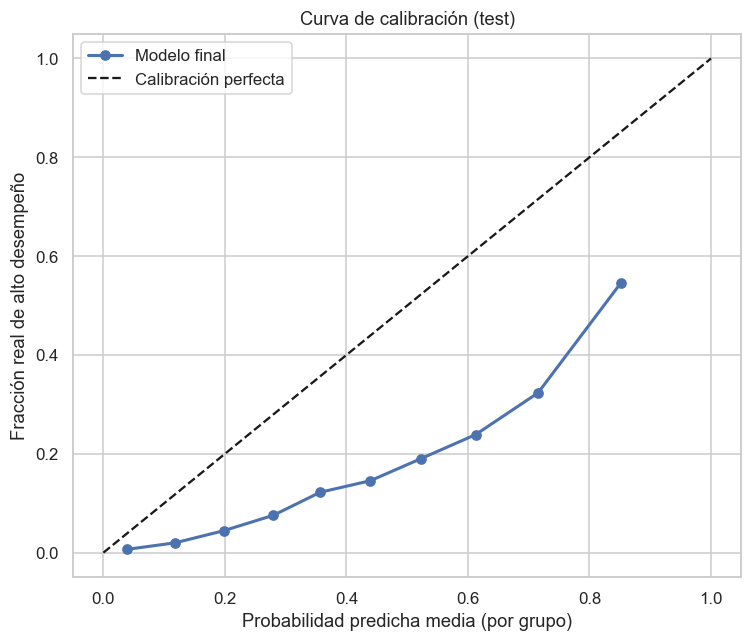

,prob_predicha_media,tasa_real
0,0.0390,0.0070
1,0.1180,0.0200
2,0.1980,0.0440
3,0.2800,0.0760
4,0.3570,0.1220
5,0.4390,0.1460
6,0.5220,0.1900
7,0.6130,0.2390
8,0.7150,0.3230
9,0.8520,0.5460


In [61]:
# 5.3.7 Curva de calibración de las probabilidades del modelo final
frac_real, prob_media = calibration_curve(y_test, prob_test, n_bins=10, strategy="quantile")   # 10 grupos de igual tamaño
fig, eje = plt.subplots(figsize=(7, 6))
eje.plot(prob_media, frac_real, marker="o", lw=2, label="Modelo final")
eje.plot([0, 1], [0, 1], "k--", label="Calibración perfecta")               # Diagonal: probabilidad = frecuencia real
eje.set_xlabel("Probabilidad predicha media (por grupo)"); eje.set_ylabel("Fracción real de alto desempeño")
eje.set_title("Curva de calibración (test)"); eje.legend()
plt.tight_layout(); guardar_figura("e_calibracion"); plt.show()
# Probabilidad predicha frente a la tasa observada en cada grupo
pd.DataFrame({"prob_predicha_media": prob_media, "tasa_real": frac_real}).round(3)

🔎 **Interpretación:** El gráfico muestra la curva de calibración: para grupos de estudiantes con probabilidad predicha parecida, compara esa probabilidad media con la fracción que realmente tuvo alto desempeño.
En general, la curva queda **por debajo de la diagonal** en todo el rango: el modelo **sobreestima** la probabilidad. Por ejemplo, el grupo con probabilidad media 0,61 tiene una tasa real del 24 %, y el de 0,85 una del 55 %.
Es la consecuencia esperada del submuestreo: el modelo aprendió con clases 50/50 y "cree" que el alto desempeño es mucho más común que el 17 % real. El **orden** de los estudiantes sí es correcto (la curva siempre sube), y por eso el F1 y el ranking no se ven afectados. Si las probabilidades se fueran a comunicar como riesgos, habría que recalibrarlas (por ejemplo, con `CalibratedClassifierCV`); para clasificar con un umbral ajustado no es necesario.

**¿Qué hacemos y por qué?** Si el modelo final es lineal (regresión logística), sus **coeficientes** muestran la dirección
y la magnitud del efecto de cada variable codificada. El *odds ratio* = e^coef indica cuánto se multiplican las odds de
alto desempeño.

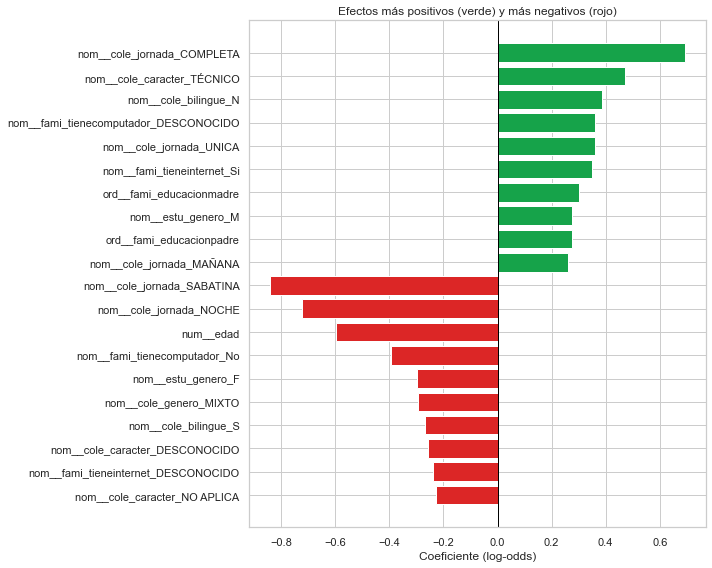

,variable,coeficiente,odds_ratio
27,nom__cole_jornada_COMPLETA,0.6930,1.9990
41,nom__cole_caracter_TÉCNICO,0.4700,1.6000
36,nom__cole_bilingue_N,0.3840,1.4690
16,nom__fami_tienecomputador_DESCONOCIDO,0.3620,1.4360
32,nom__cole_jornada_UNICA,0.3600,1.4330
15,nom__fami_tieneinternet_Si,0.3510,1.4200
2,ord__fami_educacionmadre,0.3030,1.3530
12,nom__estu_genero_M,0.2750,1.3160
3,ord__fami_educacionpadre,0.2740,1.3150
28,nom__cole_jornada_MAÑANA,0.2600,1.2970


In [65]:
# 5.3.8 Coeficientes del modelo final: los 10 efectos más positivos y los 10 más negativos
modelo_interno = getattr(modelo_final, "estimator_", modelo_final)         # Pipeline dentro del ajuste de umbral
clasificador = modelo_interno.named_steps["modelo"]
if hasattr(clasificador, "coef_"):                                          # Solo los modelos lineales tienen coeficientes
    nombres = modelo_interno.named_steps["preprocesamiento"].get_feature_names_out()
    coeficientes = pd.DataFrame({"variable": nombres, "coeficiente": clasificador.coef_[0]})
    coeficientes["odds_ratio"] = np.exp(coeficientes["coeficiente"])       # Factor que multiplica las odds de alto desempeño
    extremos = pd.concat([coeficientes.nlargest(10, "coeficiente"), coeficientes.nsmallest(10, "coeficiente")])
    fig, eje = plt.subplots(figsize=(10, 8))
    colores = ["#16a34a" if c > 0 else "#dc2626" for c in extremos["coeficiente"]]   # Verde aumenta, rojo disminuye
    eje.barh(extremos["variable"], extremos["coeficiente"], color=colores)
    eje.axvline(0, color="black", lw=1); eje.invert_yaxis()
    eje.set_xlabel("Coeficiente (log-odds)"); eje.set_title("Efectos más positivos (verde) y más negativos (rojo)")
    plt.tight_layout(); guardar_figura("e_coeficientes"); plt.show()
    guardar_tabla(coeficientes.round(4), "e_coeficientes")
    display(extremos.round(3))
else:
    print("El modelo final no es lineal: sus efectos se leen con la importancia por permutación (5.3.9).")

🔎 **Interpretación:** El gráfico y la tabla muestran los 10 coeficientes más positivos y los 10 más negativos de la regresión logística, con su *odds ratio* (e^coeficiente): cuánto se multiplican las odds de alto desempeño cuando la columna pasa de 0 a 1 (o aumenta una desviación estándar, en las variables estandarizadas).
En general:
- **Jornada:** es el factor más fuerte en ambos sentidos. La jornada completa multiplica las odds por 2,0, mientras la sabatina (0,43) y la nocturna (0,49) las reducen a menos de la mitad.
- **Edad:** cada desviación estándar adicional (≈ 1,7 años) reduce las odds a 0,55: la extraedad es la señal individual más clara.
- **Hogar:** la educación de la madre (1,35) y la del padre (1,32) por desviación estándar, tener internet (1,42) y no tener computador (0,67) confirman el gradiente socioeconómico.
- **Género:** ser hombre aumenta las odds (1,32) y ser mujer las reduce (0,74), en línea con la brecha observada en 2.5.

Algunos coeficientes deben leerse con cuidado. `cole_bilingue_N` positivo y `cole_bilingue_S` negativo parecen contradecir el sentido común, pero el grupo bilingüe es diminuto (0,3 %) y su efecto ya lo capturan el estrato y la naturaleza del colegio. En una codificación one-hot los coeficientes son **relativos** entre categorías de la misma variable, y con variables correlacionadas se reparten el efecto. Son asociaciones condicionadas a las demás variables, no efectos causales.

**¿Qué hacemos y por qué?** La **importancia por permutación** mide cuánto cae el F1 al desordenar cada variable original.
Sirve para cualquier modelo y habla en la métrica del negocio.

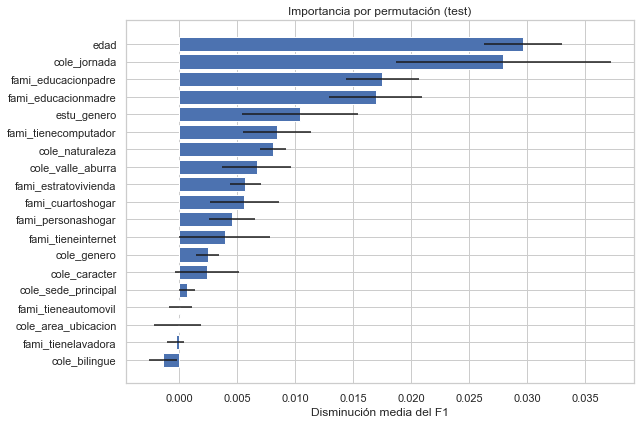

,variable,importancia,desviacion
0,edad,0.0296,0.0034
1,cole_jornada,0.0279,0.0093
2,fami_educacionpadre,0.0175,0.0032
3,fami_educacionmadre,0.0169,0.0040
4,estu_genero,0.0104,0.0050
5,fami_tienecomputador,0.0084,0.0029
6,cole_naturaleza,0.0081,0.0011
7,cole_valle_aburra,0.0067,0.0030
8,fami_estratovivienda,0.0057,0.0013
9,fami_cuartoshogar,0.0056,0.0029


In [66]:
# 5.3.9 Importancia de variables por permutación en test (caída del F1 al desordenar cada variable)
# n_repeats=5: cada variable se permuta 5 veces y se promedia, para reducir el ruido del azar
importancia = permutation_importance(modelo_final, X_test, y_test, scoring="f1", n_repeats=5,
                                     random_state=RANDOM_STATE, n_jobs=-1)
df_importancia = (pd.DataFrame({"variable": FEATURES, "importancia": importancia.importances_mean,
                                "desviacion": importancia.importances_std})
                  .sort_values("importancia", ascending=False).reset_index(drop=True))
df_importancia.to_csv(DIR_MODELOS / "importancias.csv", index=False)   # La app muestra este gráfico

fig, eje = plt.subplots(figsize=(9, 6))
eje.barh(df_importancia["variable"], df_importancia["importancia"], xerr=df_importancia["desviacion"], color="#4C72B0")
eje.invert_yaxis(); eje.set_xlabel("Disminución media del F1"); eje.set_title("Importancia por permutación (test)")
plt.tight_layout(); guardar_figura("importancia_permutacion"); plt.show()
df_importancia.round(4)   # Valores ≈ 0 (o negativos) = la variable no aporta al modelo

🔎 **Interpretación:** La tabla y el gráfico muestran la importancia por permutación (caída del F1 en prueba al desordenar cada variable):

| Variable | Caída del F1 |
|---|---|
| Edad | 0,030 |
| Jornada | 0,028 |
| Educación del padre | 0,018 |
| Educación de la madre | 0,017 |
| Género | 0,010 |
| Computador en el hogar | 0,008 |
| Naturaleza del colegio | 0,008 |
| Valle de Aburrá | 0,007 |

En general, el **estrato** aparece con una importancia baja (0,006) aunque en 3.6 estaba muy asociado al objetivo: comparte información con la educación de los padres y las tenencias del hogar, así que al desordenarlo el modelo compensa con esas variables correlacionadas. Automóvil, zona, lavadora y colegio bilingüe tienen importancias de cero o negativas: no aportan una vez consideradas las demás.

**¿Qué hacemos y por qué?** La **curva de aprendizaje** muestra si más datos mejorarían el modelo. Justifica haber
modelado con 30.000 registros.

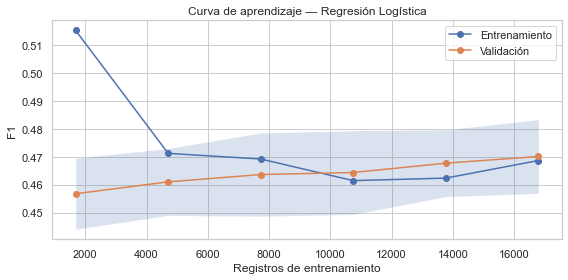

In [67]:
# 5.3.10 Curva de aprendizaje del modelo final: ¿más datos mejorarían el F1? (justifica la muestra de 30.000)
# train_sizes: 6 tamaños entre el 10 % y el 100 % del entrenamiento; en cada uno se hace la CV de 5 folds
tamanos, f1_entrena, f1_valida = learning_curve(busquedas[FAMILIA_FINAL].best_estimator_, X_train, y_train, cv=CV,
                                                 scoring="f1", train_sizes=np.linspace(0.1, 1.0, 6), n_jobs=-1)
fig, eje = plt.subplots(figsize=(8, 4))
eje.plot(tamanos, f1_entrena.mean(axis=1), marker="o", label="Entrenamiento")   # Media de los 5 folds
eje.plot(tamanos, f1_valida.mean(axis=1), marker="o", label="Validación")
# Banda de ± 1 desviación: variabilidad entre folds
eje.fill_between(tamanos, f1_valida.mean(axis=1) - f1_valida.std(axis=1), f1_valida.mean(axis=1) + f1_valida.std(axis=1), alpha=0.2)
eje.set_xlabel("Registros de entrenamiento"); eje.set_ylabel("F1"); eje.set_title(f"Curva de aprendizaje — {FAMILIA_FINAL}"); eje.legend()
plt.tight_layout(); guardar_figura("curva_aprendizaje"); plt.show()

🔎 **Interpretación:** El gráfico muestra la curva de aprendizaje del modelo final: F1 de entrenamiento y de validación según el número de registros usados.
En general, ambas curvas **convergen alrededor de 0,47** a partir de unos 10 mil registros, y con 17 mil la brecha es prácticamente nula. Es un patrón de **alto sesgo**, no de alta varianza: agregar más registros (por ejemplo, los 72 mil disponibles) apenas mejoraría el modelo, lo que justifica haber modelado con 30 mil. Para mejorar habría que aportar **variables más informativas**, como el efecto colegio.

### 5.4 Equidad por subgrupos

**¿Qué hacemos y por qué?** Calculamos las métricas del modelo final por género, zona, naturaleza y subregión. Un buen
desempeño global puede esconder grupos donde el modelo funciona peor.

In [65]:
# 5.4.1 Desempeño por subgrupo: control de sesgo del modelo final (género, zona, naturaleza, subregión)
serie_pred = pd.Series(predicciones[NOMBRE_FINAL], index=X_test.index)   # Predicciones alineadas con los índices de test
filas = []
for var in ["estu_genero", "cole_area_ubicacion", "cole_naturaleza", "cole_valle_aburra"]:
    for grupo, indices in X_test.groupby(X_test[var].fillna("DESCONOCIDO")).groups.items():   # Índices de cada grupo
        real, pred = y_test.loc[indices], serie_pred.loc[indices]
        # zero_division=0 evita errores en grupos sin positivos predichos
        filas.append({"variable": var, "grupo": grupo, "registros": len(indices),
                      "tasa_real": real.mean(), "tasa_predicha": pred.mean(),
                      "precision": precision_score(real, pred, zero_division=0),
                      "recall": recall_score(real, pred, zero_division=0), "f1": f1_score(real, pred, zero_division=0)})
tabla_subgrupos = guardar_tabla(pd.DataFrame(filas).round(4), "desempeno_subgrupos")
tabla_subgrupos

,variable,grupo,registros,tasa_real,tasa_predicha,precision,recall,f1
0,estu_genero,F,4974,0.1456,0.1673,0.4411,0.5069,0.4717
1,estu_genero,M,4026,0.2029,0.3485,0.3749,0.6438,0.4739
2,cole_area_ubicacion,RURAL,1485,0.1064,0.1057,0.4841,0.4810,0.4825
3,cole_area_ubicacion,URBANO,7515,0.1840,0.2765,0.3932,0.5907,0.4721
4,cole_naturaleza,NO OFICIAL,1843,0.3201,0.5334,0.5239,0.8729,0.6548
5,cole_naturaleza,OFICIAL,7157,0.1329,0.1749,0.3019,0.3975,0.3432
6,cole_valle_aburra,No,3743,0.1122,0.1341,0.3486,0.4167,0.3796
7,cole_valle_aburra,Sí,5257,0.2132,0.3297,0.4143,0.6405,0.5032


🔎 **Interpretación:** La tabla muestra las métricas del modelo final por subgrupo en el conjunto de prueba: tasa real y predicha de alto desempeño, Precision, Recall y F1.
En general, hay **diferencias importantes**:
- **Naturaleza del colegio:** F1 de 0,65 en colegios no oficiales frente a 0,34 en oficiales. En los oficiales el modelo solo detecta al 40 % de los estudiantes de alto desempeño (Recall 0,40, frente a 0,87 en los no oficiales).
- **Subregión:** fuera del Valle de Aburrá el F1 es 0,38, frente a 0,50 dentro.
- **Zona:** el F1 es parecido (0,48 rural y 0,47 urbano), pero en la zona urbana el modelo predice "alto" para el 28 % frente a un 18 % real.
- **Género:** el F1 es similar (0,47 en ambos), pero en hombres el modelo **sobrepredice** "alto" (35 % predicho frente a 20 % real), mientras en mujeres queda cerca de la tasa real (17 % frente a 15 %).

El modelo funciona peor precisamente en los grupos menos favorecidos, cuyos estudiantes de alto desempeño tienen perfiles socioeconómicos "atípicos" que el modelo no reconoce. Es la amplificación del **sesgo histórico** descrito en 2.5 y la razón principal para no usar el modelo en decisiones individuales.

### 5.5 Criterio de negocio: ¿se cumple?

**¿Qué hacemos y por qué?** Verificamos uno por uno los tres criterios de negocio definidos en 1.5 con los resultados del
conjunto de prueba.

In [69]:
# 5.5.1 Verificación del criterio de negocio definido en 1.5
fila_final = df_test.set_index("modelo").loc[NOMBRE_FINAL]                  # Métricas de test del modelo final
f1_linea_base = df_test.set_index("modelo").loc["Regresión Logística (base)", "f1"]
lift = fila_final["precision"] / prevalencia                                # Veces que el modelo supera a la selección al azar
criterios = pd.DataFrame([
    {"criterio": "Detectar al menos la mitad de los estudiantes de alto desempeño", "meta": "Recall ≥ 0,55",
     "resultado": round(fila_final["recall"], 4), "cumple": fila_final["recall"] >= 0.55},
    {"criterio": "Focalizar mejor que el azar", "meta": f"Lift ≥ 2 (tasa base = {prevalencia:.3f})",
     "resultado": round(lift, 2), "cumple": lift >= 2},
    {"criterio": "Superar la línea base", "meta": f"F1 > {f1_linea_base:.4f} (regresión logística base)",
     "resultado": round(fila_final["f1"], 4), "cumple": fila_final["f1"] > f1_linea_base}])
criterios["cumple"] = criterios["cumple"].map({True: "✅ Sí", False: "❌ No"})    # Lectura directa para el informe
guardar_tabla(criterios, "e_criterio_negocio")
criterios

,criterio,meta,resultado,cumple
0,Detectar al menos la mitad de los estudiantes ...,"Recall ≥ 0,55",0.5795,✅ Sí
1,Focalizar mejor que el azar,Lift ≥ 2 (tasa base = 0.171),2.3300,✅ Sí
2,Superar la línea base,F1 > 0.4593 (regresión logística base),0.4730,✅ Sí


🔎 **Interpretación:** La tabla muestra la verificación de los tres criterios de negocio definidos en 1.5 con el modelo final en el conjunto de prueba:

| Criterio | Meta | Resultado | ¿Cumple? |
|---|---|---|---|
| Detectar al menos la mitad de los estudiantes de alto desempeño | Recall ≥ 0,55 | 0,580 | ✅ Sí |
| Focalizar mejor que el azar | Lift ≥ 2 | 2,33 | ✅ Sí |
| Superar la línea base | F1 > 0,4593 | 0,4730 | ✅ Sí |

En general, **los tres criterios se cumplen**, aunque con márgenes modestos: el Recall supera la meta en 3 puntos y el lift en 0,33. El modelo es útil para **focalizar** programas (priorizar a quién ofrecer acompañamiento o preparación), pero no para decidir sobre estudiantes individuales, por los errores descritos en 5.3 y las diferencias por grupo de 5.4.

## 6. Despliegue
### 6.0 Serialización del pipeline completo

**¿Qué hacemos y por qué?** Guardamos en disco el **pipeline completo** (preprocesamiento, balanceo y modelo) con su umbral
de decisión. La aplicación usará exactamente lo que se evaluó.

In [70]:
# 6.0.1 Extraer el pipeline final y su umbral, y serializarlo con joblib
if isinstance(modelo_final, TunedThresholdClassifierCV):
    # El envoltorio del umbral contiene el pipeline reentrenado (estimator_) y el umbral óptimo (best_threshold_)
    pipeline_final, umbral_final = modelo_final.estimator_, float(modelo_final.best_threshold_)
else:
    pipeline_final = modelo_final
    umbral_final = 0.5 if hasattr(pipeline_final, "predict_proba") else 0.0   # 0 = frontera de decision_function

RUTA_MODELO = DIR_MODELOS / "pipeline_saber11.joblib"
joblib.dump(pipeline_final, RUTA_MODELO, compress=3)   # compress=3: buen equilibrio entre tamaño y velocidad de carga
tamano_mb = RUTA_MODELO.stat().st_size / 1e6
assert tamano_mb < 95, "El modelo supera el límite de GitHub (100 MB)"
print(f"Pipeline guardado: {RUTA_MODELO.name} ({tamano_mb:.1f} MB) | umbral de decisión = {umbral_final:.4f}")
if tamano_mb > 25:   # La carga por la web de GitHub admite hasta 25 MB; con git se admiten hasta 100 MB
    print("Aviso: supera 25 MB; súbalo con git (no con la carga web de GitHub).")
print("Pasos:", [nombre for nombre, _ in pipeline_final.steps])   # El balanceo se omite al predecir (solo actúa en fit)

Pipeline guardado: pipeline_saber11.joblib (0.0 MB) | umbral de decisión = 0.6152
Pasos: ['preprocesamiento', 'balanceo', 'modelo']


🔎 **Interpretación:** La salida muestra que se serializó el pipeline completo (`preprocesamiento` → `balanceo` → `modelo`) en `models/pipeline_saber11.joblib`, con un tamaño de unos **20 KB**, porque una regresión logística guarda un coeficiente por columna codificada (un Random Forest de 341 árboles habría pesado decenas de MB).
En general, el umbral de decisión (0,6152) se extrae del envoltorio `TunedThresholdClassifierCV` y se guarda en la metadata. El paso `balanceo` viaja dentro del pipeline, pero solo actúa en `fit`: al predecir no altera los datos.

**¿Qué hacemos y por qué?** Guardamos la **metadata** que usa la app: variables, categorías válidas, etiquetas, valores por
defecto, umbral, métricas y versiones de las librerías.

In [71]:
# 6.0.2 Metadata para la app: variables, categorías válidas, etiquetas, umbral, métricas y versiones
# Etiquetas legibles para el formulario de la app (el usuario no ve nombres técnicos como fami_estratovivienda)
ETIQUETAS = {"edad": "Edad (años)", "estu_genero": "Género del estudiante", "fami_estratovivienda": "Estrato de la vivienda",
             "fami_educacionmadre": "Educación de la madre", "fami_educacionpadre": "Educación del padre",
             "fami_personashogar": "Personas en el hogar", "fami_cuartoshogar": "Cuartos en el hogar",
             "fami_tieneinternet": "¿Internet en el hogar?", "fami_tienecomputador": "¿Computador en el hogar?",
             "fami_tieneautomovil": "¿Automóvil en el hogar?", "fami_tienelavadora": "¿Lavadora en el hogar?",
             "cole_naturaleza": "Naturaleza del colegio", "cole_jornada": "Jornada", "cole_area_ubicacion": "Zona del colegio",
             "cole_bilingue": "¿Colegio bilingüe? (S/N)", "cole_caracter": "Carácter del colegio",
             "cole_genero": "Género del colegio", "cole_sede_principal": "¿Sede principal? (S/N)",
             "cole_valle_aburra": "¿Colegio en el Valle de Aburrá?"}
# Opciones de cada lista desplegable: categorías vistas en entrenamiento (nominales) u orden natural (ordinales)
categorias_app = {v: sorted(X_train[v].dropna().unique().tolist()) for v in VARIABLES_NOMINALES}
categorias_app.update({v: list(ORDEN_ORDINALES[v]) for v in VARIABLES_ORDINALES})
for v in ["fami_educacionmadre", "fami_educacionpadre"]:
    categorias_app[v] = categorias_app[v] + ["No sabe"]   # El pipeline lo trata como faltante (imputación)

metadata = {
    "proyecto": "Predicción de alto desempeño en Saber 11 — Antioquia 2022-2",
    "proposito": "Proyecto académico de maestría con fines exclusivamente educativos; no es una herramienta oficial",
    "fuente": URL_DATASET, "objetivo": f"alto_desempeno = 1 si punt_global >= {UMBRAL_ALTO_DESEMPENO}",
    "modelo_final": NOMBRE_FINAL, "umbral_decision": umbral_final,
    "tipo_puntaje": "probabilidad" if hasattr(pipeline_final, "predict_proba") else "decision",
    # Si el modelo es XGBoost, la app necesita instalar xgboost (se usa al generar requirements.txt)
    "requiere_xgboost": type(pipeline_final.named_steps["modelo"]).__module__.startswith("xgboost"),
    "features": FEATURES, "variables_numericas": VARIABLES_NUMERICAS, "variables_ordinales": VARIABLES_ORDINALES,
    "variables_nominales": VARIABLES_NOMINALES, "categorias": categorias_app, "etiquetas": ETIQUETAS,
    "rango_edad": [13, 30], "edad_mediana": float(X_train["edad"].median()),
    # Moda de cada variable: el formulario de la app arranca con un perfil típico y no con la primera opción alfabética
    "valores_por_defecto": {v: str(X_train[v].mode()[0]) for v in VARIABLES_ORDINALES + VARIABLES_NOMINALES},
    "metricas_test": {k: float(v) for k, v in df_test.set_index("modelo").loc[NOMBRE_FINAL].items()},   # float: JSON no admite numpy
    "n_entrenamiento": int(len(X_train)), "n_prueba": int(len(X_test)),
    "versiones": {"python": sys.version.split()[0], "scikit-learn": sklearn.__version__, "imbalanced-learn": imblearn.__version__,
                  "xgboost": xgboost.__version__, "pandas": pd.__version__, "numpy": np.__version__},
    "fecha_entrenamiento": pd.Timestamp.now().strftime("%Y-%m-%d"),
}
# ensure_ascii=False conserva tildes y eñes legibles en el archivo JSON
(DIR_MODELOS / "metadata.json").write_text(json.dumps(metadata, ensure_ascii=False, indent=2), encoding="utf-8")
print(json.dumps({k: metadata[k] for k in ["modelo_final", "umbral_decision", "tipo_puntaje", "metricas_test"]},
                 ensure_ascii=False, indent=2))

{
  "modelo_final": "Regresión Logística (ajustado + umbral)",
  "umbral_decision": 0.6152265930418449,
  "tipo_puntaje": "probabilidad",
  "metricas_test": {
    "accuracy": 0.7788888888888889,
    "precision": 0.3995525727069351,
    "recall": 0.5794938351719663,
    "f1": 0.4729872881355932,
    "roc_auc": 0.7975366352717372,
    "pr_auc": 0.46134249032583907
  }
}


🔎 **Interpretación:** La salida muestra un extracto de la metadata que acompaña al modelo (`models/metadata.json`): el nombre del modelo final, el umbral (0,6152), el tipo de puntaje (probabilidad) y las métricas de prueba (F1 0,473, Recall 0,579, ROC-AUC 0,798). El archivo completo registra además:
- Las 19 variables y sus categorías válidas, en el orden natural para las ordinales, y sus etiquetas legibles para el formulario.
- Las versiones exactas de las librerías y el propósito académico del proyecto.

En general, la aplicación lee todo desde este archivo, sin valores fijados en su código. `requiere_xgboost = False` indica que la app no necesita instalar xgboost, lo que aligera el despliegue.

**¿Qué hacemos y por qué?** Verificamos que el pipeline recargado desde disco produce exactamente las mismas predicciones.

In [72]:
# 6.0.3 Verificación: el pipeline recargado desde disco produce exactamente los mismos puntajes
# joblib usa pickle: solo se carga el archivo que acabamos de generar (fuente confiable)
pipeline_recargado = joblib.load(RUTA_MODELO)
# np.allclose tolera diferencias mínimas de redondeo en coma flotante
assert np.allclose(puntaje_positivo(pipeline_recargado, X_test), puntaje_positivo(pipeline_final, X_test))
print("Pipeline recargado: predicciones idénticas en los", len(X_test), "registros de prueba")

Pipeline recargado: predicciones idénticas en los 9000 registros de prueba


🔎 **Interpretación:** La salida confirma que el pipeline recargado desde disco produce **exactamente** los mismos puntajes en los 9.000 registros de prueba.
En general, así se verifica que la serialización conserva el modelo completo (preprocesamiento incluido) y que lo evaluado en la fase 5 es lo que se despliega. La misma verificación está automatizada en `tests/test_modelo.py`, que además prueba categorías desconocidas y valores faltantes.

### 6.1 Predicción con datos nuevos

**¿Qué hacemos y por qué?** Generamos 10 perfiles nuevos: 5 arquetipos diseñados y 5 aleatorios. Sirven como prueba de
sensatez del modelo.

In [73]:
# 6.1.1 Generación de 10 perfiles nuevos: 5 arquetipos diseñados + 5 aleatorios de las distribuciones observadas
# Perfil base "típico"; cada arquetipo modifica solo las variables que lo caracterizan
BASE_PERFIL = {"edad": 17, "estu_genero": "F", "fami_estratovivienda": "Estrato 2",
               "fami_educacionmadre": "Secundaria (Bachillerato) completa", "fami_educacionpadre": "Secundaria (Bachillerato) completa",
               "fami_personashogar": "3 a 4", "fami_cuartoshogar": "Tres", "fami_tieneinternet": "Si", "fami_tienecomputador": "Si",
               "fami_tieneautomovil": "No", "fami_tienelavadora": "Si", "cole_naturaleza": "OFICIAL", "cole_jornada": "MAÑANA",
               "cole_area_ubicacion": "URBANO", "cole_bilingue": "N", "cole_caracter": "ACADÉMICO", "cole_genero": "MIXTO",
               "cole_sede_principal": "S", "cole_valle_aburra": "Sí"}
ARQUETIPOS = [   # (nombre, cambios respecto al perfil base)
    ("A1 · Rural oficial, estrato 1, sin internet ni computador",
     {"edad": 18, "estu_genero": "M", "fami_estratovivienda": "Estrato 1", "fami_educacionmadre": "Primaria incompleta",
      "fami_educacionpadre": "Primaria incompleta", "fami_personashogar": "5 a 6", "fami_cuartoshogar": "Dos",
      "fami_tieneinternet": "No", "fami_tienecomputador": "No", "fami_tienelavadora": "No", "cole_jornada": "UNICA",
      "cole_area_ubicacion": "RURAL", "cole_caracter": "TÉCNICO/ACADÉMICO", "cole_sede_principal": "N", "cole_valle_aburra": "No"}),
    ("A2 · Urbano oficial del Valle de Aburrá, estrato 2, madre bachiller", {}),   # Es el perfil base sin cambios
    ("A3 · Urbano no oficial, estrato 4, padres profesionales",
     {"estu_genero": "M", "fami_estratovivienda": "Estrato 4", "fami_educacionmadre": "Educación profesional completa",
      "fami_educacionpadre": "Educación profesional completa", "fami_tieneautomovil": "Si", "cole_naturaleza": "NO OFICIAL",
      "cole_jornada": "COMPLETA"}),
    ("A4 · Colegio bilingüe no oficial, estrato 6, padres con posgrado",
     {"edad": 16, "fami_estratovivienda": "Estrato 6", "fami_educacionmadre": "Postgrado", "fami_educacionpadre": "Postgrado",
      "fami_cuartoshogar": "Cuatro", "fami_tieneautomovil": "Si", "cole_naturaleza": "NO OFICIAL", "cole_jornada": "COMPLETA",
      "cole_bilingue": "S"}),
    ("A5 · Adulto en jornada sabatina, estrato 2, padre desconocido",   # "No sabe" prueba el manejo de faltantes
     {"edad": 26, "fami_educacionmadre": "Primaria completa", "fami_educacionpadre": "No sabe", "fami_cuartoshogar": "Dos",
      "fami_tienecomputador": "No", "cole_naturaleza": "NO OFICIAL", "cole_jornada": "SABATINA"}),
]
rng = np.random.default_rng(RANDOM_STATE)   # Generador reproducible para los perfiles aleatorios
# {**BASE_PERFIL, **cambios}: el segundo diccionario sobrescribe las claves del primero
registros = [{"registro": nombre, **BASE_PERFIL, **cambios} for nombre, cambios in ARQUETIPOS]
for i in range(1, 6):
    # Cada variable se sortea de su distribución marginal observada (las combinaciones pueden ser inusuales)
    aleatorio = {v: rng.choice(X_train[v].dropna().to_numpy()) for v in FEATURES if v != "edad"}
    registros.append({"registro": f"R{i} · Perfil aleatorio", "edad": int(rng.integers(15, 20)), **aleatorio})
df_nuevos = pd.DataFrame(registros)[["registro"] + FEATURES]
df_nuevos.to_csv(DIR_NUEVOS / "perfiles_nuevos.csv", index=False)   # Entregable: "generar nuevos datos de entrada"
df_nuevos

,registro,edad,fami_estratovivienda,fami_educacionmadre,fami_educacionpadre,fami_personashogar,fami_cuartoshogar,estu_genero,fami_tieneinternet,fami_tienecomputador,fami_tieneautomovil,fami_tienelavadora,cole_naturaleza,cole_jornada,cole_area_ubicacion,cole_bilingue,cole_caracter,cole_genero,cole_sede_principal,cole_valle_aburra
0,"A1 · Rural oficial, estrato 1, sin internet ni...",18,Estrato 1,Primaria incompleta,Primaria incompleta,5 a 6,Dos,M,No,No,No,No,OFICIAL,UNICA,RURAL,N,TÉCNICO/ACADÉMICO,MIXTO,N,No
1,"A2 · Urbano oficial del Valle de Aburrá, estra...",17,Estrato 2,Secundaria (Bachillerato) completa,Secundaria (Bachillerato) completa,3 a 4,Tres,F,Si,Si,No,Si,OFICIAL,MAÑANA,URBANO,N,ACADÉMICO,MIXTO,S,Sí
2,"A3 · Urbano no oficial, estrato 4, padres prof...",17,Estrato 4,Educación profesional completa,Educación profesional completa,3 a 4,Tres,M,Si,Si,Si,Si,NO OFICIAL,COMPLETA,URBANO,N,ACADÉMICO,MIXTO,S,Sí
3,"A4 · Colegio bilingüe no oficial, estrato 6, p...",16,Estrato 6,Postgrado,Postgrado,3 a 4,Cuatro,F,Si,Si,Si,Si,NO OFICIAL,COMPLETA,URBANO,S,ACADÉMICO,MIXTO,S,Sí
4,"A5 · Adulto en jornada sabatina, estrato 2, pa...",26,Estrato 2,Primaria completa,No sabe,3 a 4,Dos,F,Si,No,No,Si,NO OFICIAL,SABATINA,URBANO,N,ACADÉMICO,MIXTO,S,Sí
5,R1 · Perfil aleatorio,19,Estrato 3,Primaria incompleta,Secundaria (Bachillerato) incompleta,3 a 4,Tres,F,Si,Si,Si,Si,OFICIAL,COMPLETA,URBANO,N,TÉCNICO/ACADÉMICO,MIXTO,S,Sí
6,R2 · Perfil aleatorio,19,Estrato 3,Secundaria (Bachillerato) completa,Técnica o tecnológica completa,3 a 4,Seis o mas,F,Si,Si,Si,Si,OFICIAL,SABATINA,RURAL,N,ACADÉMICO,MIXTO,S,No
7,R3 · Perfil aleatorio,17,Estrato 3,Primaria completa,Primaria incompleta,3 a 4,Dos,M,Si,Si,No,No,OFICIAL,COMPLETA,URBANO,N,TÉCNICO,MIXTO,S,No
8,R4 · Perfil aleatorio,17,Estrato 2,Educación profesional completa,Primaria incompleta,7 a 8,Tres,F,Si,No,No,Si,OFICIAL,SABATINA,URBANO,N,TÉCNICO/ACADÉMICO,MIXTO,N,Sí
9,R5 · Perfil aleatorio,19,Estrato 1,Secundaria (Bachillerato) completa,Primaria completa,3 a 4,Cinco,F,Si,Si,No,Si,NO OFICIAL,COMPLETA,RURAL,N,TÉCNICO/ACADÉMICO,MIXTO,N,Sí


🔎 **Interpretación:** La tabla muestra los 10 perfiles nuevos generados y guardados en `data/nuevos/perfiles_nuevos.csv`:
- **Cinco arquetipos diseñados**, desde un estudiante rural de estrato 1 sin internet hasta uno de colegio bilingüe de estrato 6. El A5 tiene educación del padre "No sabe" para probar el manejo de faltantes.
- **Cinco perfiles aleatorios**, muestreando cada variable de su distribución observada.

En general, los arquetipos funcionan como **pruebas de sensatez**: si el modelo les asignara probabilidades contrarias al conocimiento del dominio, habría un error en el pipeline.

**¿Qué hacemos y por qué?** Predecimos e interpretamos los perfiles nuevos con el pipeline recargado (tabla 6.1 del informe).

In [74]:
# 6.1.2 Predicción e interpretación de los perfiles nuevos con el pipeline recargado
def interpretar(puntaje, umbral):
    """Traduce el puntaje a un mensaje comprensible (tres bandas alrededor del umbral de decisión)."""
    if puntaje >= umbral:
        return "Perfil similar a estudiantes con alto desempeño: priorizar oferta de becas y estímulos."
    if puntaje >= umbral / 2:
        return "Probabilidad intermedia: puede alcanzar el umbral con refuerzo focalizado."
    return "Baja probabilidad de alto desempeño: perfil prioritario para nivelación y acompañamiento."


# Se usa el pipeline RECARGADO desde disco: es exactamente lo que usará la app
puntajes_nuevos = puntaje_positivo(pipeline_recargado, df_nuevos[FEATURES])
tabla_nuevos = pd.DataFrame({
    "registro": df_nuevos["registro"],
    "prediccion": [f"{'Alto desempeño' if s >= umbral_final else 'No alto'} (puntaje = {s:.3f})" for s in puntajes_nuevos],
    "interpretacion": [interpretar(s, umbral_final) for s in puntajes_nuevos]})
guardar_tabla(tabla_nuevos, "predicciones_nuevas")   # Tabla 6.1 del informe
tabla_nuevos

,registro,prediccion,interpretacion
0,"A1 · Rural oficial, estrato 1, sin internet ni...",No alto (puntaje = 0.072),Baja probabilidad de alto desempeño: perfil pr...
1,"A2 · Urbano oficial del Valle de Aburrá, estra...",No alto (puntaje = 0.416),Probabilidad intermedia: puede alcanzar el umb...
2,"A3 · Urbano no oficial, estrato 4, padres prof...",Alto desempeño (puntaje = 0.913),Perfil similar a estudiantes con alto desempeñ...
3,"A4 · Colegio bilingüe no oficial, estrato 6, p...",Alto desempeño (puntaje = 0.865),Perfil similar a estudiantes con alto desempeñ...
4,"A5 · Adulto en jornada sabatina, estrato 2, pa...",No alto (puntaje = 0.008),Baja probabilidad de alto desempeño: perfil pr...
5,R1 · Perfil aleatorio,No alto (puntaje = 0.279),Baja probabilidad de alto desempeño: perfil pr...
6,R2 · Perfil aleatorio,No alto (puntaje = 0.083),Baja probabilidad de alto desempeño: perfil pr...
7,R3 · Perfil aleatorio,No alto (puntaje = 0.578),Probabilidad intermedia: puede alcanzar el umb...
8,R4 · Perfil aleatorio,No alto (puntaje = 0.129),Baja probabilidad de alto desempeño: perfil pr...
9,R5 · Perfil aleatorio,No alto (puntaje = 0.226),Baja probabilidad de alto desempeño: perfil pr...


🔎 **Interpretación:** La tabla muestra la probabilidad y la predicción del modelo para cada perfil nuevo:

| Perfil | Probabilidad | Predicción |
|---|---|---|
| A1 · rural, estrato 1 | 0,07 | No alto |
| A2 · urbano oficial, estrato 2 | 0,42 | No alto, intermedio |
| A3 · no oficial, estrato 4, padres profesionales | 0,91 | Alto |
| A4 · bilingüe, estrato 6 | 0,87 | Alto |
| A5 · adulto en jornada sabatina | 0,01 | No alto |

En general, las predicciones son **coherentes con el dominio** y el pipeline procesó sin errores la respuesta "No sabe" del A5. Los perfiles aleatorios quedan entre 0,08 y 0,58 y ninguno supera el umbral de 0,615, algo esperable porque combinan al azar características de contextos distintos.

**¿Qué hacemos y por qué?** Medimos el desempeño en 1.000 estudiantes reales que **nunca** participaron en el modelado,
para confirmar la generalización.

In [75]:
# 6.1.3 Predicción sobre 1.000 registros reales que NUNCA se usaron (pool fuera de la muestra de modelado)
df_no_vistos = df_pool.sample(1000, random_state=RANDOM_STATE)
# Garantía explícita de que ninguno participó en entrenamiento, validación ni prueba
assert set(df_no_vistos.index).isdisjoint(df_modelo.index), "Hay registros usados en el modelado"
df_no_vistos[FEATURES + [OBJETIVO, "punt_global"]].to_csv(DIR_NUEVOS / "registros_no_vistos_1000.csv", index=False)   # Ejemplo para la app
pred_no_vistos = (puntaje_positivo(pipeline_recargado, df_no_vistos[FEATURES]) >= umbral_final).astype(int)
# Si las métricas del pool son parecidas a las del test, la estimación de desempeño es confiable
comparacion = pd.DataFrame({
    "conjunto": ["Prueba (30 %)", "Pool no visto (1.000)"],
    "f1": [metadata["metricas_test"]["f1"], f1_score(df_no_vistos[OBJETIVO], pred_no_vistos)],
    "recall": [metadata["metricas_test"]["recall"], recall_score(df_no_vistos[OBJETIVO], pred_no_vistos)],
    "precision": [metadata["metricas_test"]["precision"], precision_score(df_no_vistos[OBJETIVO], pred_no_vistos)]}).round(4)
comparacion

,conjunto,f1,recall,precision
0,Prueba (30 %),0.4730,0.5795,0.3996
1,Pool no visto (1.000),0.4951,0.5829,0.4304


🔎 **Interpretación:** La tabla muestra las métricas del modelo sobre 1.000 registros reales del pool, que no participaron en entrenamiento, validación ni prueba: **F1 = 0,495**, Recall 0,583 y Precision 0,430, muy cercanas a las de la prueba (0,473, 0,580 y 0,400).
En general, esto confirma la **generalización**: la estimación de desempeño de la fase 5 era confiable, y la pequeña diferencia a favor del pool está dentro de la variabilidad esperable con 1.000 registros (≈170 positivos). Estos registros sirven también de ejemplo de predicción por lotes en la aplicación.

### 6.2 Modelo prescriptivo: bandas de acompañamiento

**¿Qué hacemos y por qué?** Aplicamos la **regla de negocio 2** (sección 1.3) a los ~42 mil estudiantes que el modelo
nunca vio. Cada uno recibe una banda (prioridad de nivelación, refuerzo focalizado o alto potencial). Validamos la regla
comprobando que la tasa **real** de alto desempeño crece de banda en banda.

In [76]:
# 6.2.1 Regla prescriptiva: bandas de acompañamiento para los estudiantes del pool no visto
ORDEN_BANDAS = ["Prioridad de nivelación", "Refuerzo focalizado", "Alto potencial"]


def asignar_banda(probabilidad, umbral):
    """Regla 2 de 1.3: p ≥ t → alto potencial; t/2 ≤ p < t → refuerzo focalizado; p < t/2 → prioridad de nivelación."""
    return np.select([probabilidad >= umbral, probabilidad >= umbral / 2],
                     ["Alto potencial", "Refuerzo focalizado"], default="Prioridad de nivelación")


df_presc = df_pool.copy()                                                    # ~42 mil estudiantes fuera del modelado
df_presc["probabilidad"] = puntaje_positivo(pipeline_recargado, df_presc[FEATURES])
df_presc["banda"] = asignar_banda(df_presc["probabilidad"], umbral_final)
df_presc["municipio"] = df_raw.loc[df_presc.index, "cole_mcpio_ubicacion"]  # El índice conserva la fila original
df_presc["subregion"] = np.where(df_presc["cole_valle_aburra"] == "Sí", "Valle de Aburrá", "Resto de Antioquia")
resumen_bandas = (df_presc.groupby("banda")
                  .agg(estudiantes=("banda", "size"), probabilidad_media=("probabilidad", "mean"),
                       tasa_real_alto=(OBJETIVO, "mean"))
                  .reindex(ORDEN_BANDAS))
resumen_bandas["pct_estudiantes"] = 100 * resumen_bandas["estudiantes"] / len(df_presc)
resumen_bandas["tasa_real_alto"] = 100 * resumen_bandas["tasa_real_alto"]   # Validación: debe crecer de banda en banda
guardar_tabla(resumen_bandas.round(2).reset_index(), "e_prescriptivo_bandas")
resumen_bandas.round(2)

,estudiantes,probabilidad_media,tasa_real_alto,pct_estudiantes
banda,,,,
Prioridad de nivelación,16554,0.1500,3.7000,39.0800
Refuerzo focalizado,15645,0.4600,15.8700,36.9400
Alto potencial,10158,0.7500,40.9400,23.9800


🔎 **Interpretación:** La tabla muestra el resultado de aplicar la regla prescriptiva (regla 2 de 1.3) a los **42.357 estudiantes del pool**, que no participaron en el modelado. Con el umbral t = 0,615, las bandas son: prioridad de nivelación si p < 0,308; refuerzo focalizado si 0,308 ≤ p < 0,615; alto potencial si p ≥ 0,615.

| Banda | Estudiantes | % | Probabilidad media | Tasa real de alto desempeño |
|---|---|---|---|---|
| 🔴 Prioridad de nivelación | 16.554 | 39,1 | 0,15 | 3,7 % |
| 🟠 Refuerzo focalizado | 15.645 | 36,9 | 0,46 | 15,9 % |
| 🟢 Alto potencial | 10.158 | 24,0 | 0,75 | 40,9 % |

En general, las bandas **ordenan bien** a los estudiantes: la tasa real de alto desempeño se multiplica por 11 entre la primera y la tercera banda (3,7 % frente a 40,9 %). Por eso sirven para asignar tipos de acompañamiento distintos. Como las probabilidades están sobreestimadas (5.3.7), la probabilidad media de cada banda no debe leerse como su tasa esperada: lo que vale es el orden.

**¿Qué hacemos y por qué?** Con un **mapa de calor** vemos el % de estudiantes de cada banda según la combinación de
naturaleza y zona del colegio: cada fila suma 100 % y los colores más oscuros señalan dónde se concentra cada banda.

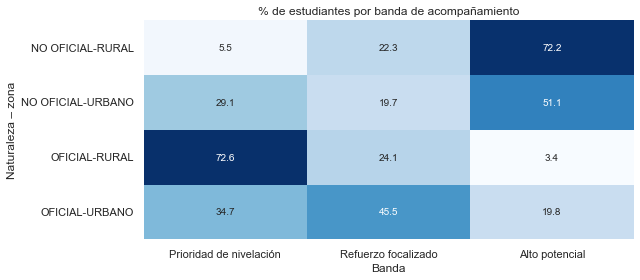

banda                                Prioridad de nivelación  \
cole_naturaleza cole_area_ubicacion                            
NO OFICIAL      RURAL                                 5.5000   
                URBANO                               29.1000   
OFICIAL         RURAL                                72.6000   
                URBANO                               34.7000   

banda                                Refuerzo focalizado  Alto potencial  
cole_naturaleza cole_area_ubicacion                                       
NO OFICIAL      RURAL                            22.3000         72.2000  
                URBANO                           19.7000         51.1000  
OFICIAL         RURAL                            24.1000          3.4000  
                URBANO                           45.5000         19.8000

In [77]:
# 6.2.2 Mapa de calor: % de estudiantes por banda según naturaleza y zona del colegio
tabla_calor = pd.crosstab([df_presc["cole_naturaleza"], df_presc["cole_area_ubicacion"]], df_presc["banda"],
                          normalize="index").mul(100)[ORDEN_BANDAS]          # % por fila: cada grupo suma 100
fig, eje = plt.subplots(figsize=(9, 4))
sns.heatmap(tabla_calor, annot=True, fmt=".1f", cmap="Blues", cbar=False, ax=eje)
eje.set_title("% de estudiantes por banda de acompañamiento"); eje.set_xlabel("Banda"); eje.set_ylabel("Naturaleza – zona")
plt.tight_layout(); guardar_figura("e_prescriptivo_calor"); plt.show()
# Tabla con los mismos porcentajes del mapa de calor
tabla_calor.round(1)

🔎 **Interpretación:** El mapa de calor muestra, para cada combinación de naturaleza y zona del colegio, qué porcentaje de sus estudiantes cae en cada banda.
En general:
- **Oficial rural** concentra la mayor necesidad: el 72,6 % de sus estudiantes queda en prioridad de nivelación y solo el 3,4 % en alto potencial.
- **Oficial urbano** es el grupo más grande y el más repartido: 45,5 % en refuerzo focalizado, 34,7 % en prioridad y 19,8 % en alto potencial.
- **No oficial** tiene mayoría en alto potencial: 51,1 % en la zona urbana y 72,2 % en la rural. Este último es un grupo pequeño (unos 1.100 estudiantes en todo el conjunto limpio) de colegios privados campestres, con una tasa real de alto desempeño del 48 %.

Para una secretaría de educación, esto sugiere concentrar los programas de nivelación en los colegios oficiales rurales y los de refuerzo en los oficiales urbanos.

**¿Qué hacemos y por qué?** Las **barras apiladas** muestran la composición de las bandas por subregión y por jornada, con
el porcentaje dentro de cada tramo.

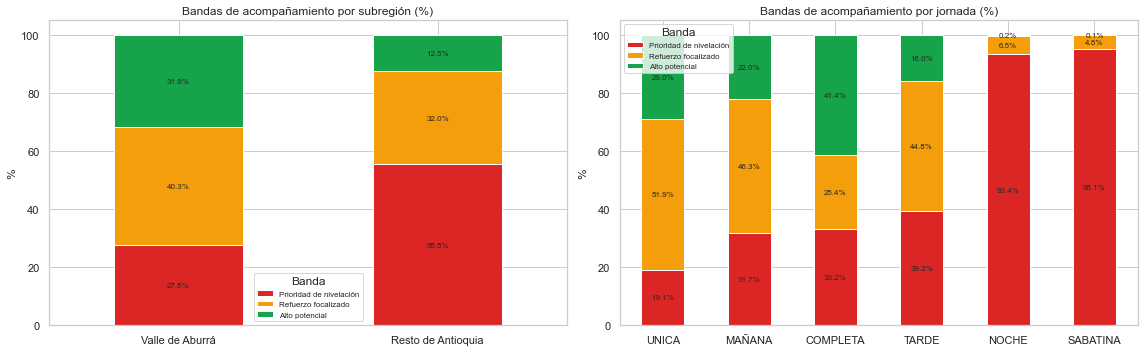

In [78]:
# 6.2.3 Barras apiladas: composición de las bandas por subregión y por jornada
fig, ejes = plt.subplots(1, 2, figsize=(16, 5))
for eje, var, titulo in [(ejes[0], "subregion", "subregión"), (ejes[1], "cole_jornada", "jornada")]:
    composicion = pd.crosstab(df_presc[var], df_presc["banda"], normalize="index").mul(100)[ORDEN_BANDAS]
    composicion = composicion.sort_values("Prioridad de nivelación")          # Grupos ordenados por prioridad
    composicion.plot.bar(stacked=True, ax=eje, color=["#dc2626", "#f59e0b", "#16a34a"], rot=0)
    for contenedor in eje.containers:
        eje.bar_label(contenedor, fmt="%.1f%%", label_type="center", fontsize=8)   # Etiqueta dentro de cada tramo
    eje.set_title(f"Bandas de acompañamiento por {titulo} (%)"); eje.set_xlabel(""); eje.set_ylabel("%")
    eje.legend(title="Banda", fontsize=8)
plt.tight_layout(); guardar_figura("e_prescriptivo_barras"); plt.show()

🔎 **Interpretación:** El gráfico muestra, en barras apiladas, la composición de las bandas por subregión (izquierda) y por jornada (derecha).
En general:
- **Subregión:** fuera del Valle de Aburrá el 55,5 % de los estudiantes queda en prioridad de nivelación, el doble que dentro del Valle (27,8 %). En alto potencial, el Valle multiplica por 2,5 al resto (31,9 % frente a 12,5 %).
- **Jornada:** la nocturna y la sabatina tienen más del 93 % de sus estudiantes en prioridad de nivelación y prácticamente ninguno en alto potencial. La completa tiene la mayor proporción de alto potencial (41,4 %), y la única y la de la mañana, la mayor de refuerzo focalizado (51,9 % y 46,3 %).

Las jornadas de jóvenes y adultos requieren una estrategia propia: para ellas la banda es casi la misma para todos, así que el modelo aporta poca información individual y la decisión debe ser colectiva.

**¿Qué hacemos y por qué?** Identificamos los **10 municipios** con mayor % de estudiantes en "Prioridad de nivelación" (con
al menos 150 estudiantes). Son los territorios donde convendría concentrar primero los programas de nivelación.

In [79]:
# 6.2.4 Top 10 municipios con mayor % de estudiantes en "Prioridad de nivelación" (≥ 150 estudiantes)
por_municipio = (df_presc.groupby("municipio")
                 .agg(estudiantes=("banda", "size"),
                      pct_prioridad=("banda", lambda b: 100 * (b == "Prioridad de nivelación").mean()),
                      pct_alto_potencial=("banda", lambda b: 100 * (b == "Alto potencial").mean()),
                      tasa_real_alto=(OBJETIVO, lambda s: 100 * s.mean())))           # Tasa real para contrastar
top_prioridad = por_municipio[por_municipio["estudiantes"] >= 150].nlargest(10, "pct_prioridad").round(1)   # Evita % inestables
guardar_tabla(top_prioridad.reset_index(), "e_prescriptivo_municipios")
print(f"Municipios evaluados (≥ 150 estudiantes en el pool): {(por_municipio['estudiantes'] >= 150).sum()}")
top_prioridad

Municipios evaluados (≥ 150 estudiantes en el pool): 44


,estudiantes,pct_prioridad,pct_alto_potencial,tasa_real_alto
municipio,,,,
ANORÍ,262,80.2000,4.2000,1.5000
ZARAGOZA,215,79.1000,7.0000,1.4000
SAN PEDRO DE URABÁ,251,78.5000,2.0000,4.8000
TARAZÁ,175,77.1000,4.0000,6.3000
CÁCERES,177,76.3000,3.4000,3.4000
NECOCLÍ,453,76.2000,2.0000,2.4000
ARBOLETES,288,76.0000,3.5000,3.1000
SAN JUAN DE URABÁ,158,75.9000,5.7000,1.9000
ANDES,257,73.2000,6.6000,16.7000


🔎 **Interpretación:** La tabla muestra los 10 municipios con mayor porcentaje de estudiantes en prioridad de nivelación, entre los 44 municipios con al menos 150 estudiantes en el pool.
En general, en todos ellos al menos dos de cada tres estudiantes quedan en esa banda (del 67,8 % en El Bagre al 80,2 % en Anorí). Se concentran en el Bajo Cauca (Zaragoza, Tarazá, Cáceres, El Bagre), Urabá (San Pedro de Urabá, Necoclí, Arboletes, San Juan de Urabá) y el Nordeste (Anorí). Siete de ellos aparecen también entre los de menor tasa real en 2.4.6, y salvo Andes su tasa real de alto desempeño en el pool está entre 1,4 % y 6,3 %.
**Andes** es la excepción instructiva: el modelo pone al 73,2 % de sus estudiantes en prioridad, pero su tasa real de alto desempeño es del 16,7 %, cercana a la media del departamento. Su perfil estructural (la mitad rural, 91 % oficial, 21 % en jornada sabatina y mayoría de estratos 1 y 2) predice resultados más bajos de los que sus estudiantes obtienen. Por eso las bandas deben **contrastarse con los resultados reales de cada municipio** antes de asignar recursos: el modelo hereda los sesgos de 5.4.

### 6.3 Nivel de MLOps y diagrama de flujo de los componentes
El modelo se ubica en el **nivel 1 de MLOps**:
- **Automatizado y reproducible:** descarga por API, reglas de calidad verificadas con aserciones, pipeline único (preprocesamiento, balanceo y modelo), búsqueda de hiperparámetros con validación cruzada, serialización con metadata y pruebas automáticas (pytest) del notebook, del modelo y de la app.
- **Manual:** el reentrenamiento con nuevas cohortes y el despliegue en Streamlit Cloud.
- **Faltante:** integración continua y monitoreo del *drift* en producción, que serían el paso al nivel 2.

**¿Qué hacemos y por qué?** Dibujamos el diagrama de flujo de los componentes, desde el dato abierto hasta la aplicación web.

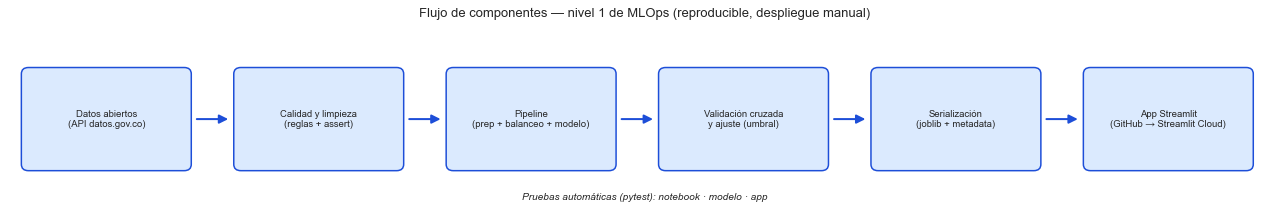

In [80]:
# 6.3.1 Diagrama de flujo de los componentes (del dato a la aplicación)
ETAPAS = ["Datos abiertos\n(API datos.gov.co)", "Calidad y limpieza\n(reglas + assert)", "Pipeline\n(prep + balanceo + modelo)",
          "Validación cruzada\ny ajuste (umbral)", "Serialización\n(joblib + metadata)", "App Streamlit\n(GitHub → Streamlit Cloud)"]
fig, eje = plt.subplots(figsize=(18, 3.2))
eje.set_xlim(0, len(ETAPAS) * 3); eje.set_ylim(0, 3); eje.axis("off")      # Lienzo sin ejes
ANCHO = 2.2                                                                 # Ancho de cada caja; deja 0,8 de espacio para la flecha
for i, texto in enumerate(ETAPAS):
    x = i * 3 + 0.3                                                         # Posición horizontal de cada caja
    eje.add_patch(FancyBboxPatch((x, 0.8), ANCHO, 1.4, boxstyle="round,pad=0.1", fc="#dbeafe", ec="#1d4ed8", lw=1.5))
    eje.text(x + ANCHO / 2, 1.5, texto, ha="center", va="center", fontsize=9.5)
    if i < len(ETAPAS) - 1:                                                 # Flecha en el hueco entre esta caja y la siguiente
        eje.annotate("", xy=(x + 3 - 0.15, 1.5), xytext=(x + ANCHO + 0.15, 1.5), zorder=3,
                     arrowprops={"arrowstyle": "-|>", "lw": 2, "color": "#1d4ed8", "mutation_scale": 18})
eje.text(len(ETAPAS) * 1.5, 0.25, "Pruebas automáticas (pytest): notebook · modelo · app", ha="center", fontsize=10, style="italic")
eje.set_title("Flujo de componentes — nivel 1 de MLOps (reproducible, despliegue manual)", fontsize=13)
plt.tight_layout(); guardar_figura("e_flujo_mlops"); plt.show()

🔎 **Interpretación:** El diagrama muestra los seis componentes de la solución en el orden en que fluye la información: datos abiertos → calidad y limpieza → pipeline → validación cruzada y ajuste del umbral → serialización → aplicación Streamlit. Las pruebas automáticas cubren el notebook, el modelo y la app.
En general, todo el flujo es **reproducible** con un solo comando (descarga por API, semillas fijas y pipeline único), pero el reentrenamiento y el despliegue siguen siendo manuales. Eso ubica la solución en el **nivel 1 de MLOps**. El paso siguiente sería automatizar el reentrenamiento con cada nueva cohorte del ICFES y monitorear el *drift* de los datos.

### 6.4 Aplicación web e información del despliegue
- **App (`app.py`, Streamlit):** carga `models/pipeline_saber11.joblib` y `models/metadata.json`. Ofrece predicción
  individual (formulario con un perfil típico por defecto), predicción por lotes (CSV o 1.000 registros de ejemplo) y una
  pestaña con métricas, matriz de confusión e importancias. En ambos tipos de predicción muestra la **banda de
  acompañamiento** de la regla 2 (sección 1.3), y en los lotes resume el porcentaje de registros en cada banda.
- **Repositorio GitHub:** `app.py`, modelo serializado, `requirements.txt`, `README.md`, notebooks, datos y reporte HTML.

| Información del despliegue | Estado |
|---|---|
| Modelo serializado | Sí — `models/pipeline_saber11.joblib` |
| App Streamlit funcional | Sí — verificada en local y con pruebas automáticas |
| Repositorio GitHub | [COMPLETAR: URL] |
| URL pública en Streamlit.io | [COMPLETAR: URL] |
| Enlace público de este cuaderno en Colab | [COMPLETAR: URL] |

## 7. Conclusiones generales
- **Desempeño del modelo:** la **regresión logística con umbral ajustado (0,615)** es el modelo final. En el conjunto de prueba obtiene F1 = 0,473 (IC95 % 0,453–0,494), Recall 0,58, Precision 0,40 y ROC-AUC 0,80, y en 1.000 registros nunca vistos, F1 = 0,495. Ni los modelos flexibles (Random Forest, SVM) ni los ensambles (votación, bagging, XGBoost) la superaron: las pruebas estadísticas mostraron equivalencia en F1, y se eligió el modelo más simple e interpretable. La mayor mejora vino de **ajustar el umbral de decisión**, no de cambiar de algoritmo.
- **Aporte de la regla prescriptiva:** las bandas de acompañamiento convierten la probabilidad en decisiones. En el pool de 42.357 estudiantes, la tasa real de alto desempeño va del 3,7 % en prioridad de nivelación al 40,9 % en alto potencial. Los colegios oficiales rurales (72,6 % en prioridad), las jornadas nocturna y sabatina (más del 93 %) y municipios del Bajo Cauca, Urabá y el Nordeste concentran la mayor necesidad.
- **Calidad y preparación de los datos:** el conjunto 2022-2 de Antioquia venía con el 50 % de filas duplicadas. Las reglas de calidad y las aserciones lo detectaron, y la limpieza dejó 72.357 estudiantes con 17,1 % de alto desempeño. Los faltantes resultaron informativos (quien no reporta datos suele tener menor desempeño), por lo que se imputaron con una categoría explícita e indicadores en lugar de eliminarse.
- **Análisis por grupos (equidad):** el modelo funciona peor donde más se necesita. El F1 es de 0,34 en colegios oficiales frente a 0,65 en no oficiales, y de 0,38 fuera del Valle de Aburrá frente a 0,50 dentro. Además, sobrepredice el alto desempeño en hombres. Reproduce las desigualdades del sistema educativo que ya mostraba el análisis exploratorio (2.5).
- **Valor estratégico:** revisando solo al 20 % de los estudiantes con mayor probabilidad se capta a la mitad de los de alto desempeño (lift 2,5). Esto permite focalizar programas de becas, preparación o nivelación con recursos limitados, siempre como apoyo a la decisión y nunca para excluir a nadie.
- **Criterio de negocio:** se cumplen los tres criterios definidos en 1.5: Recall 0,58 ≥ 0,55, lift 2,33 ≥ 2 y F1 0,473 > 0,459. Los márgenes son modestos, y la curva de aprendizaje muestra que con estas variables el techo de F1 ronda 0,47–0,49. Mejorar exige **más información**, no más datos ni modelos más complejos.

### Recomendaciones
- **Reentrenar periódicamente** con cada nueva cohorte de la prueba Saber 11 (datos abiertos del ICFES) y comparar el desempeño entre cohortes para detectar *drift*.
- **Construir un tablero de bandas por municipio y colegio** para las secretarías de educación, contrastando siempre la banda predicha con los resultados reales del municipio, como muestra el caso de Andes.
- **Incorporar el efecto colegio** (el promedio histórico del establecimiento en cohortes anteriores) y variables exógenas del territorio (conectividad, índices de pobreza multidimensional, oferta educativa) para superar el techo actual de desempeño.
- **Calibrar las probabilidades** (por ejemplo, con `CalibratedClassifierCV`) si se van a comunicar como riesgos o probabilidades de éxito, ya que el submuestreo las infla.
- **Usar las bandas para focalizar, no para excluir:** asignar tipos de acompañamiento según la banda, revisar las decisiones con criterio pedagógico y auditar periódicamente la equidad por naturaleza, zona, subregión y género.